<a href="https://colab.research.google.com/github/Shinyhunter95/Project-6070/blob/main/Project_6070.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

# Country =	Czechoslovakia
# Station =	Decin
# River =	Elbe
# Area =	51104 km2
# Lat =	50.78
# Lon =	14.22
# Source =	RivDIS
# PointID =	1240
# Area Units =	km2
# Discharge Units =	m3/sec
# Starting Year =	1851
# Ending Year =	1984
# Total Years =	134
# Total Usable Years =	134


Saving elbe.txt to elbe.txt


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("elbe.txt", sep="\t")
N = len(df)

# Averages and Standard Deviations (Stripped from the data for easier loading.)
avg = [319.62, 391.22, 520.19, 496.91, 344.51, 258.57, 222.2, 198.86, 191.3, 206.13, 222.32, 274.12]
std_dev = [220.25, 242.21, 265.89, 255.82, 166.29, 170.13, 148.07, 128.76, 150.68, 123.26, 141.57, 188.95]

annual_avg = 303.83
annual_std = 90.5

df_avg = pd.DataFrame(avg, columns=['Avg'])
df_std = pd.DataFrame(std_dev, columns=['Std Dev'])

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


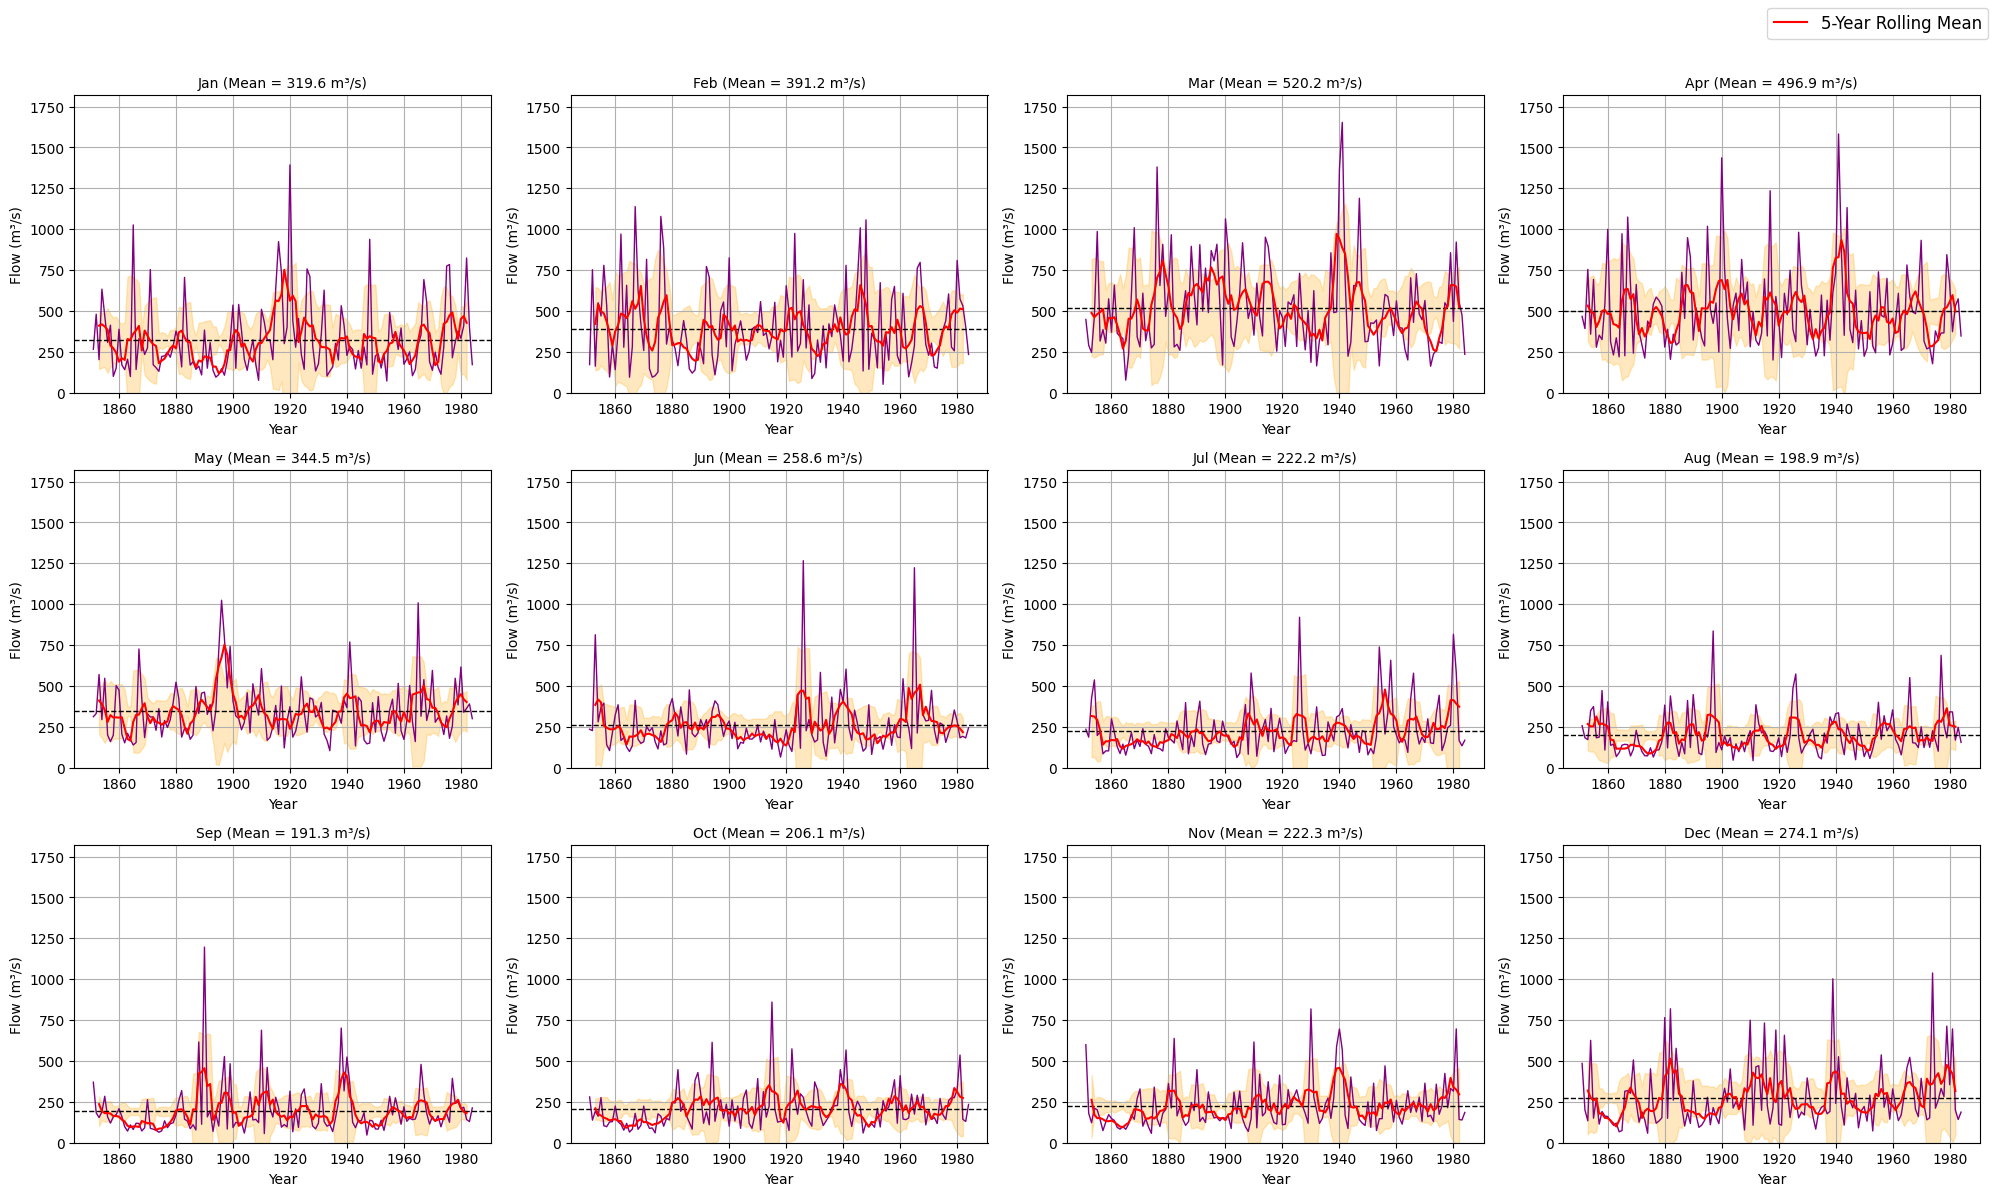

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

window = 5  # rolling window in years

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month]

    # Plot monthly data
    axes[idx].plot(df["Year"], data, color='purple', linewidth=1)

    # Add long-term mean line
    axes[idx].axhline(avg[idx], color='black', linestyle='--', linewidth=1)

    # Compute and plot rolling mean
    rolling_mean = data.rolling(window=window, center=True).mean()
    axes[idx].plot(df["Year"], rolling_mean, color='red', linewidth=1.5, label=f'{window}-Year Rolling Mean')

    # Compute and shade rolling std deviation
    rolling_std = data.rolling(window=window, center=True).std()
    axes[idx].fill_between(
        df["Year"],
        avg[idx] - rolling_std,
        avg[idx] + rolling_std,
        color='orange',
        alpha=0.25
    )

    # Subplot title including mean
    axes[idx].set_title(f"{month} (Mean = {avg[idx]:.1f} m³/s)", fontsize=10)

    # Axis labels
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("Flow (m³/s)")
    axes[idx].grid(True)

    # Uniform y-axis for easier seasonal comparison
    axes[idx].set_ylim(0, max(df[months].max()) * 1.1)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Main figure title
#plt.suptitle("Monthly Mean Discharge with Rolling Mean and Variability for Each Month (Elbe River, Decin)", fontsize=16)

# Figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=12)

plt.show()

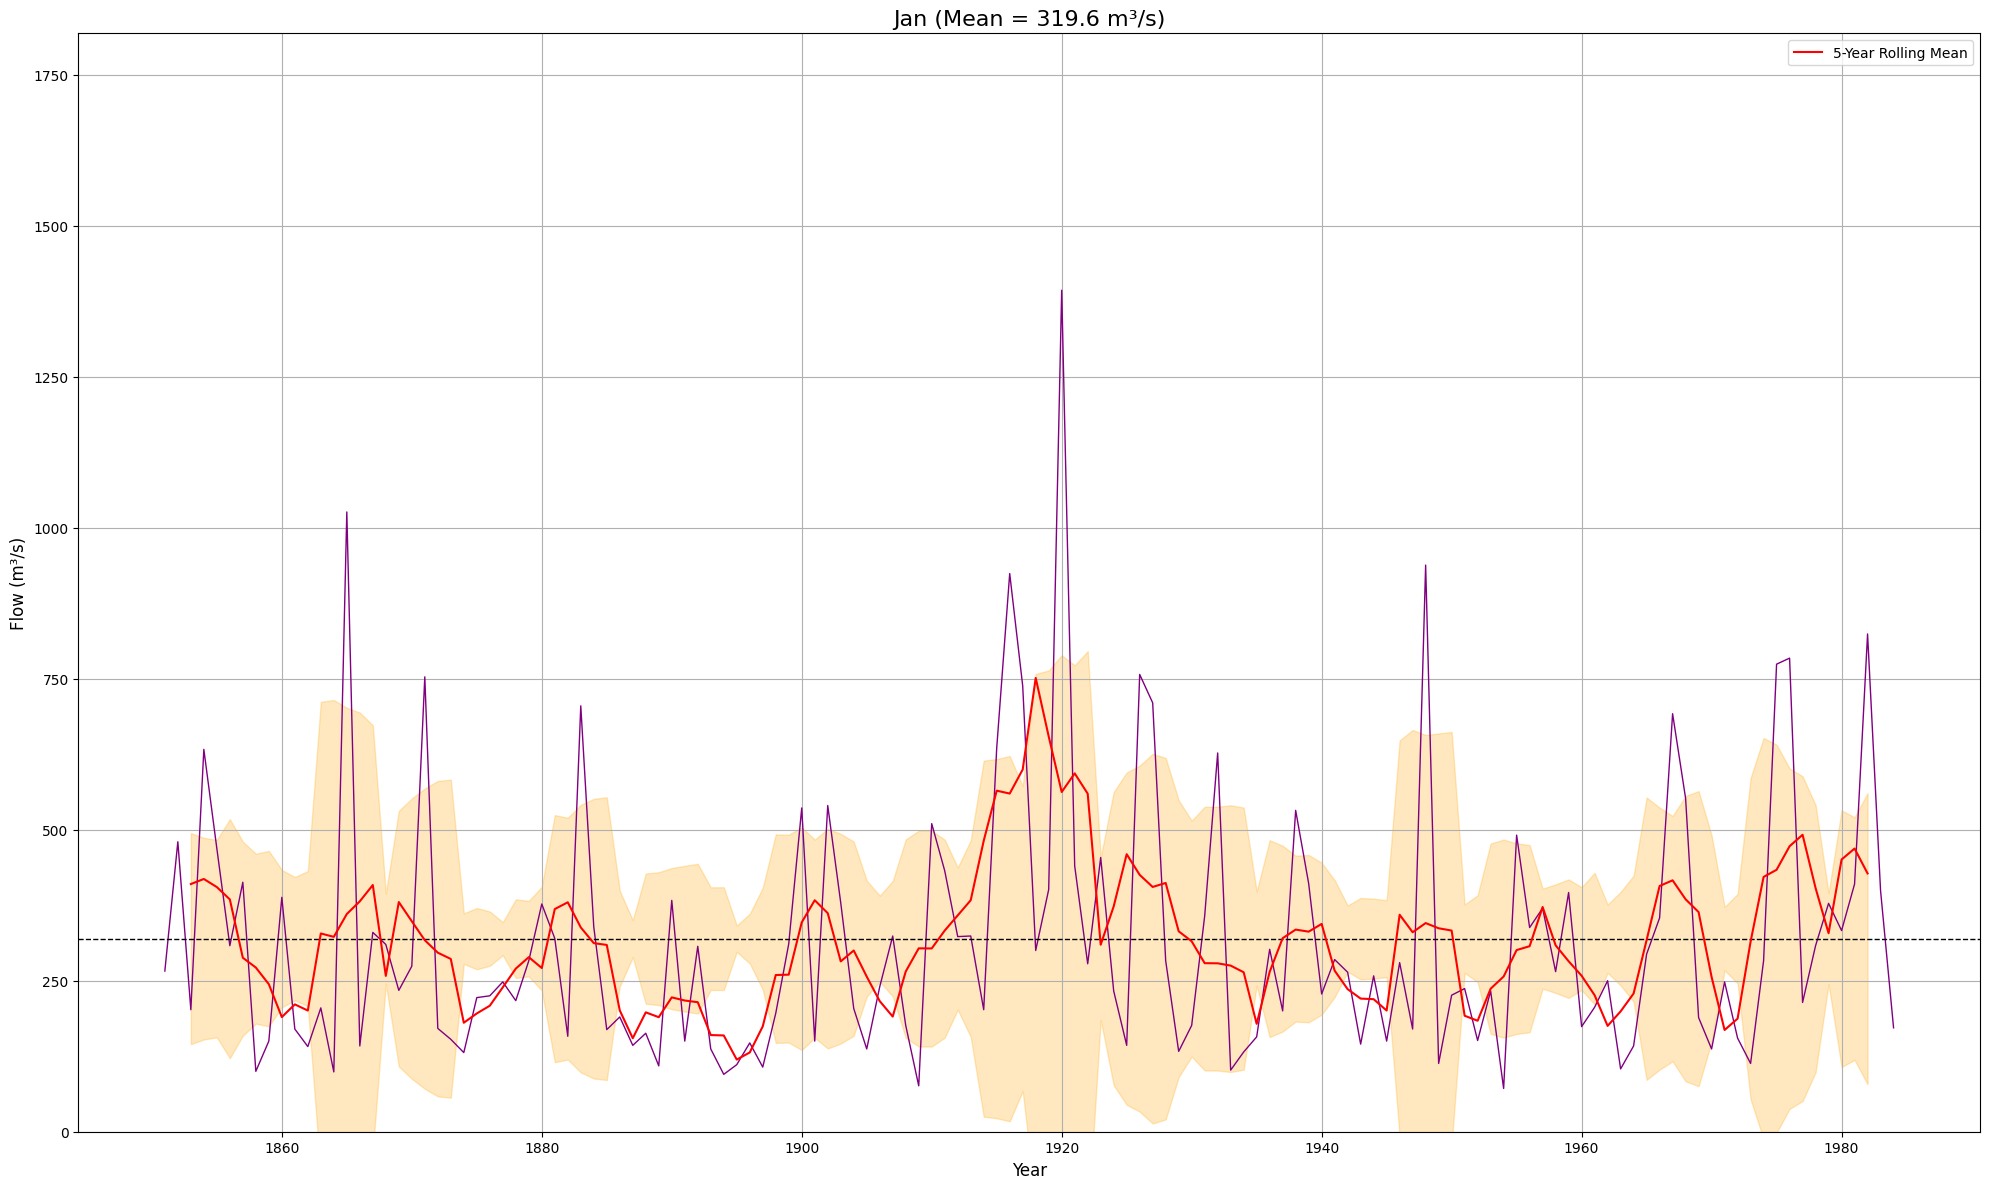

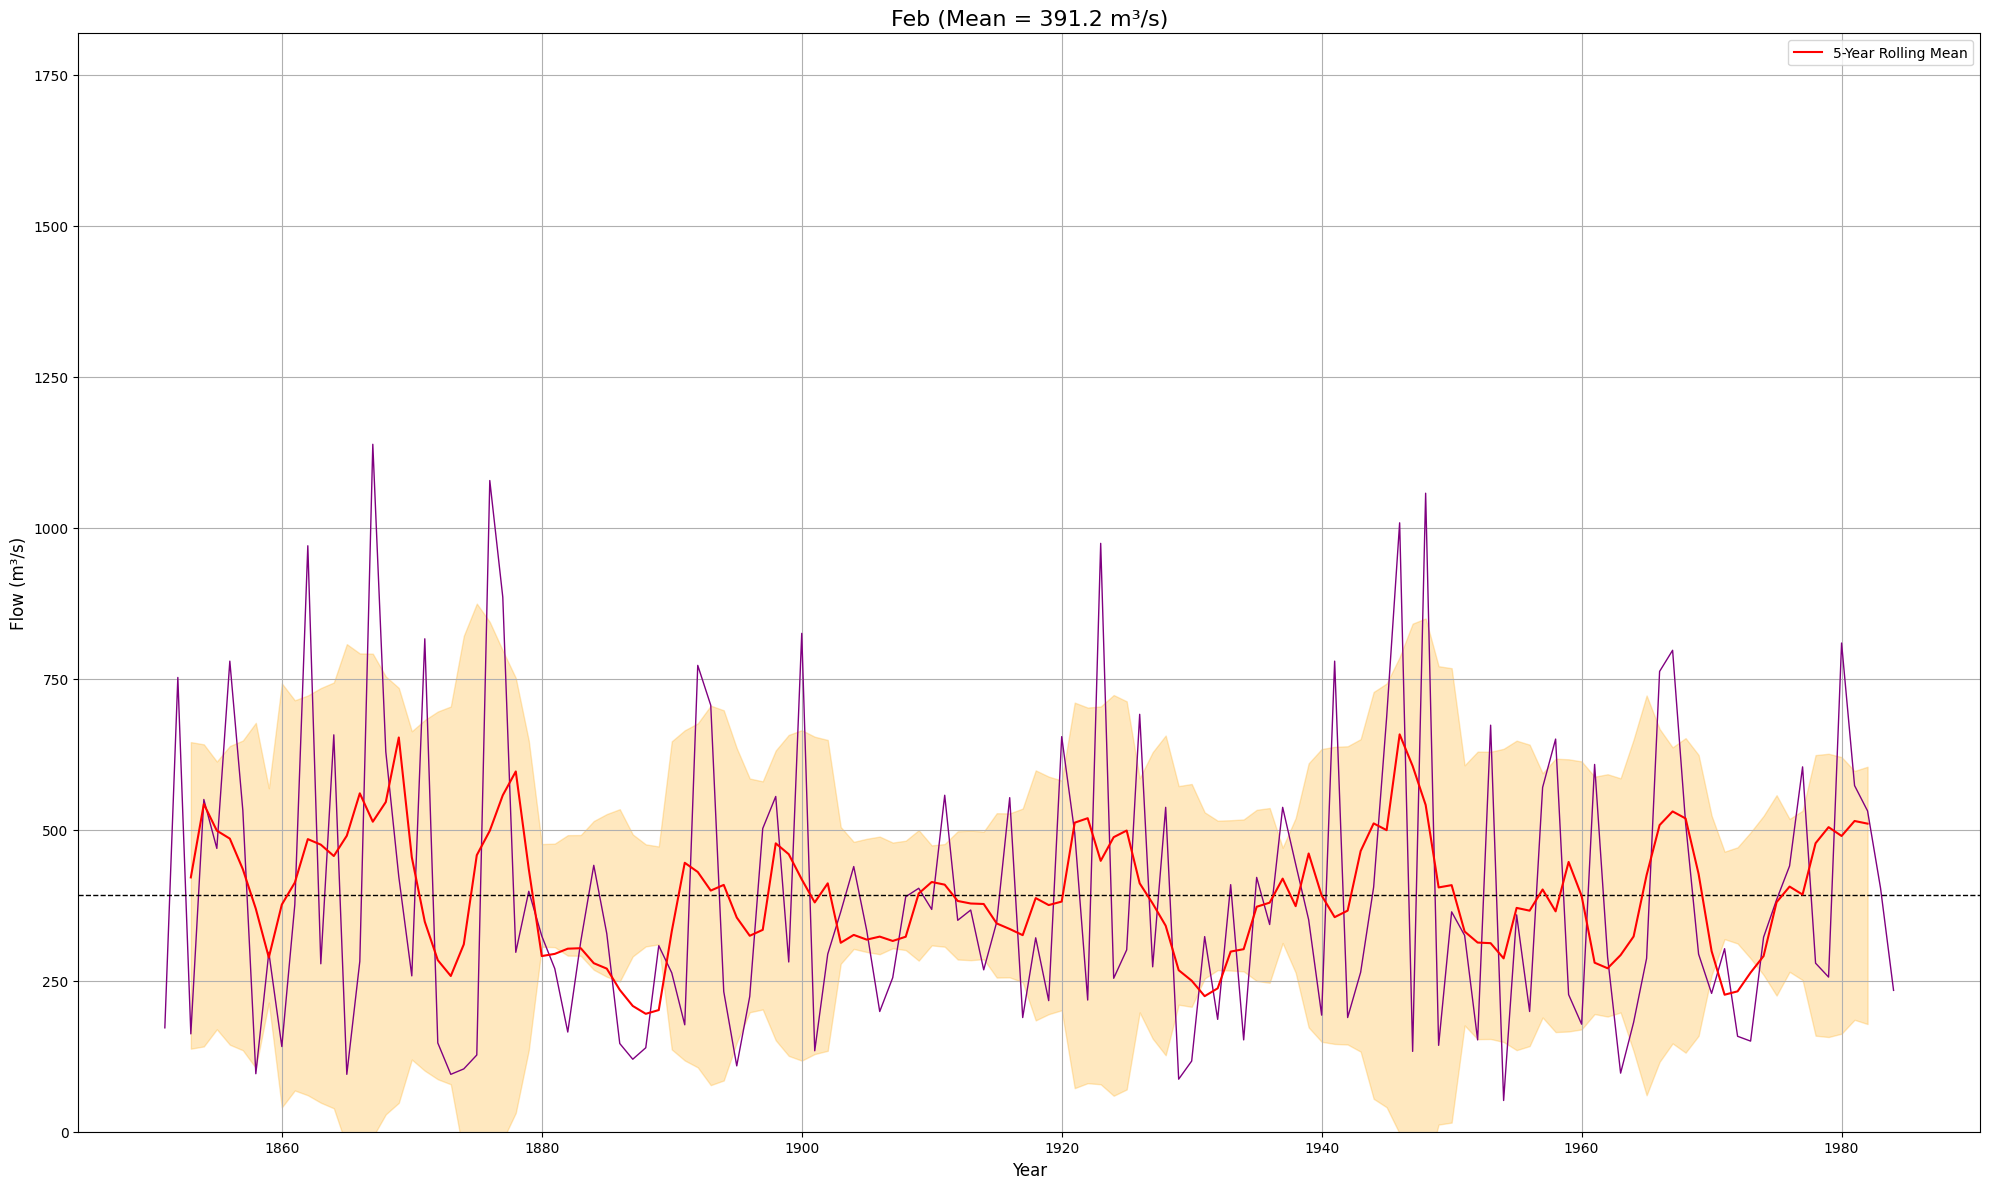

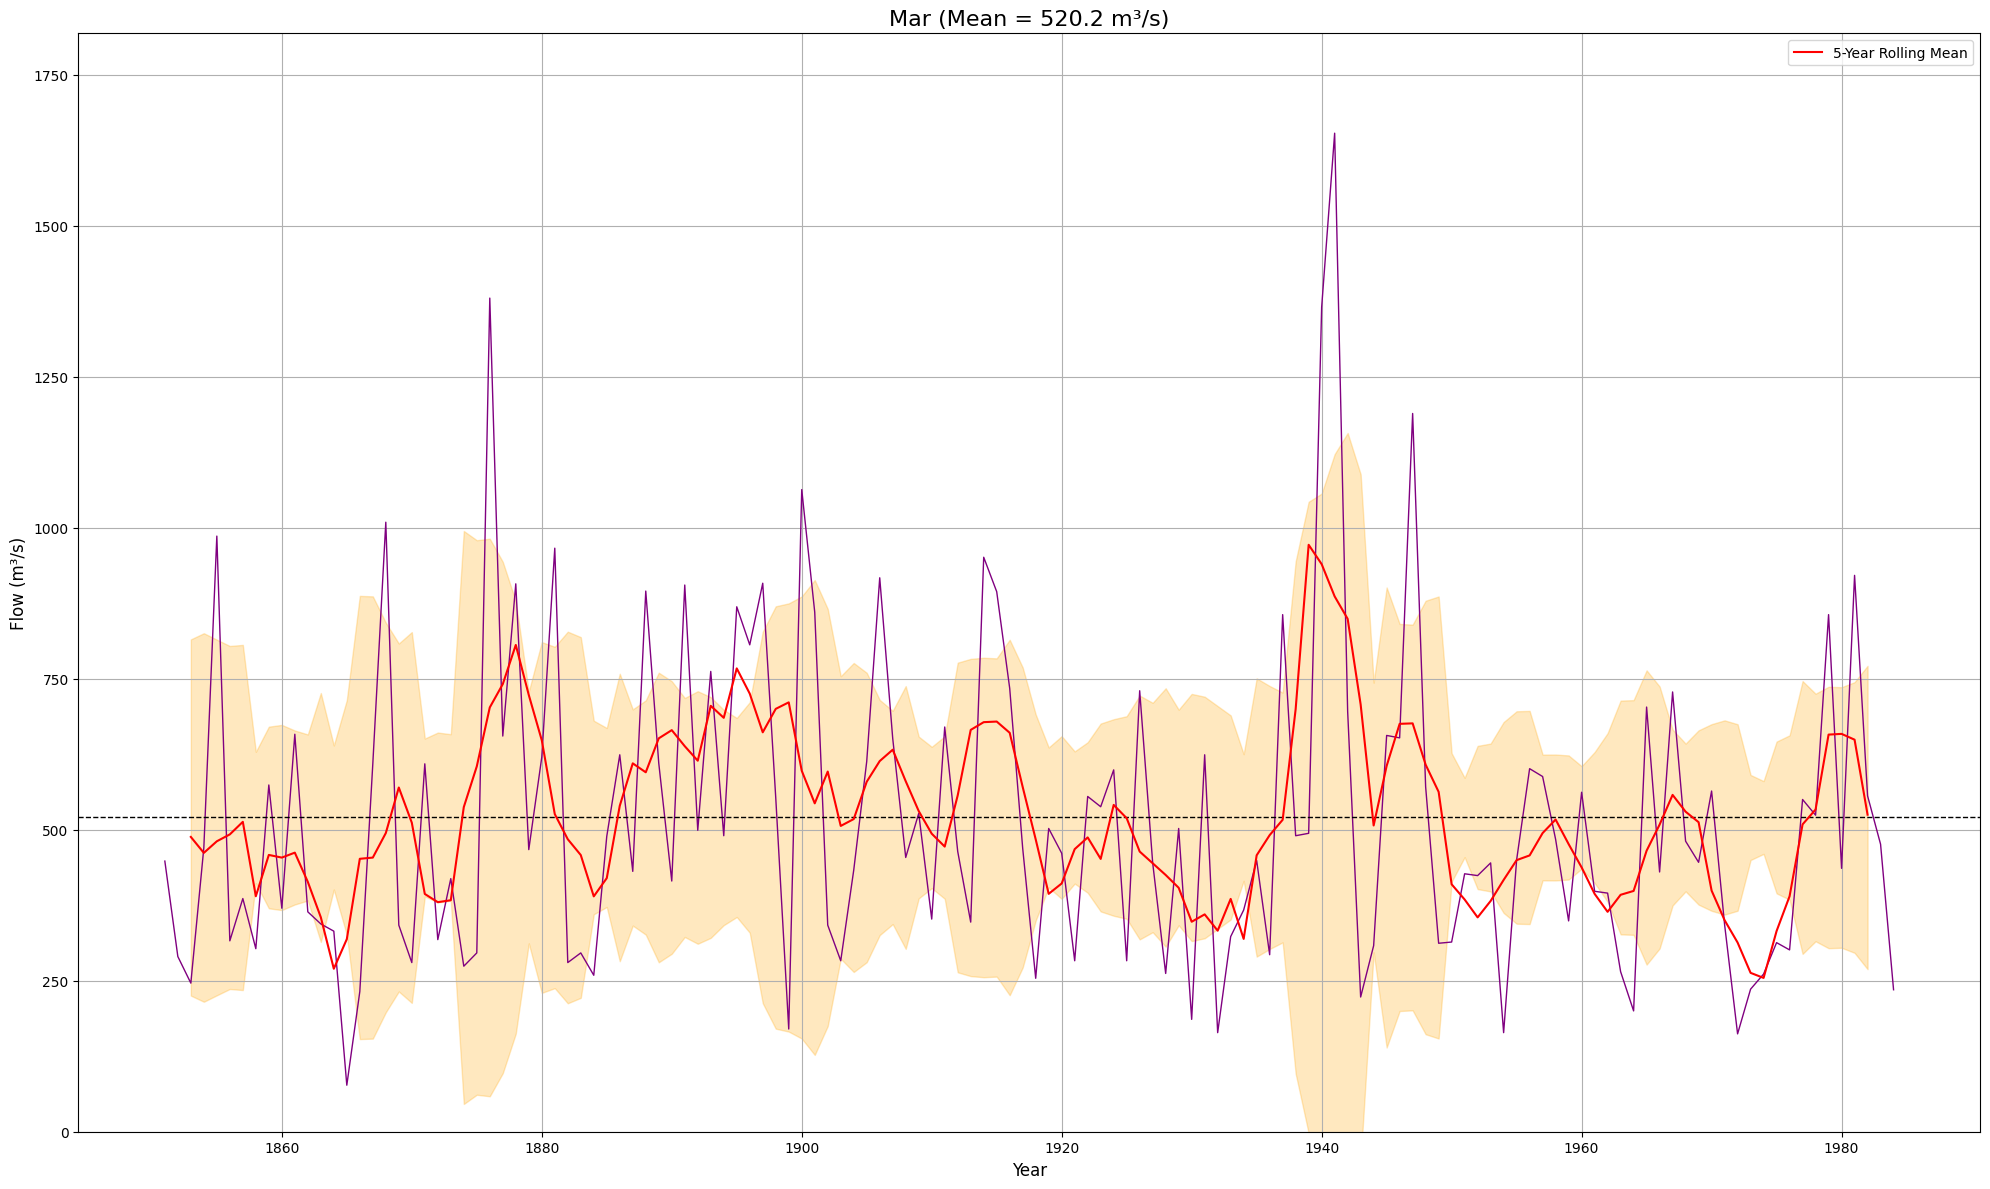

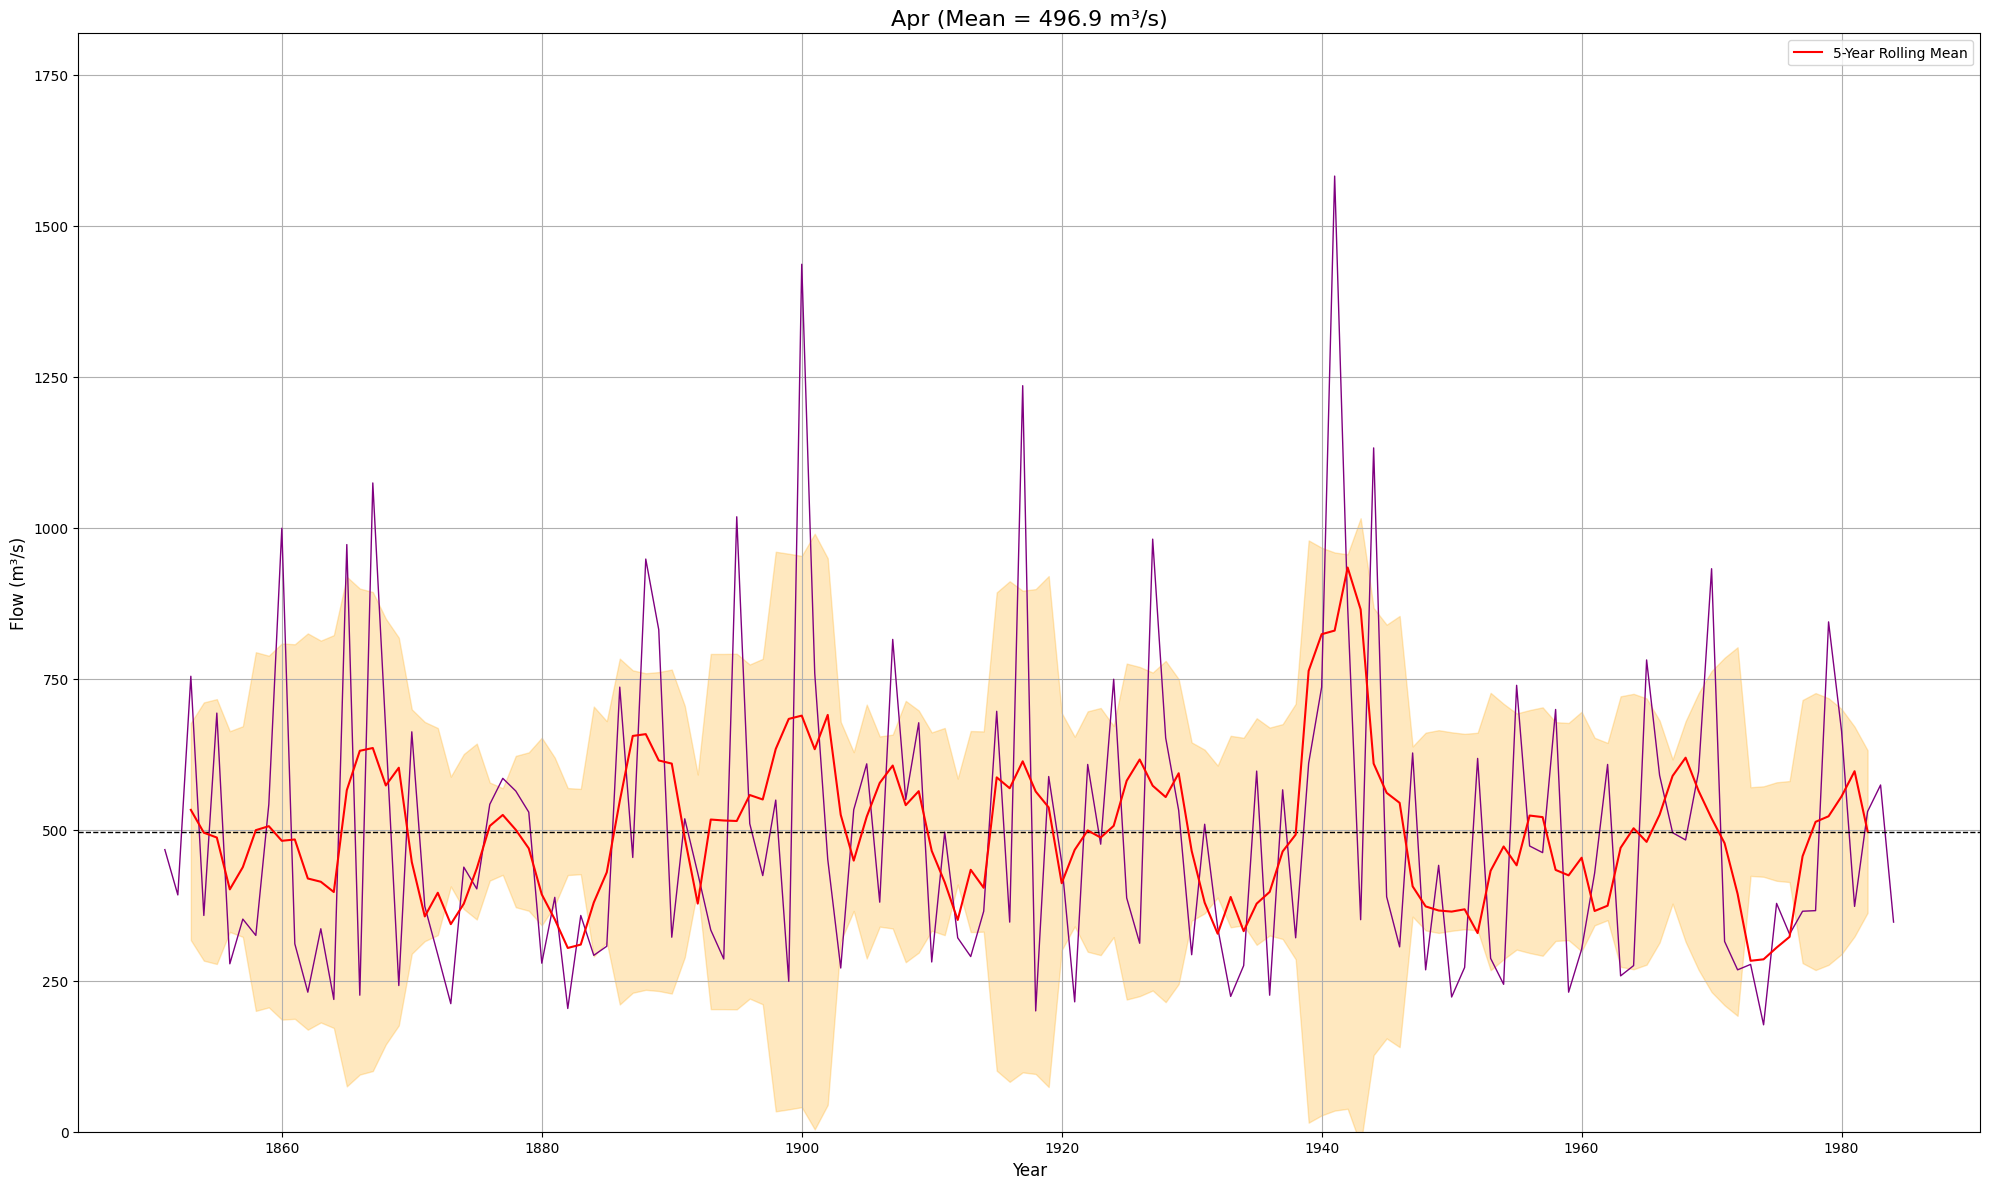

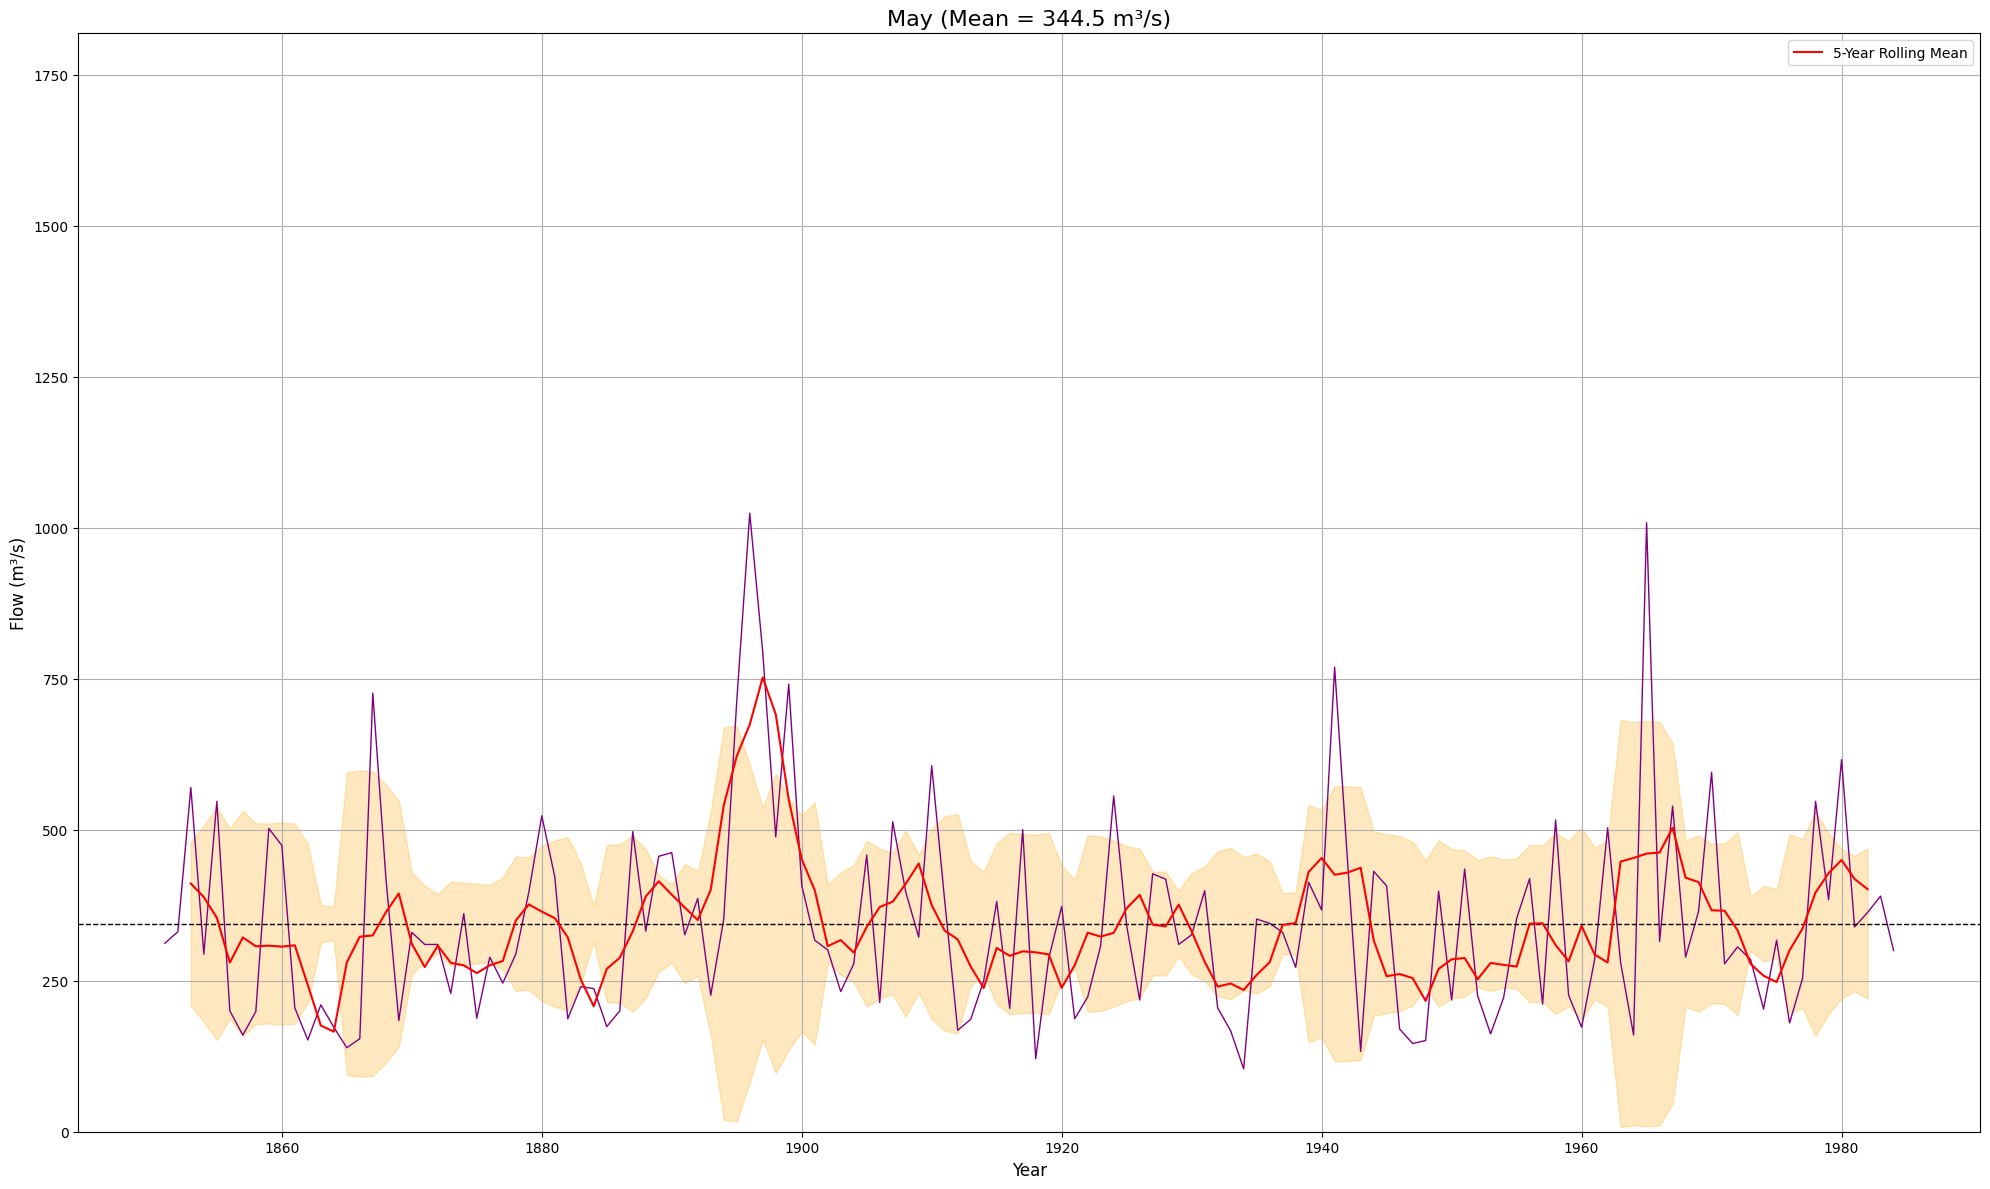

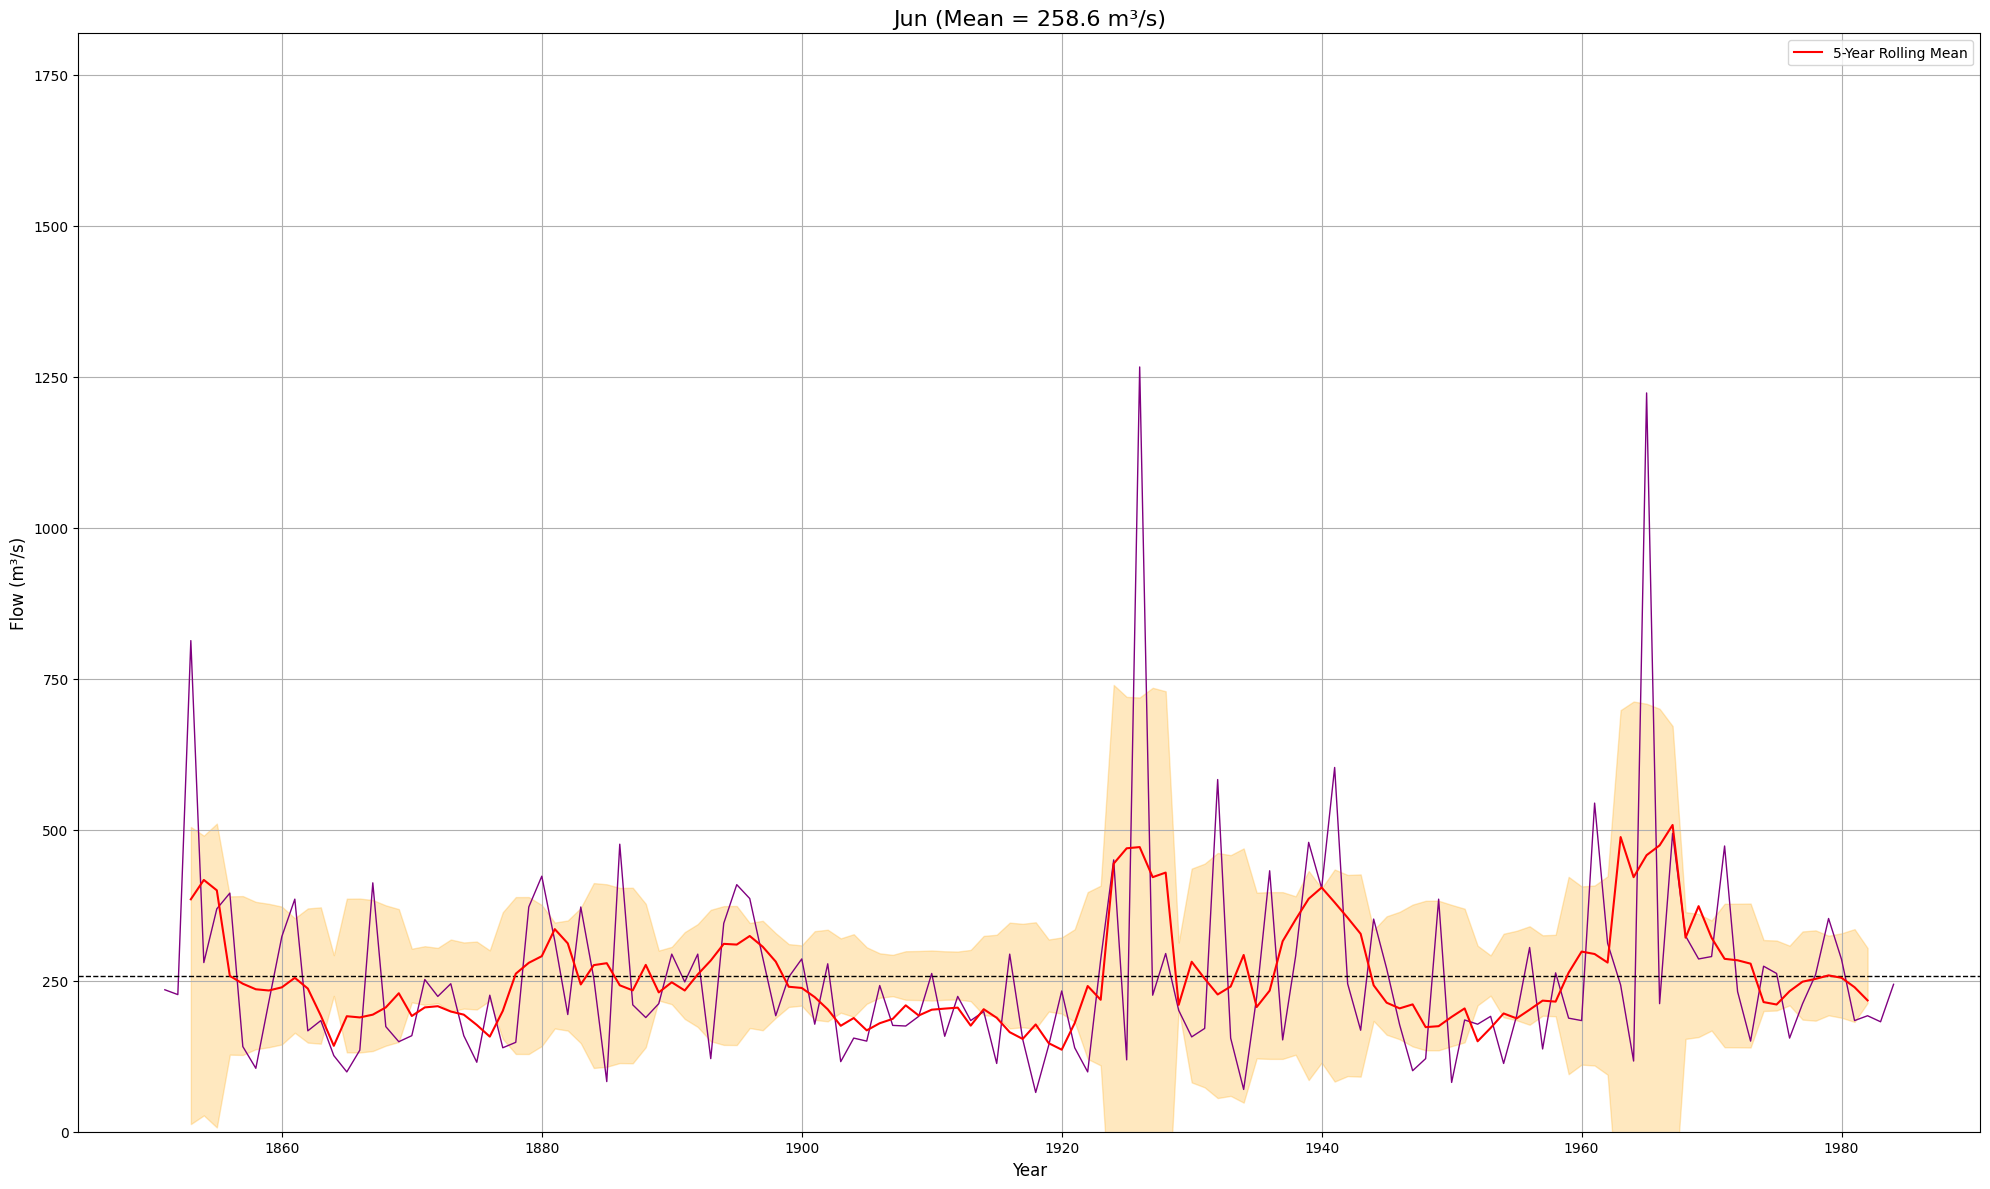

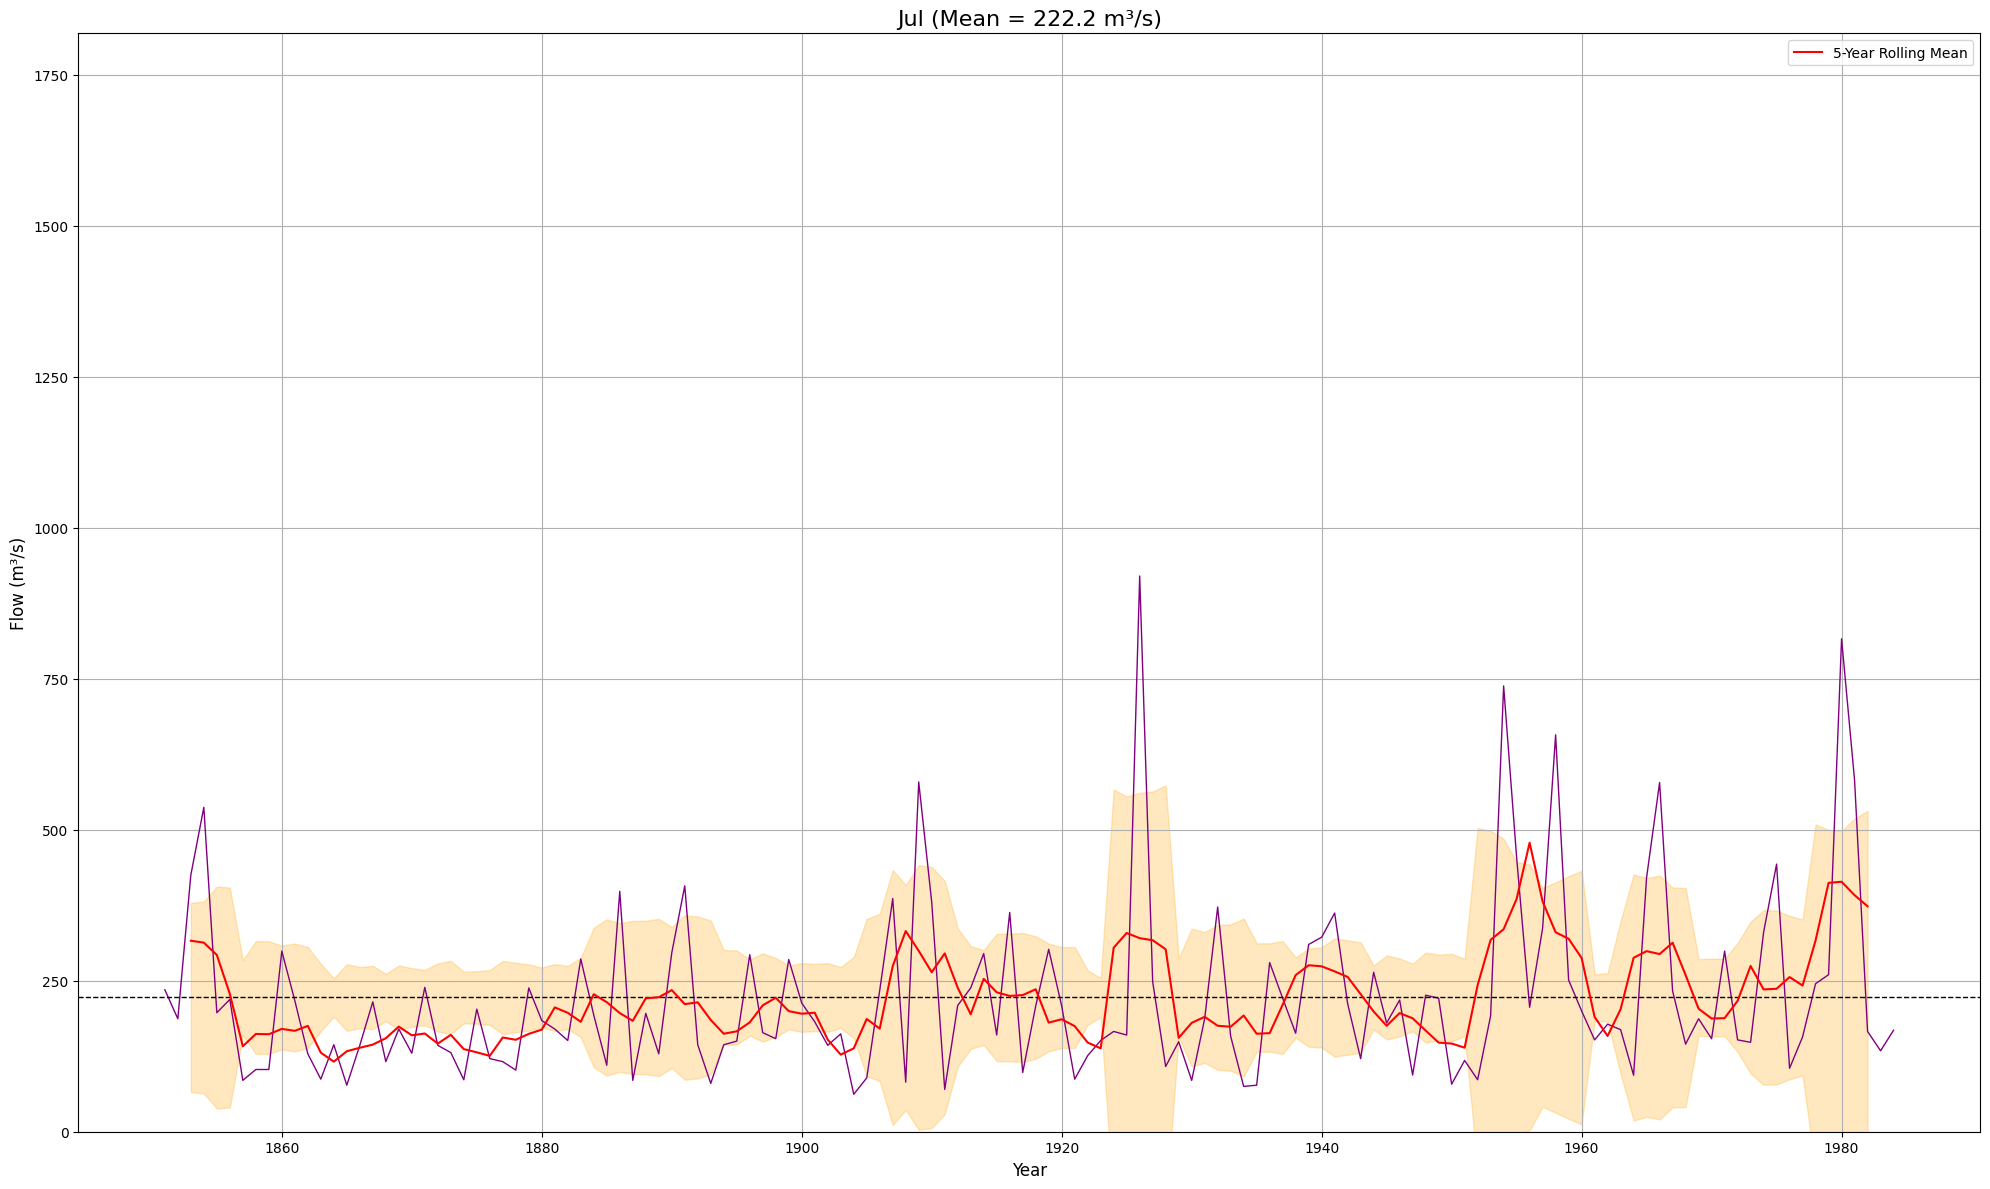

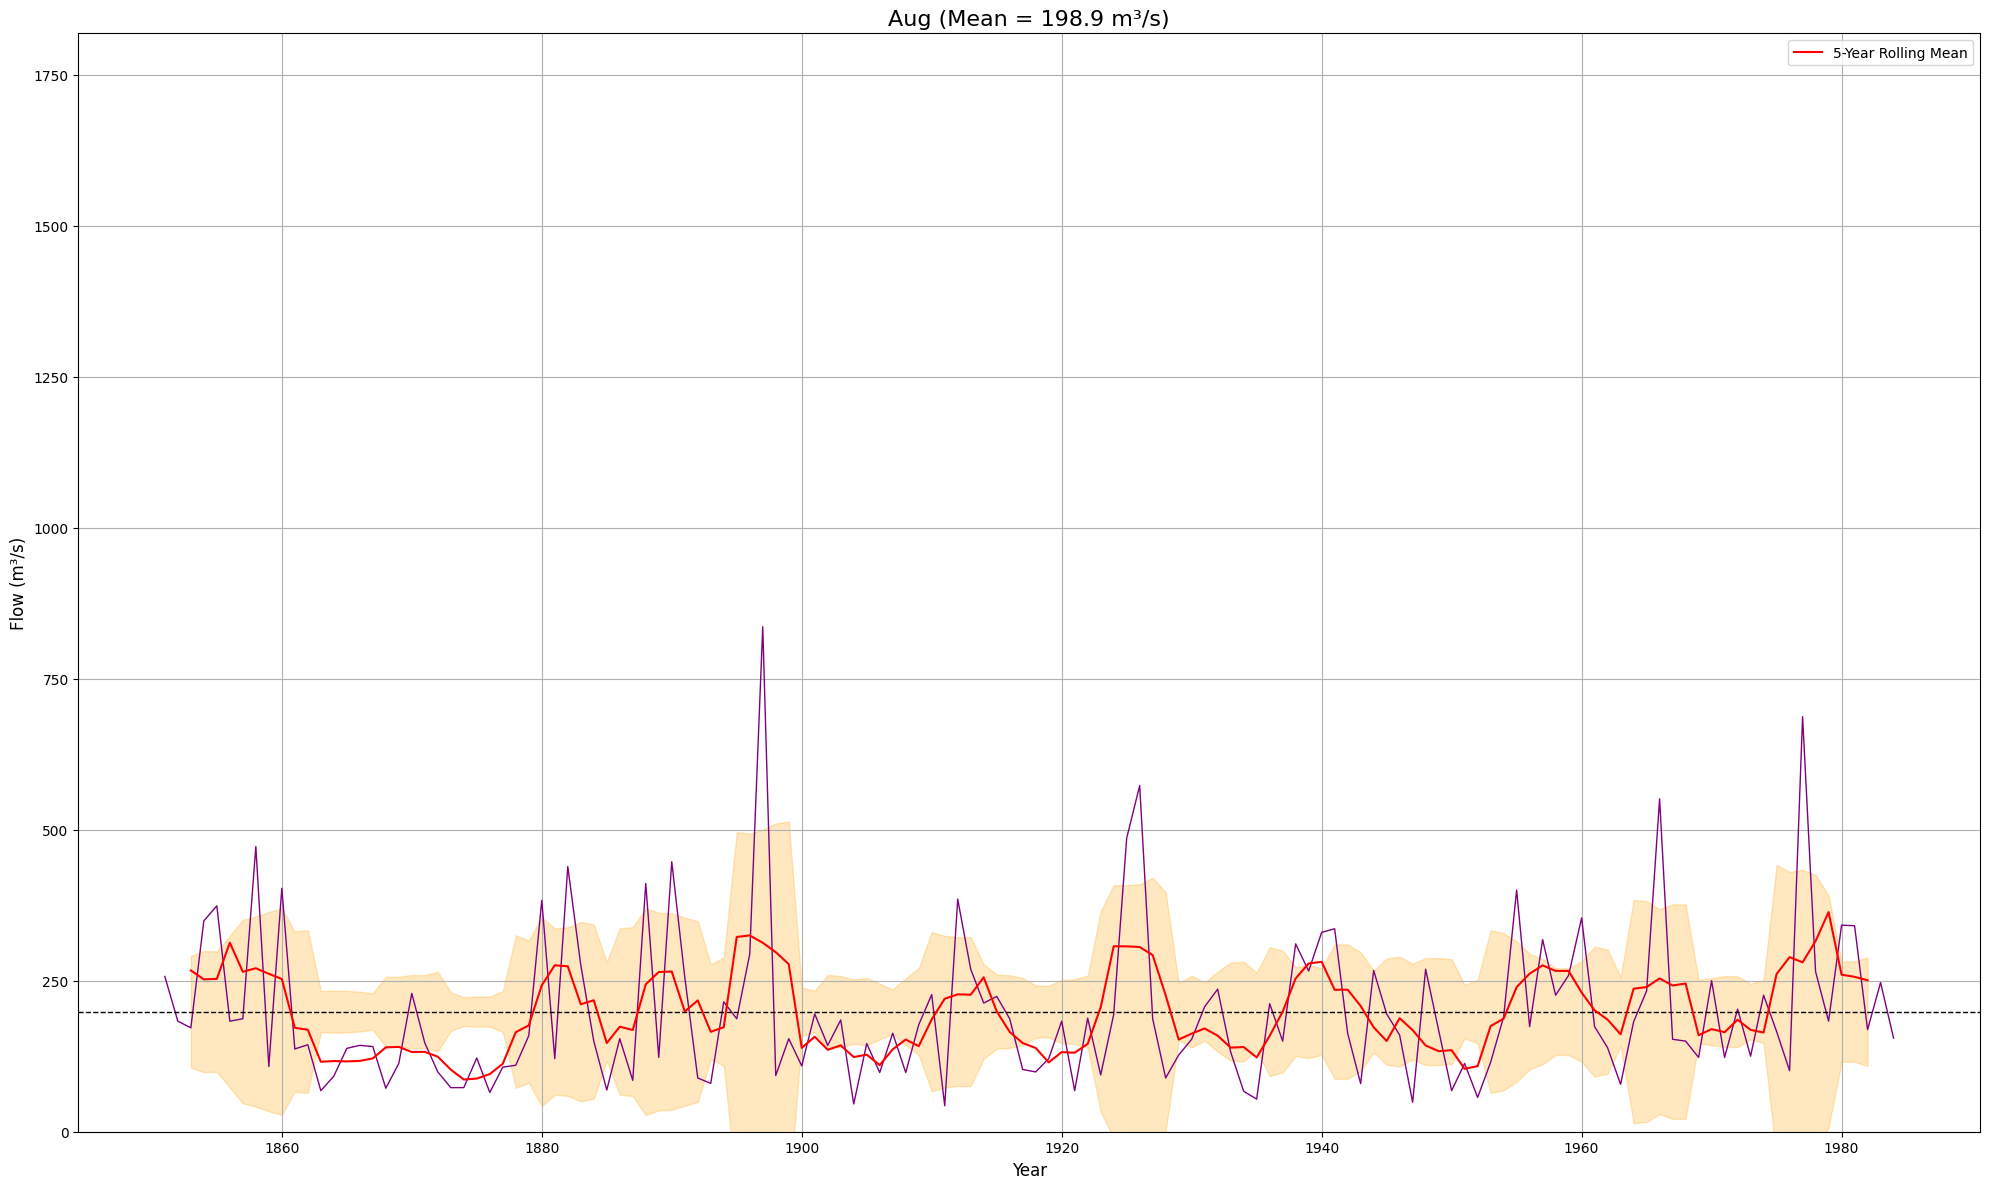

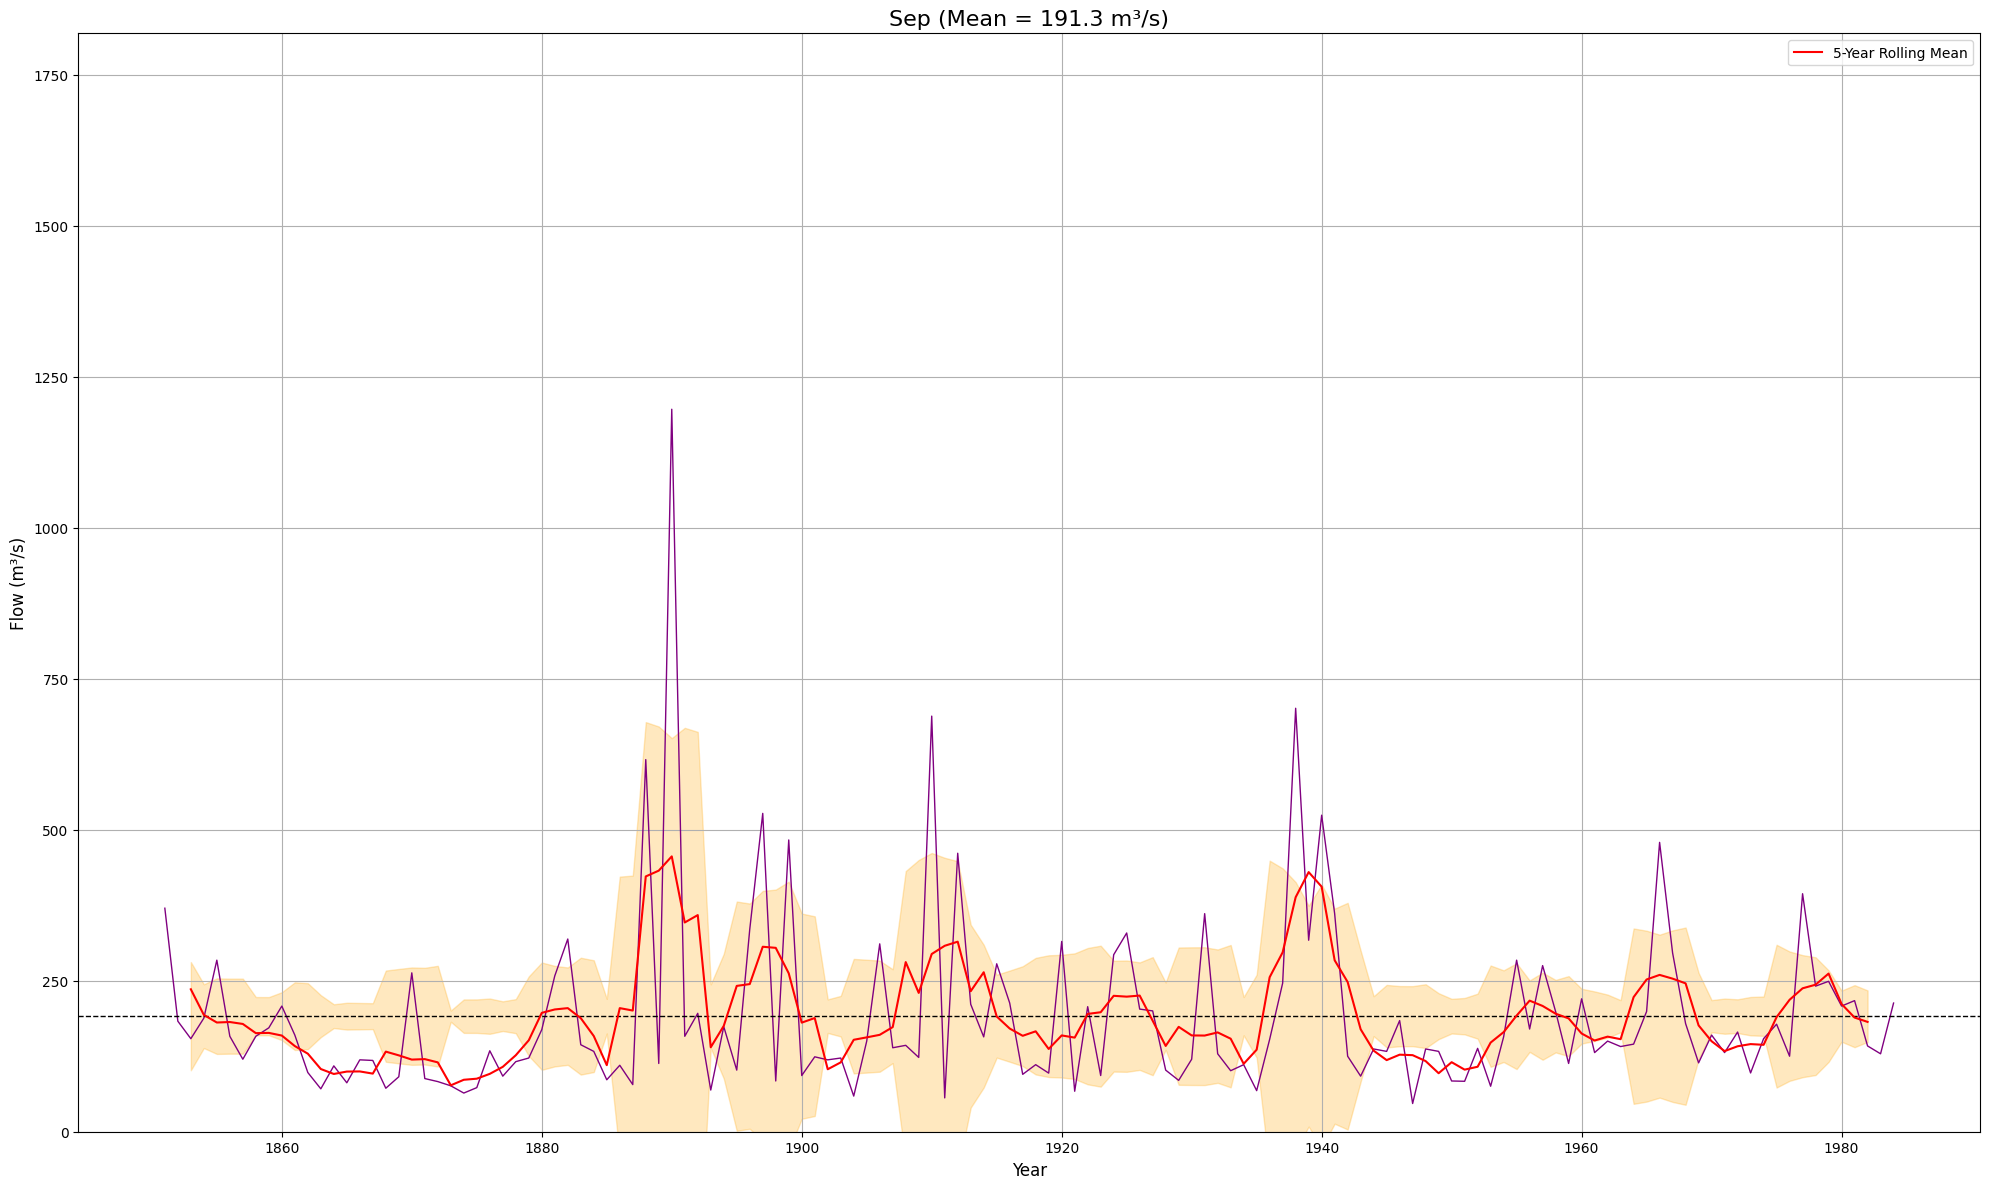

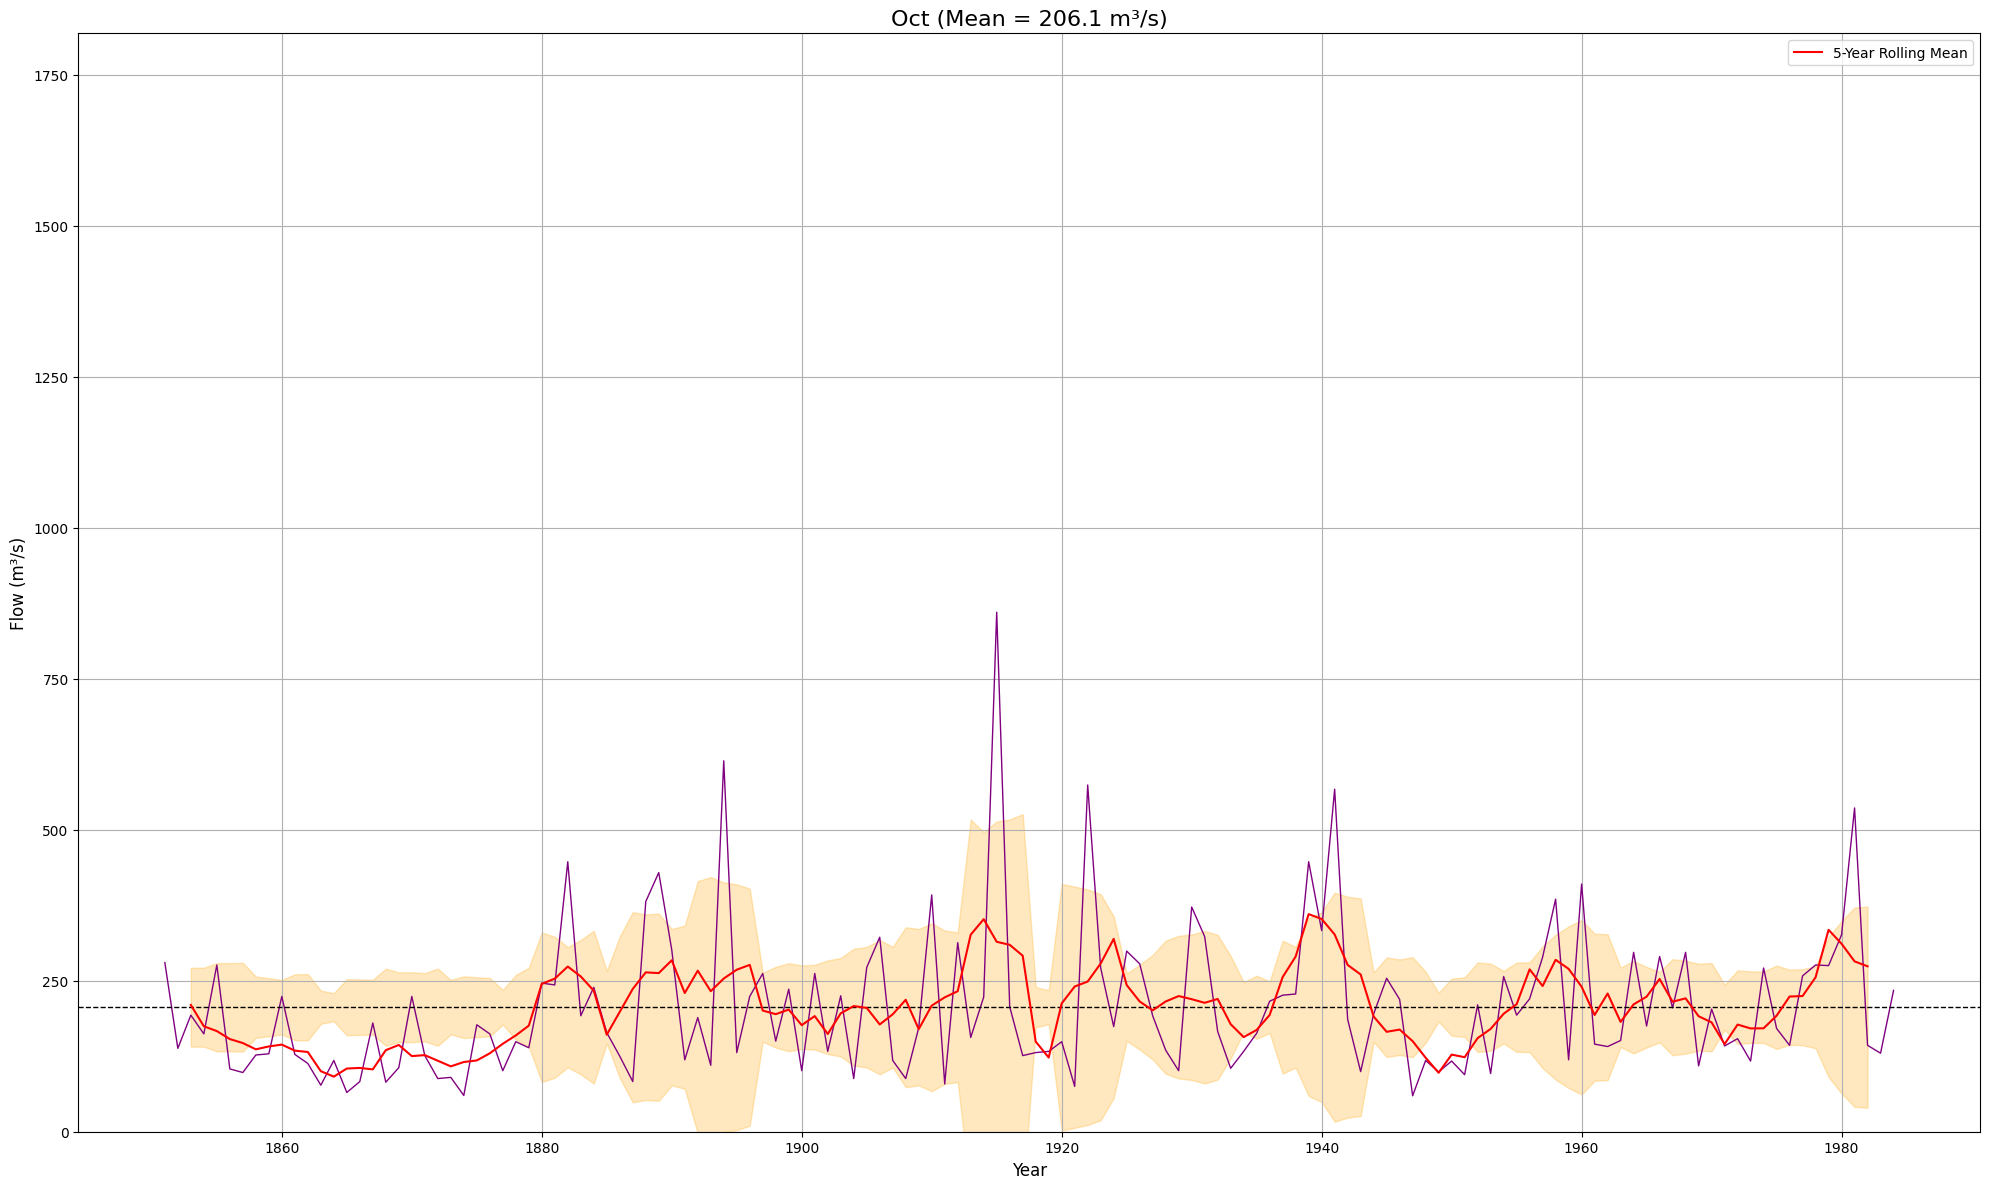

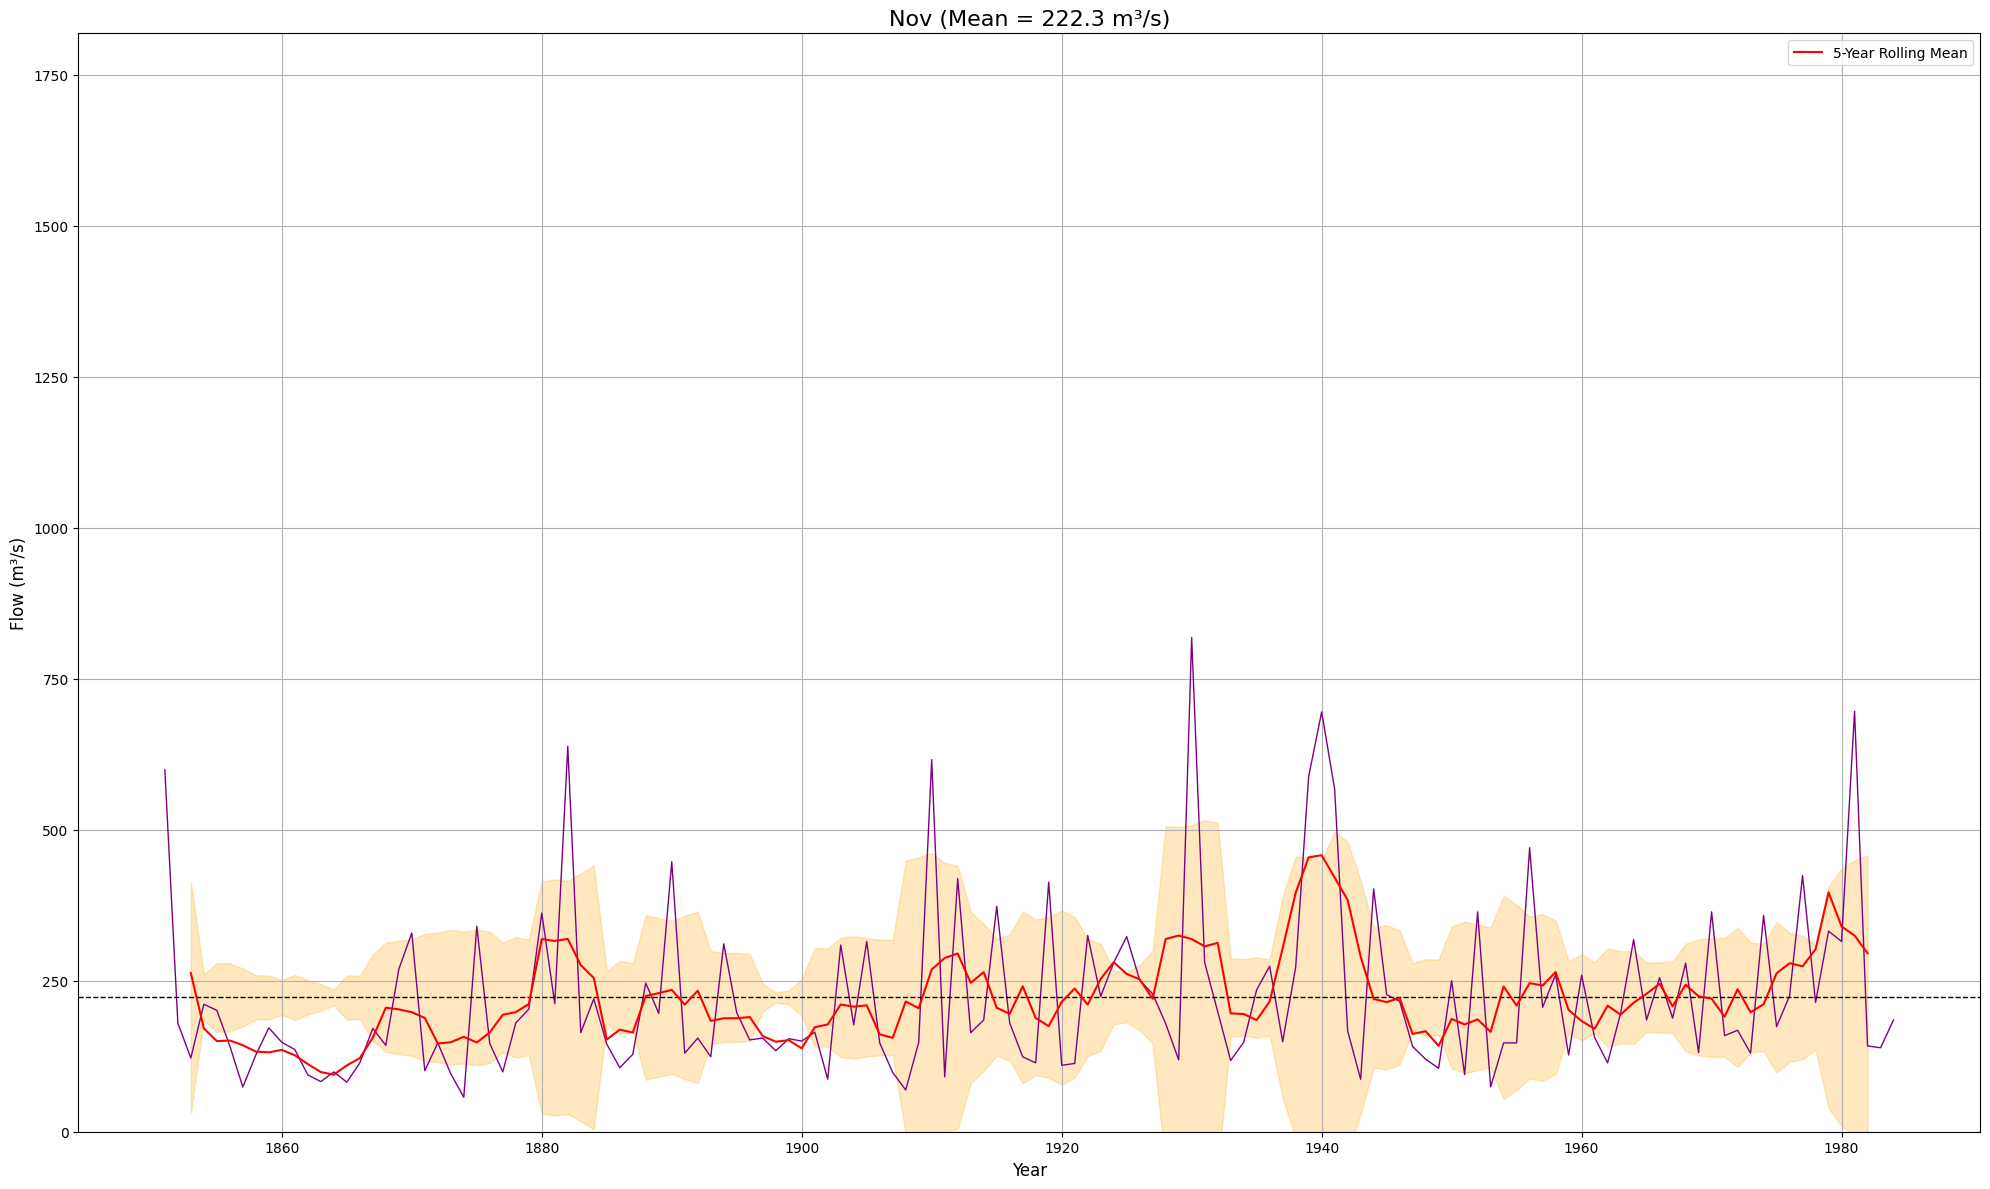

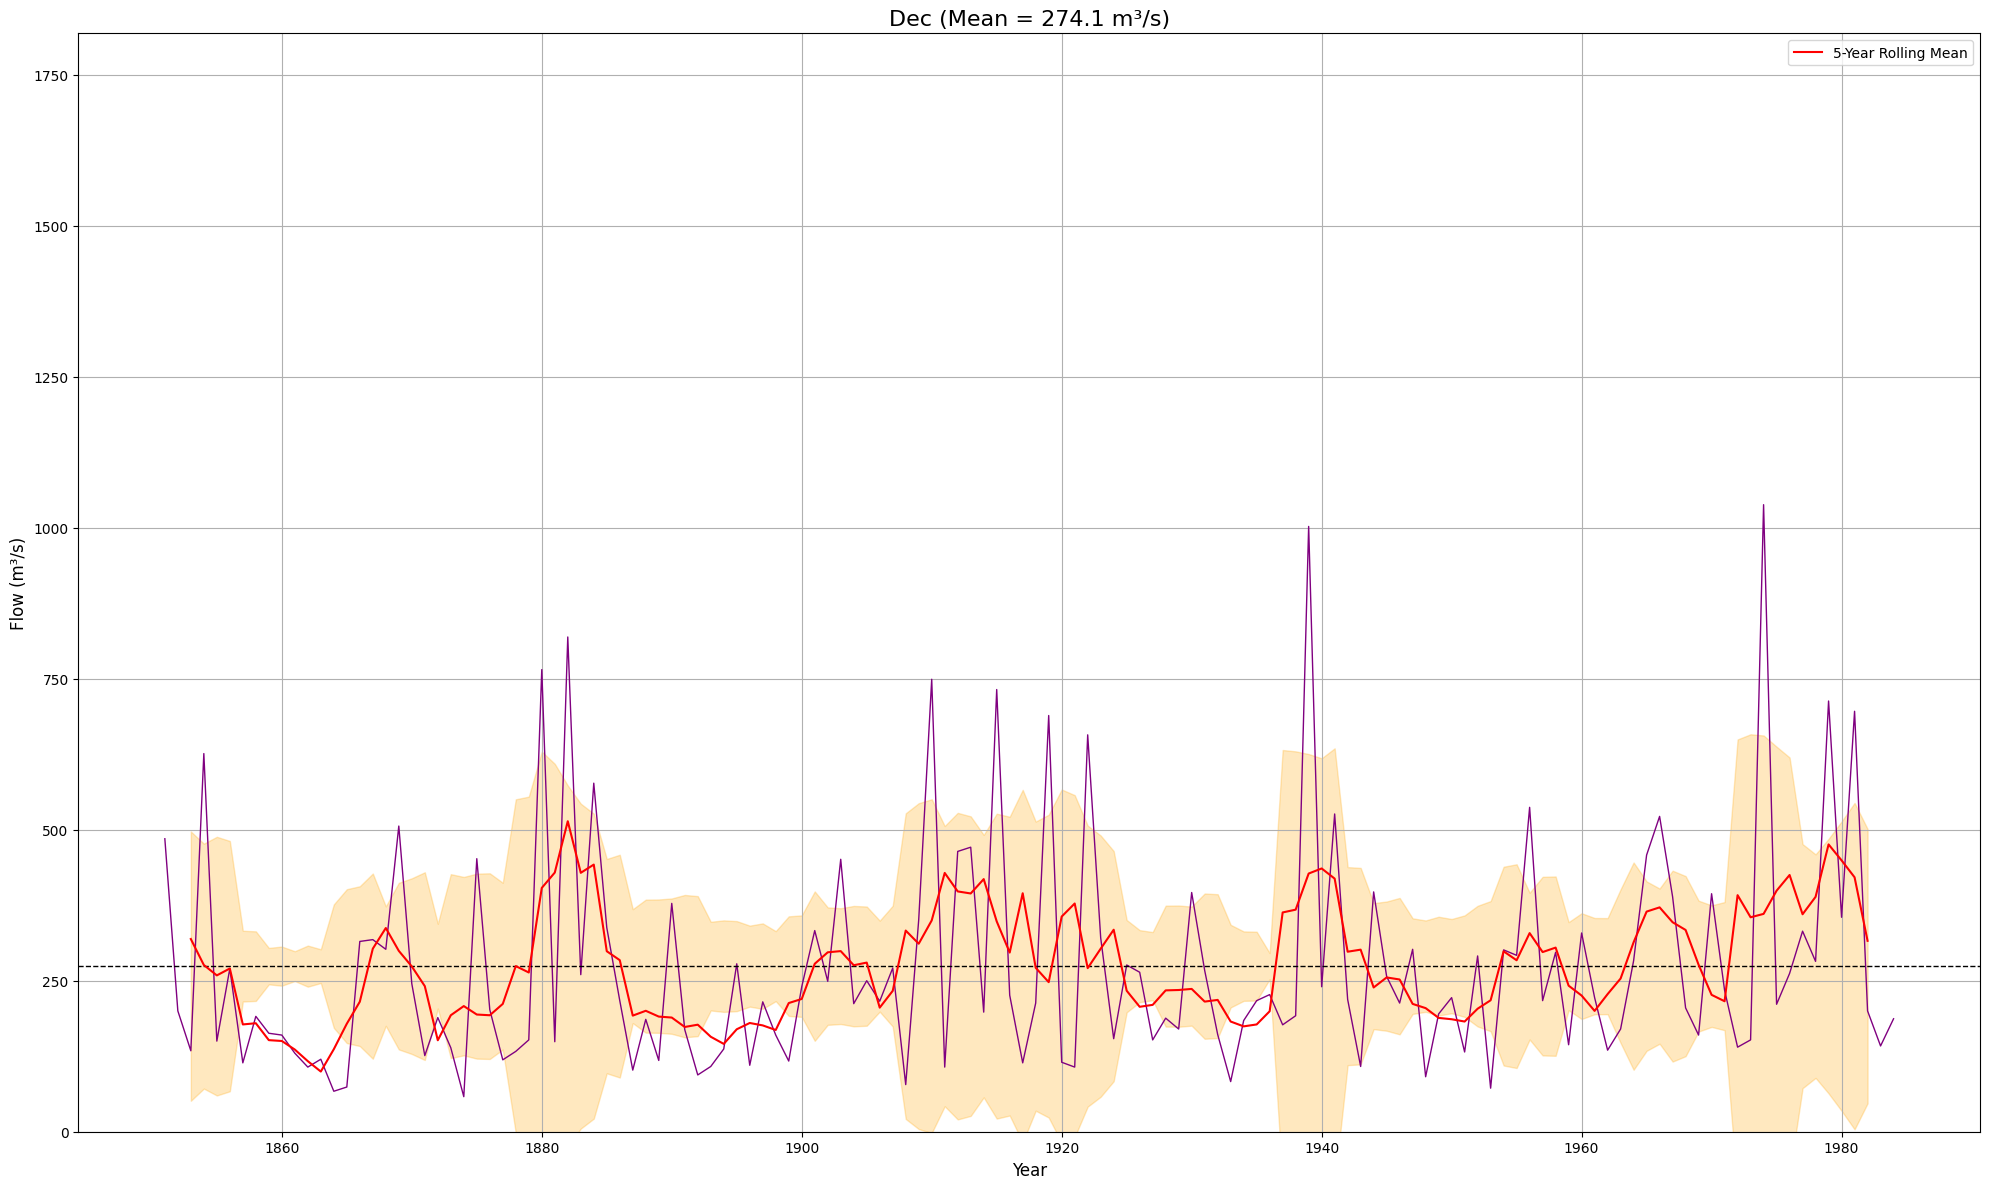

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

window = 5  # rolling window in years

for idx, month in enumerate(months):
    fig, ax = plt.subplots(figsize=(20, 12))

    data = df[month]

    # Plot monthly data
    ax.plot(df["Year"], data, color='purple', linewidth=1)

    # Add long-term mean line
    ax.axhline(avg[idx], color='black', linestyle='--', linewidth=1)

    # Compute and plot rolling mean
    rolling_mean = data.rolling(window=window, center=True).mean()
    ax.plot(df["Year"], rolling_mean, color='red', linewidth=1.5,
            label=f'{window}-Year Rolling Mean')

    # Compute and shade rolling std deviation
    rolling_std = data.rolling(window=window, center=True).std()
    ax.fill_between(
        df["Year"],
        avg[idx] - rolling_std,
        avg[idx] + rolling_std,
        color='orange',
        alpha=0.25
    )

    # Title
    ax.set_title(f"{month} (Mean = {avg[idx]:.1f} m³/s)", fontsize=16)

    # Labels
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel("Flow (m³/s)", fontsize=12)
    ax.grid(True)

    # Same y-scale across all figures
    ax.set_ylim(0, max(df[months].max()) * 1.1)

    # Legend (now per chart)
    ax.legend()

    plt.tight_layout()
    plt.show()

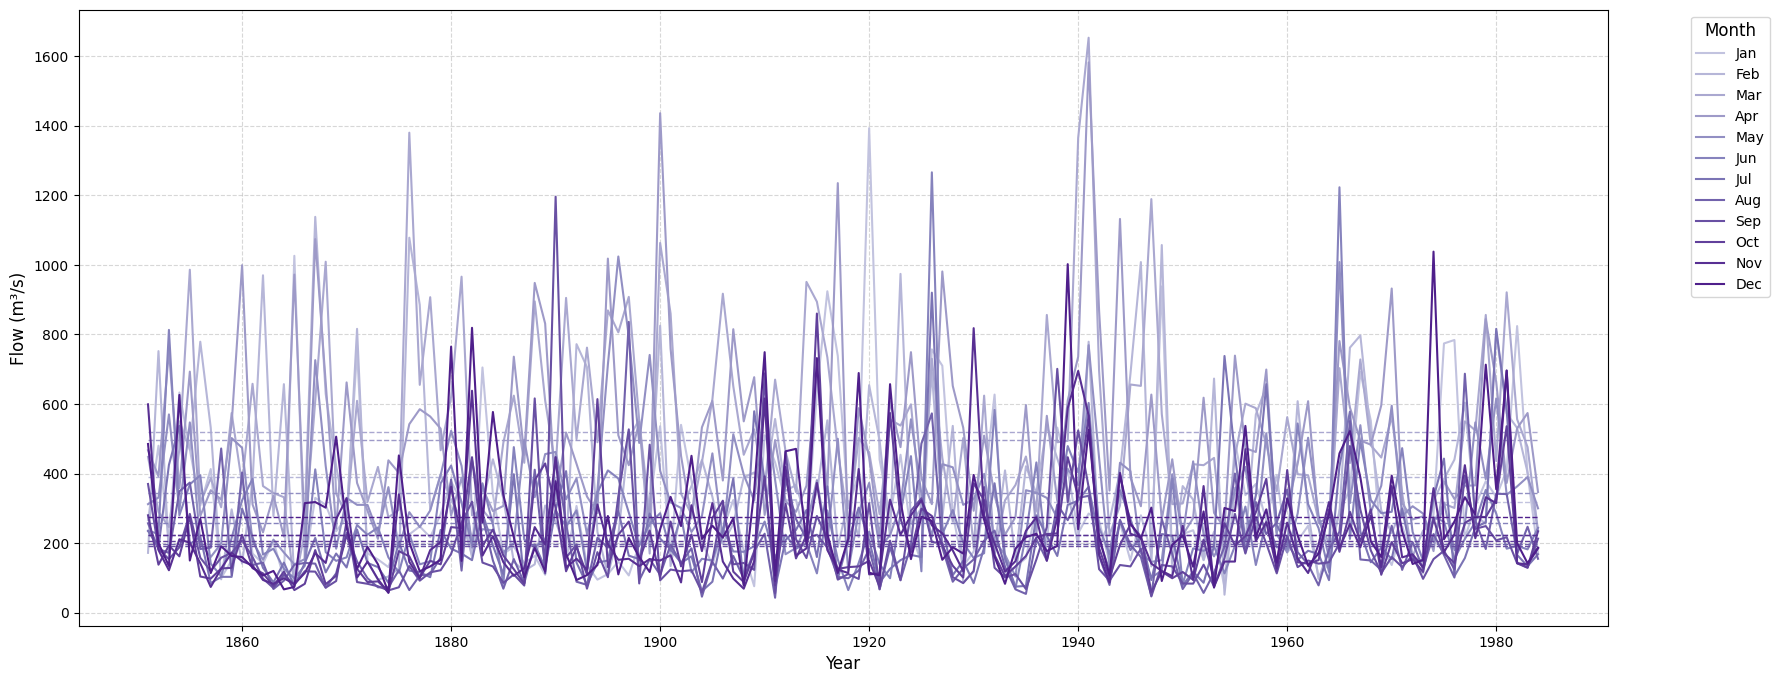

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Color palette with 12 distinct colors
#colors = cm.tab20c.colors
colors = cm.Purples(np.linspace(0.35, 0.9, 12))

plt.figure(figsize=(22, 8))

for idx, month in enumerate(months):
    # Plot monthly discharge
    plt.plot(df["Year"], df[month], color=colors[idx], linewidth=1.5, label=month)

    # Long-term mean
    plt.hlines(avg[idx], df["Year"].min(), df["Year"].max(),
               colors=colors[idx], linestyles='--', linewidth=1)

# Titles and labels
#plt.title("Monthly Mean Discharge with Long-Term Monthly Means (Elbe River, Decin)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Flow (m³/s)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Legend outside
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left",
           fontsize=10, title_fontsize=12)
plt.subplots_adjust(right=0.82)

plt.show()

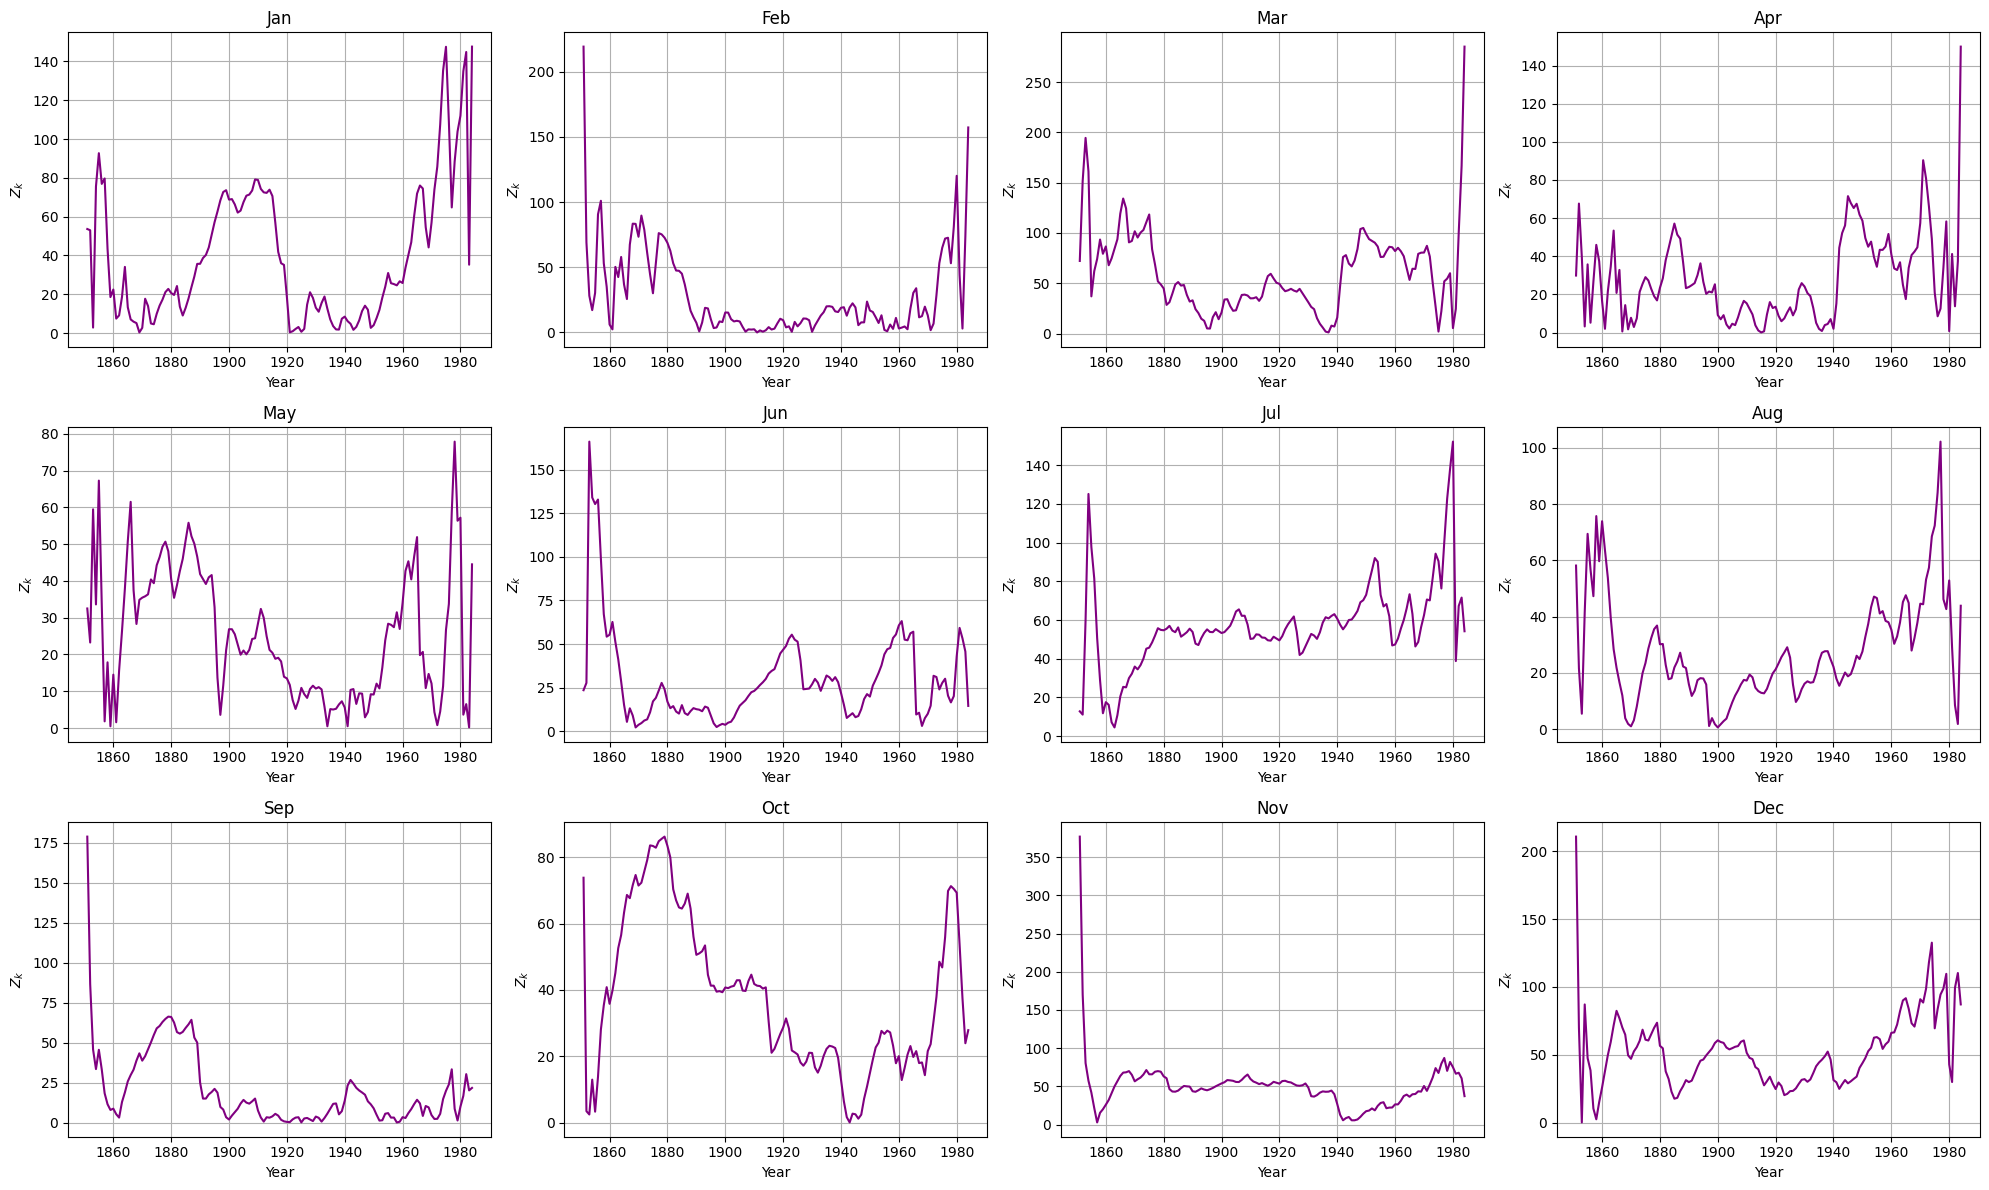

In [38]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()  # flatten to index easily

for idx, month in enumerate(months):
    data = df[month]

    # Forward cumulative mean
    forward_cummean = data.expanding().mean()

    # Backward cumulative mean
    backward_cummean = data[::-1].expanding().mean()[::-1]

    # Absolute difference
    abs_diff = (forward_cummean - backward_cummean).abs()

    # Plot in corresponding subplot
    axes[idx].plot(df["Year"], abs_diff, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("|Forward - Backward CumMean|")
    axes[idx].grid(True)

plt.tight_layout()
#plt.suptitle("Absolute Difference Between Forward and Backward Cumulative Means for Each Month (Elbe River, Decin)", fontsize=16, y=1.02)
plt.show()

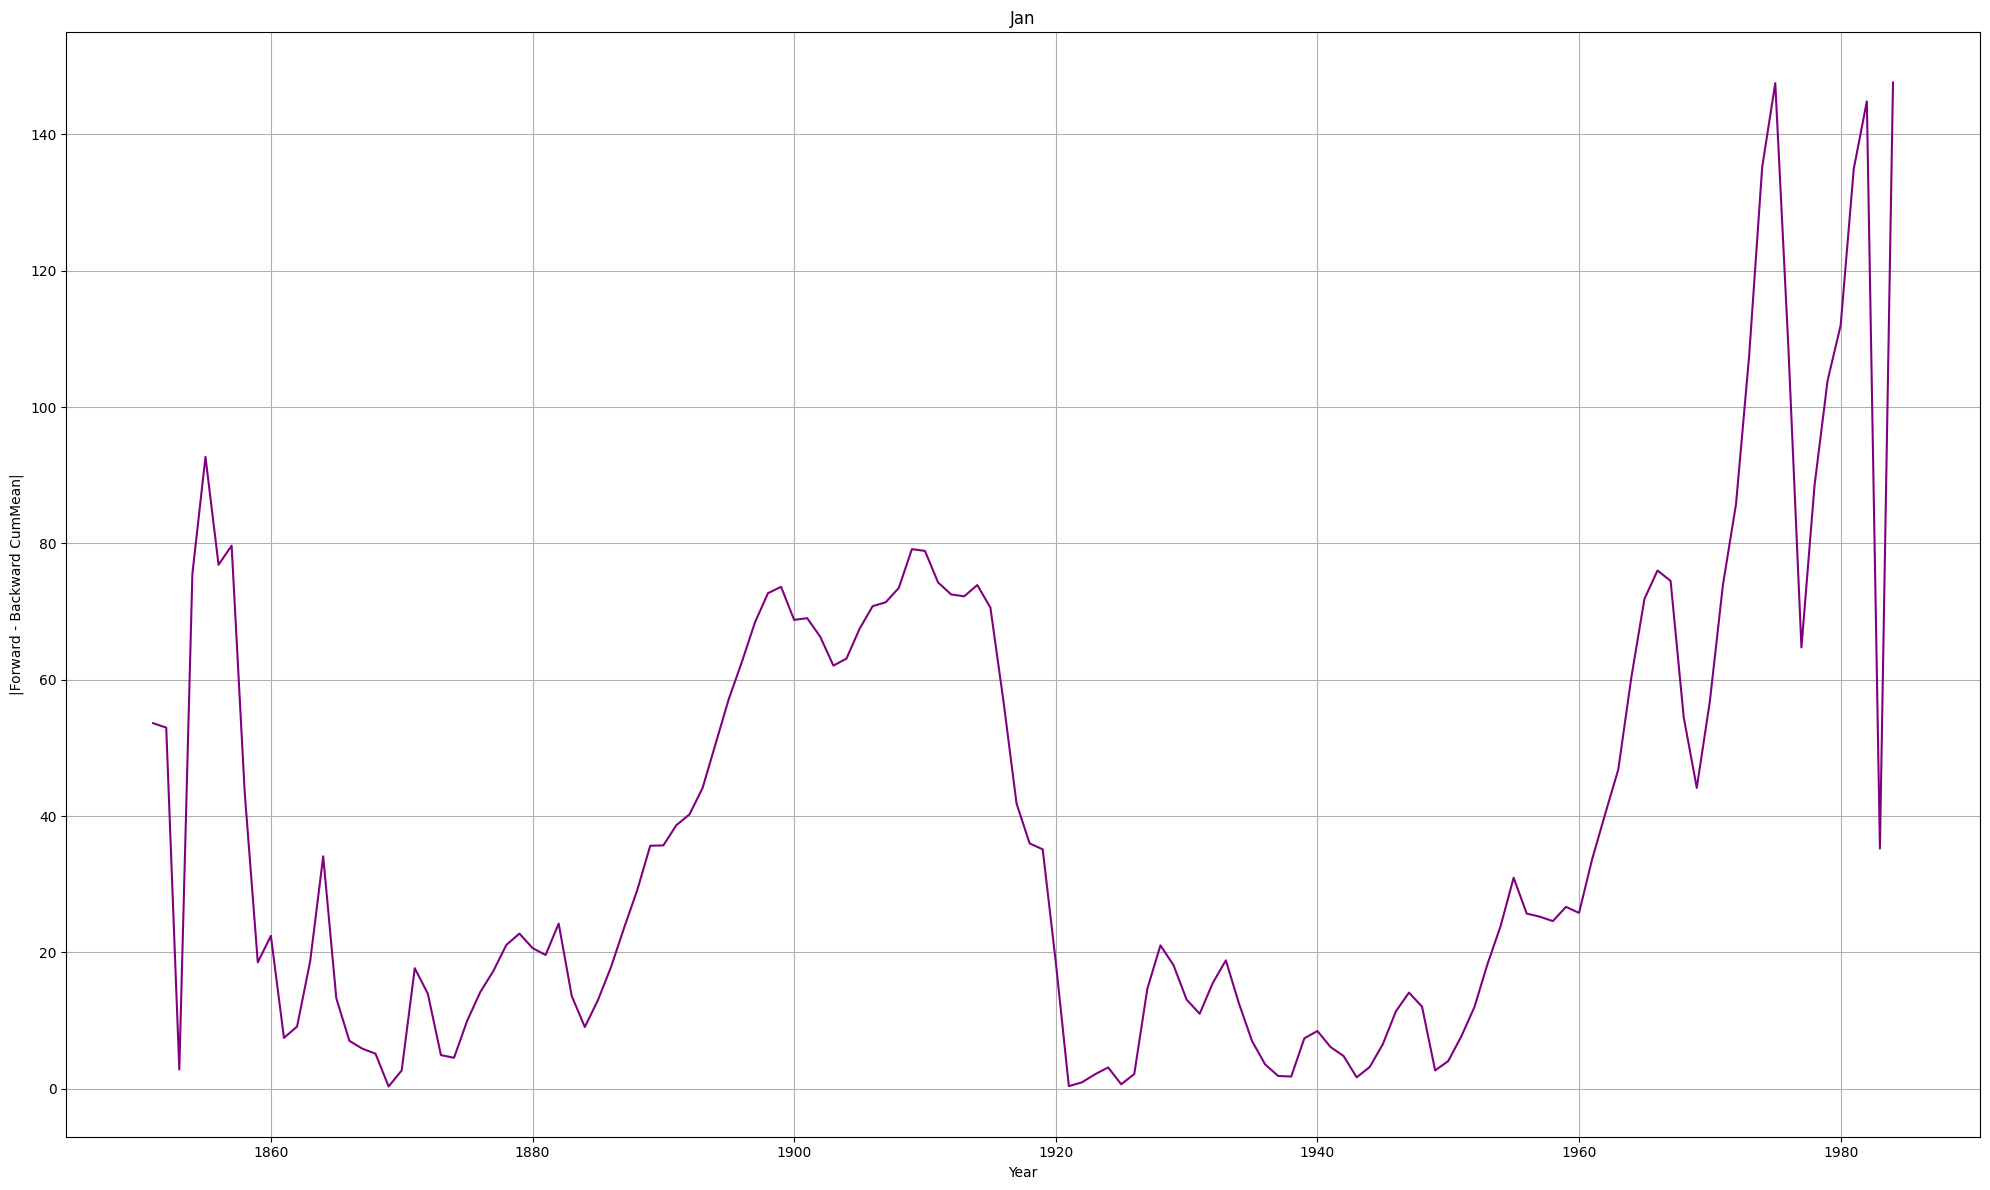

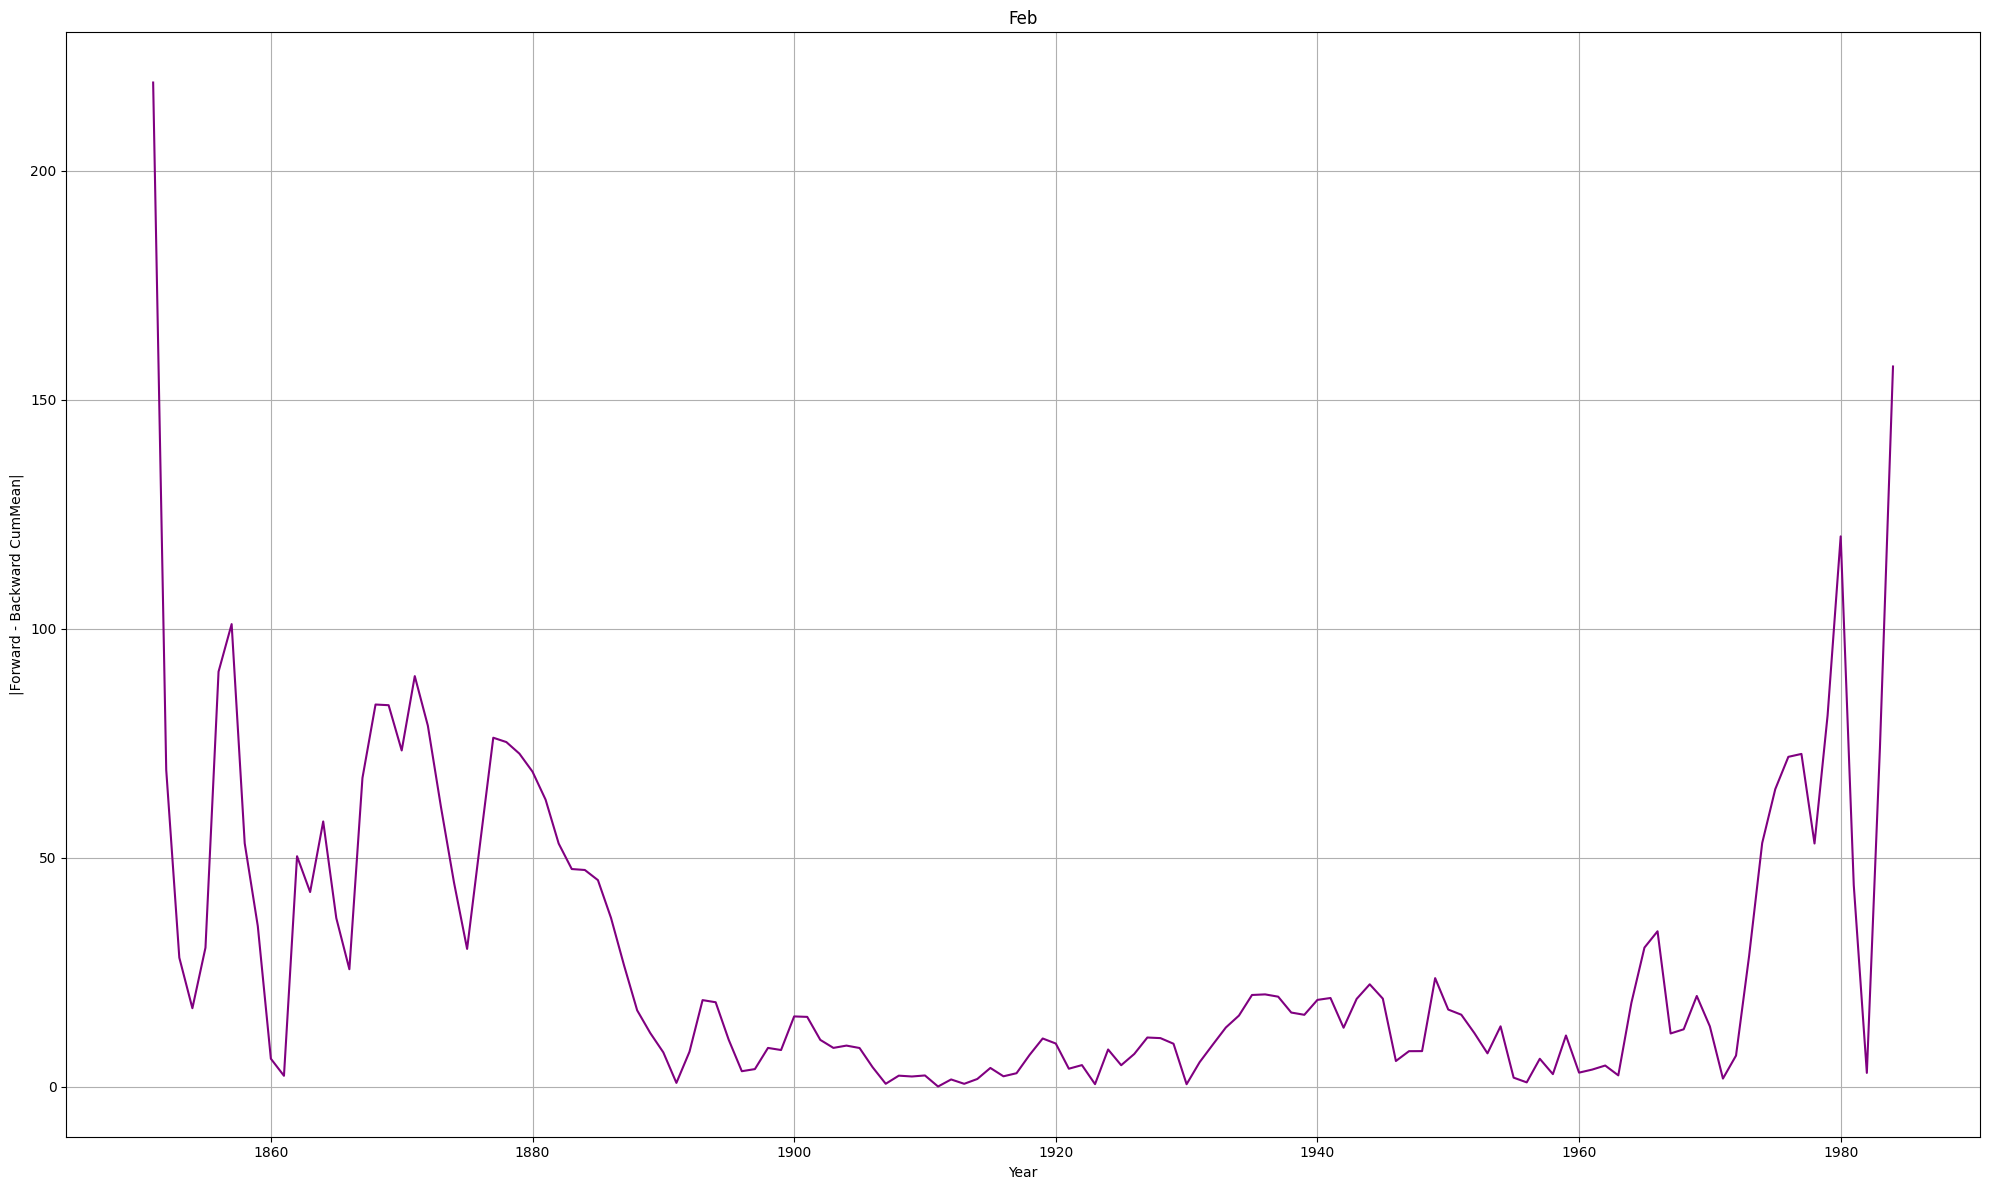

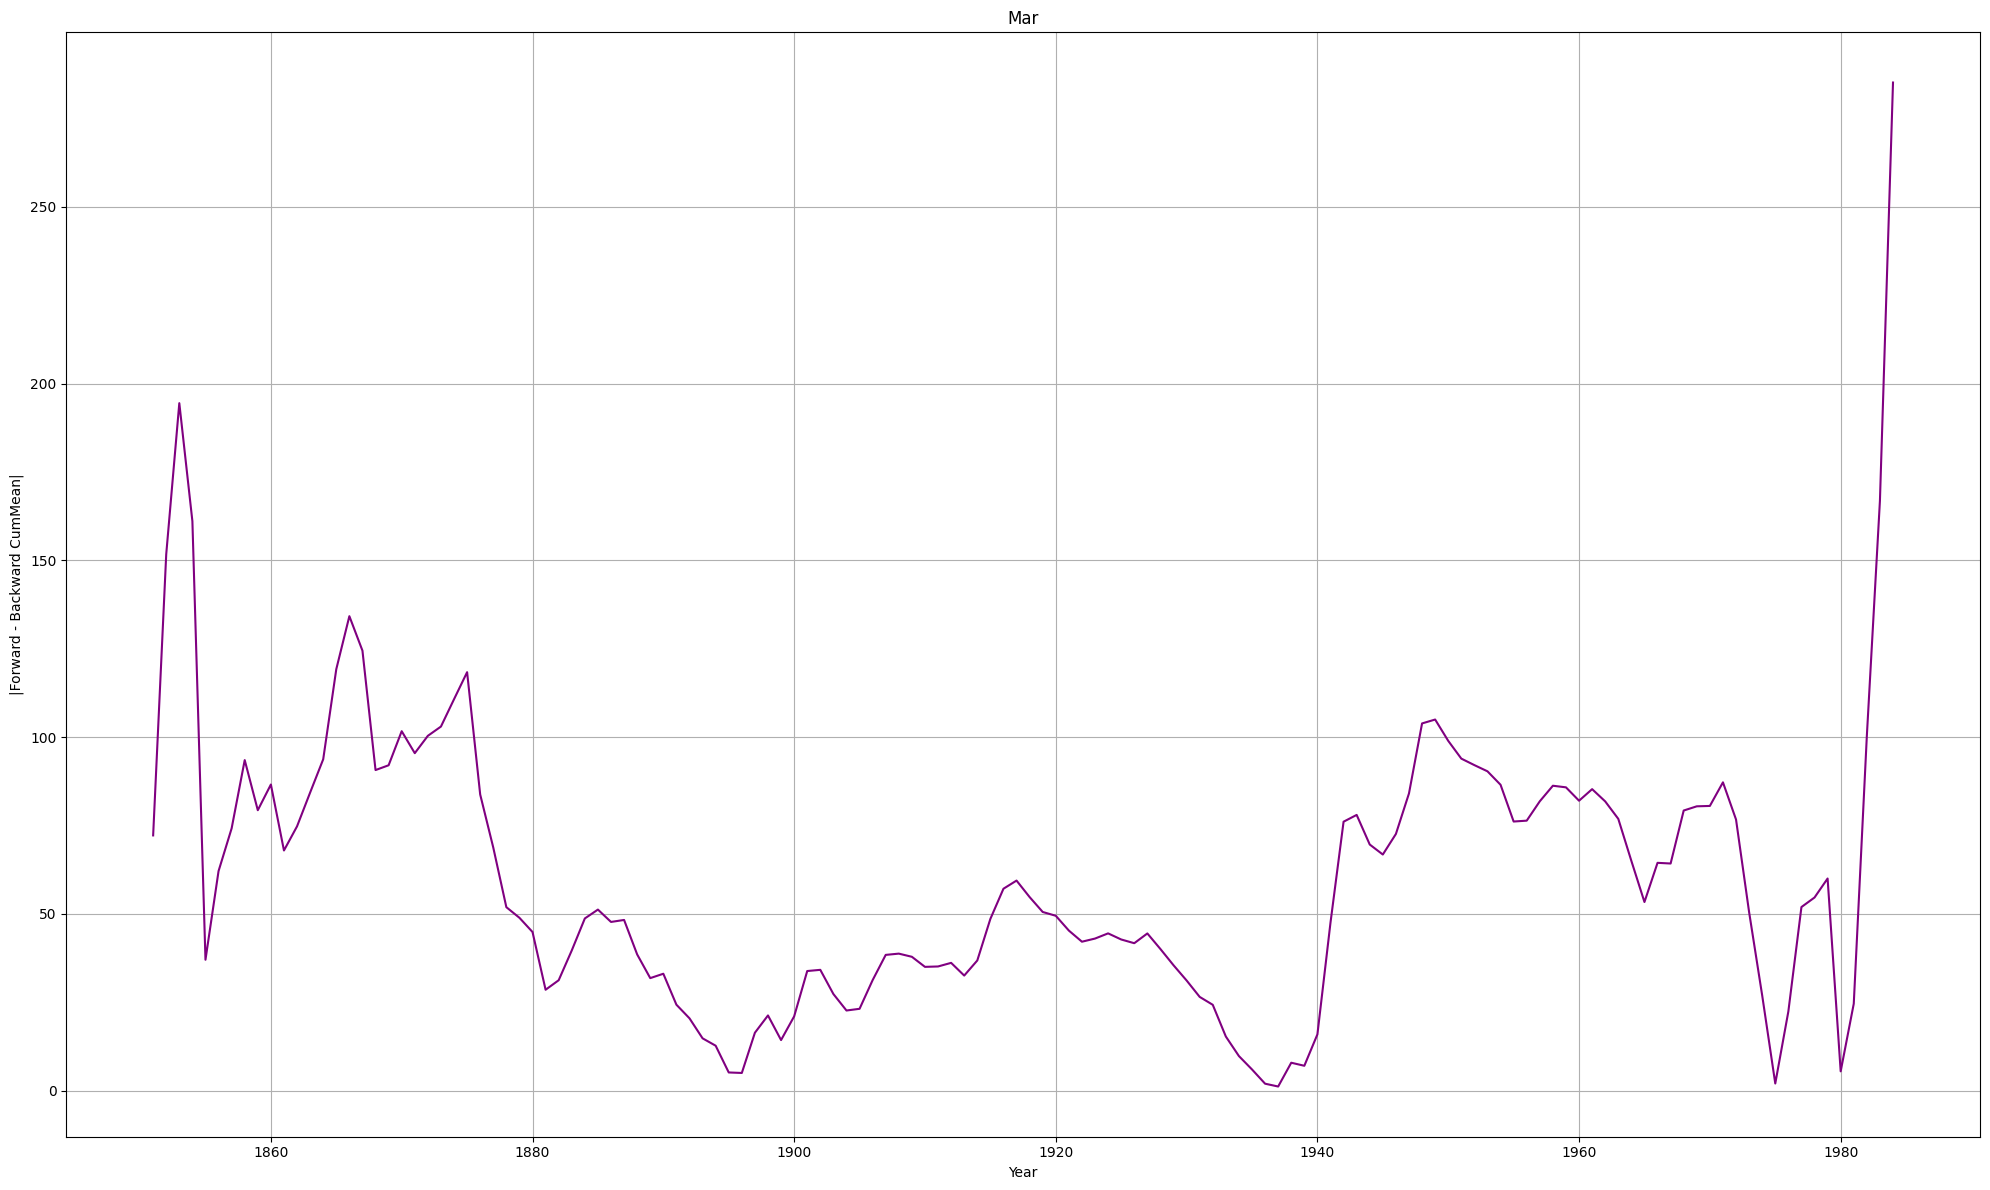

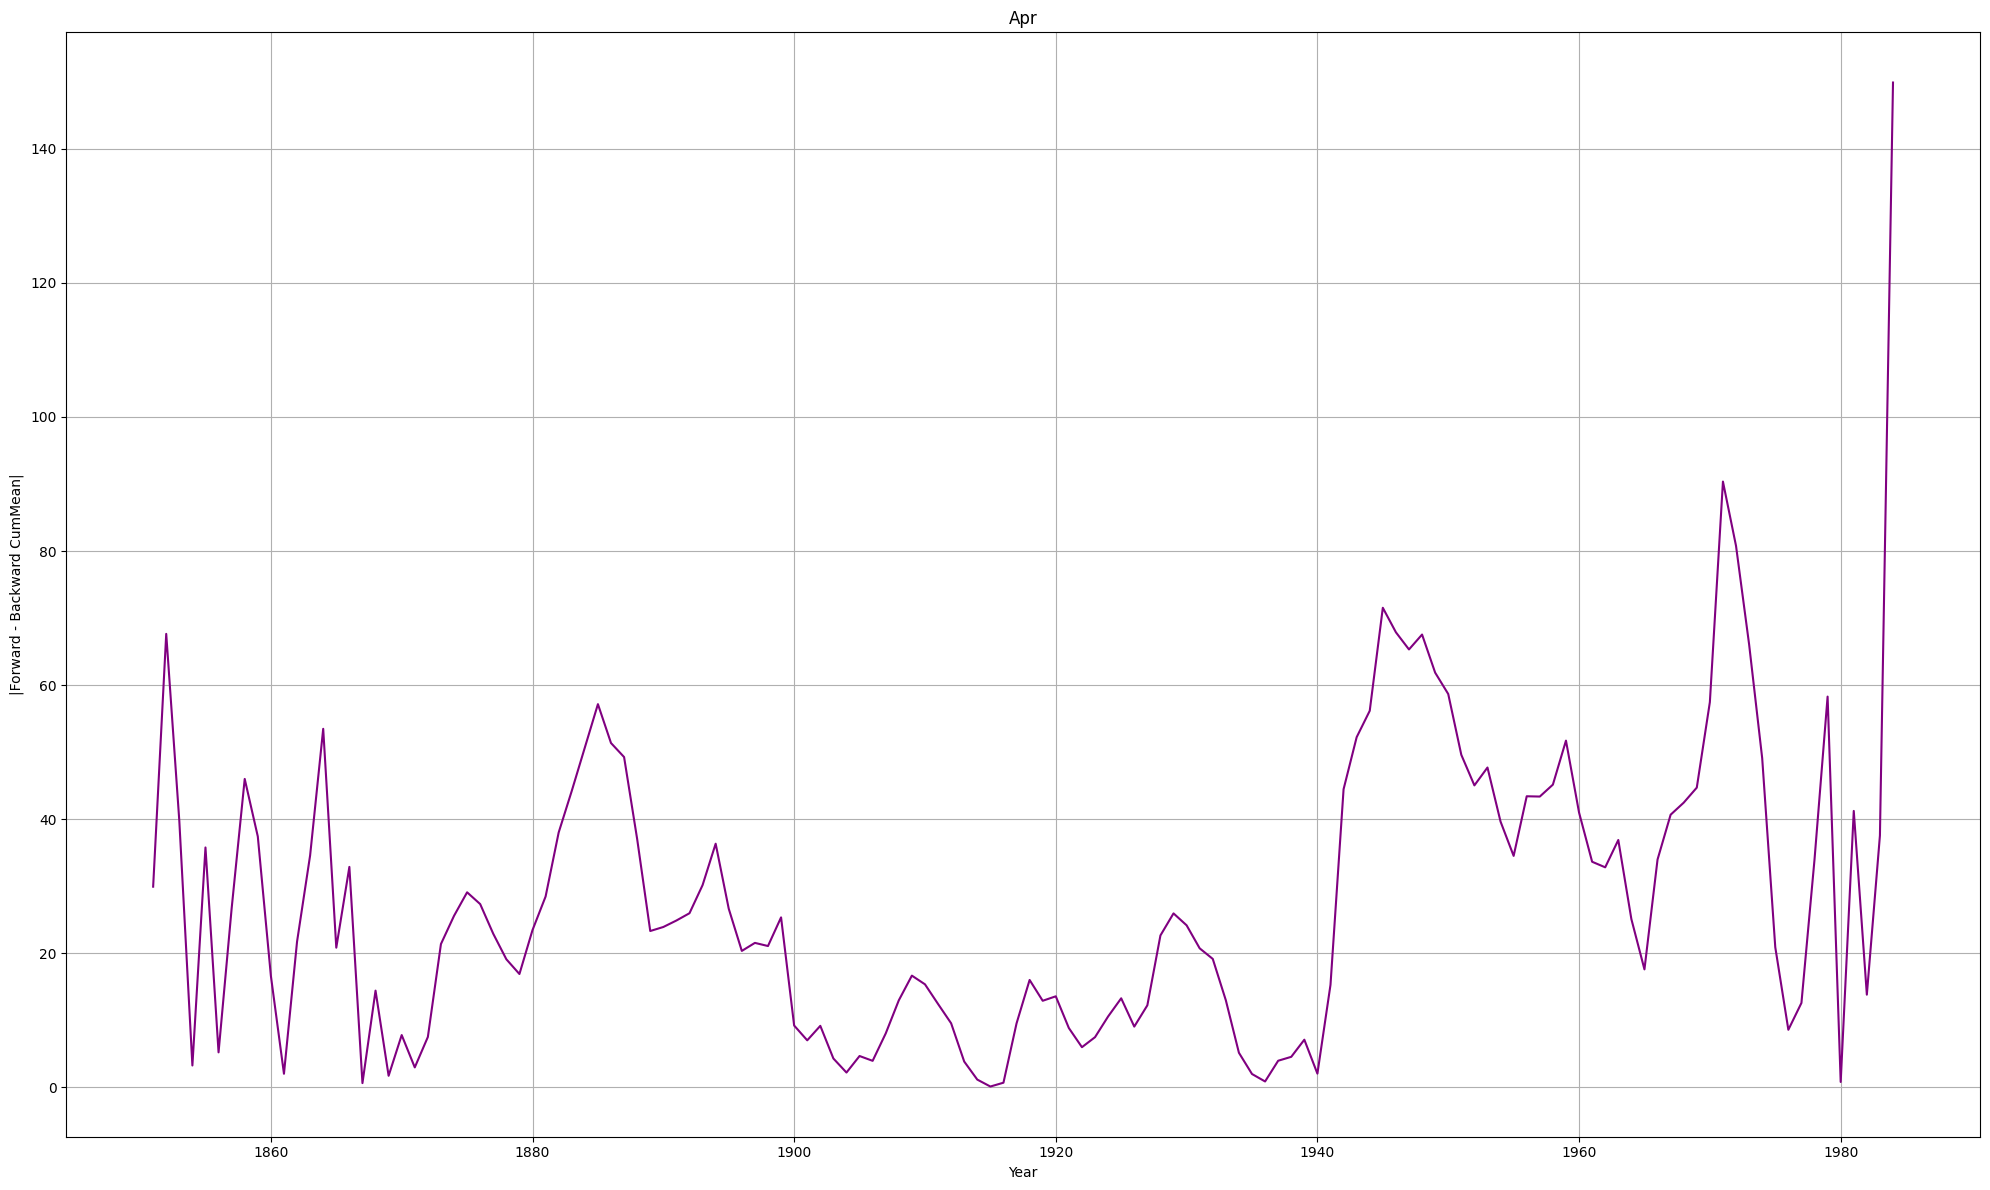

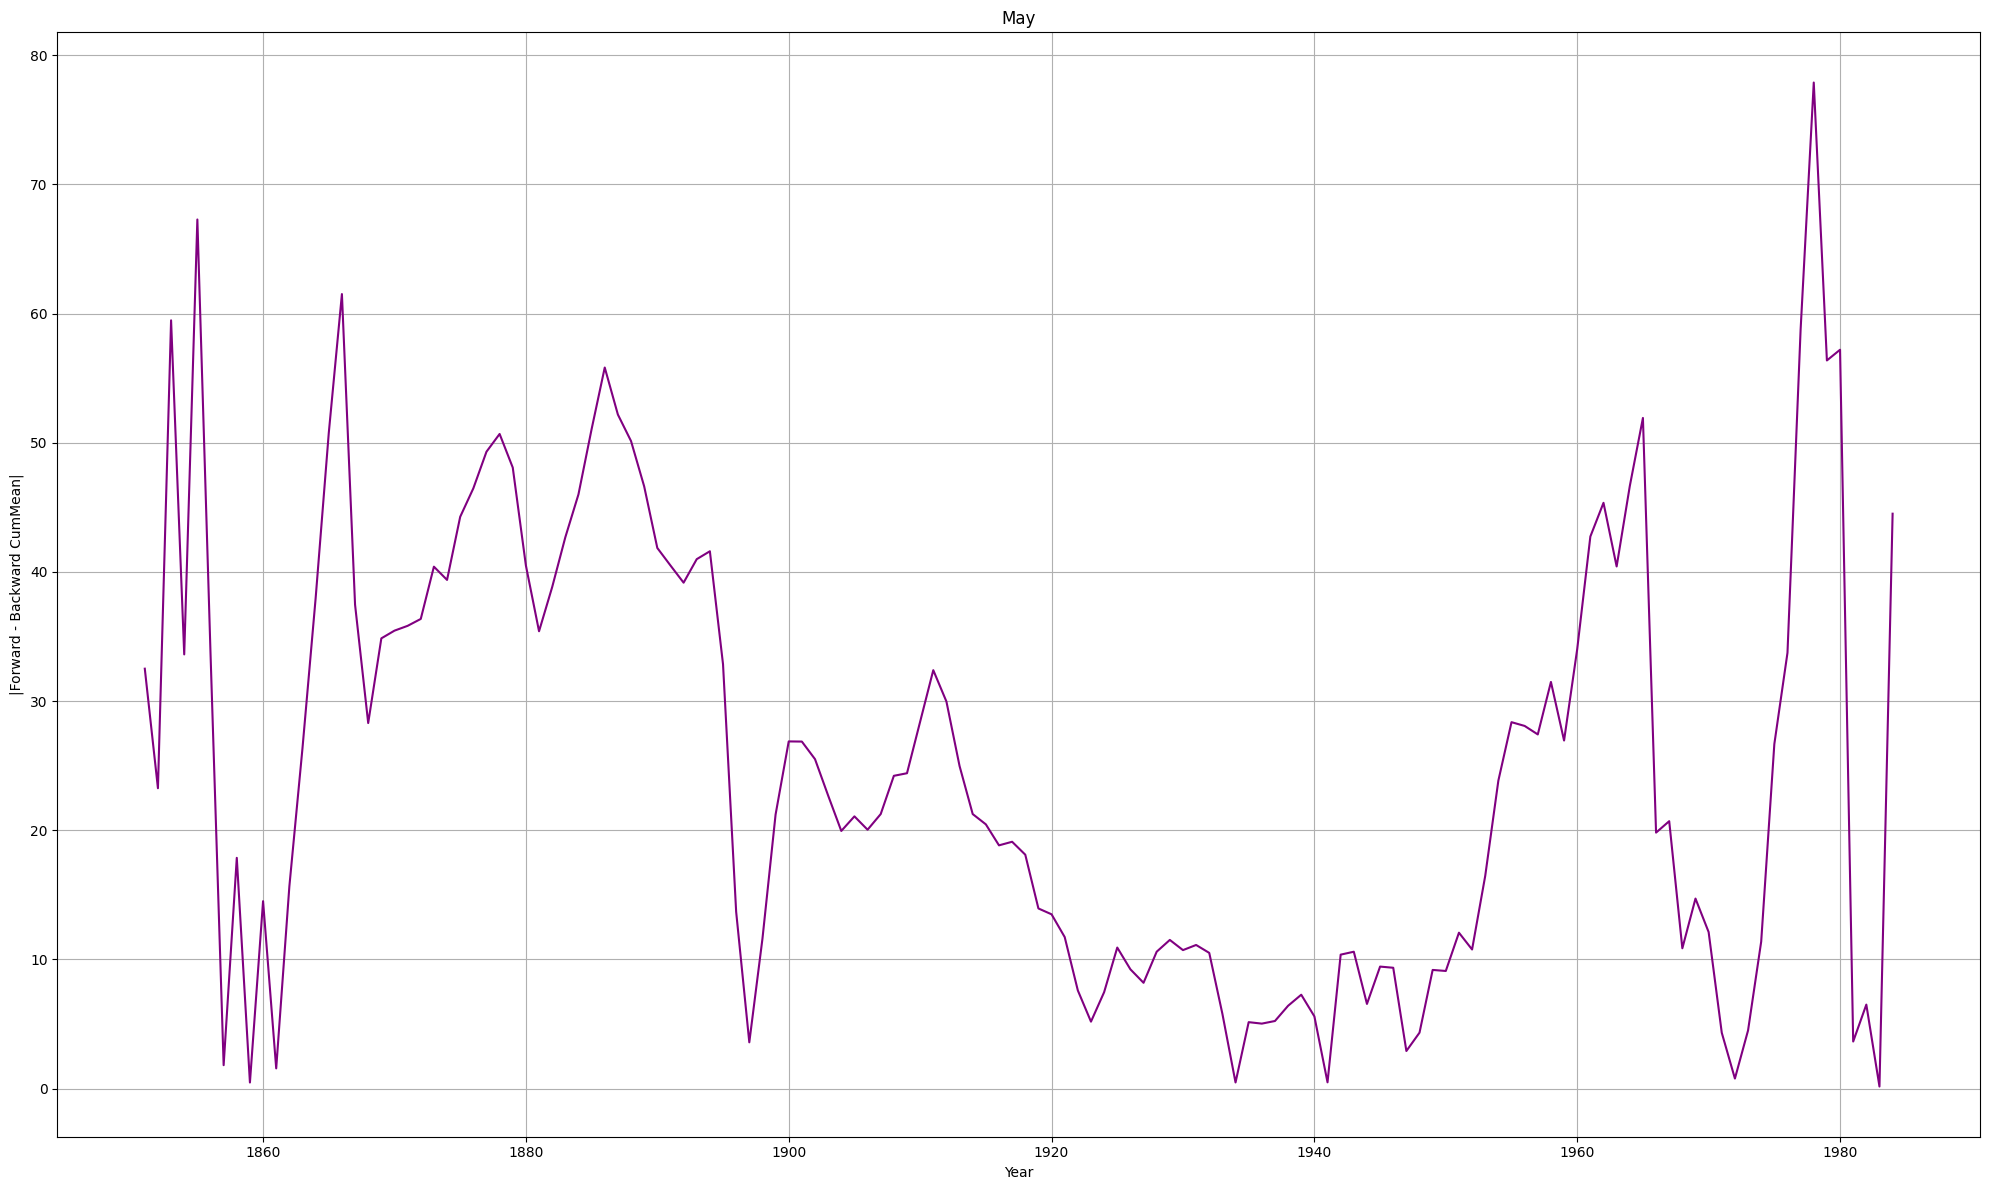

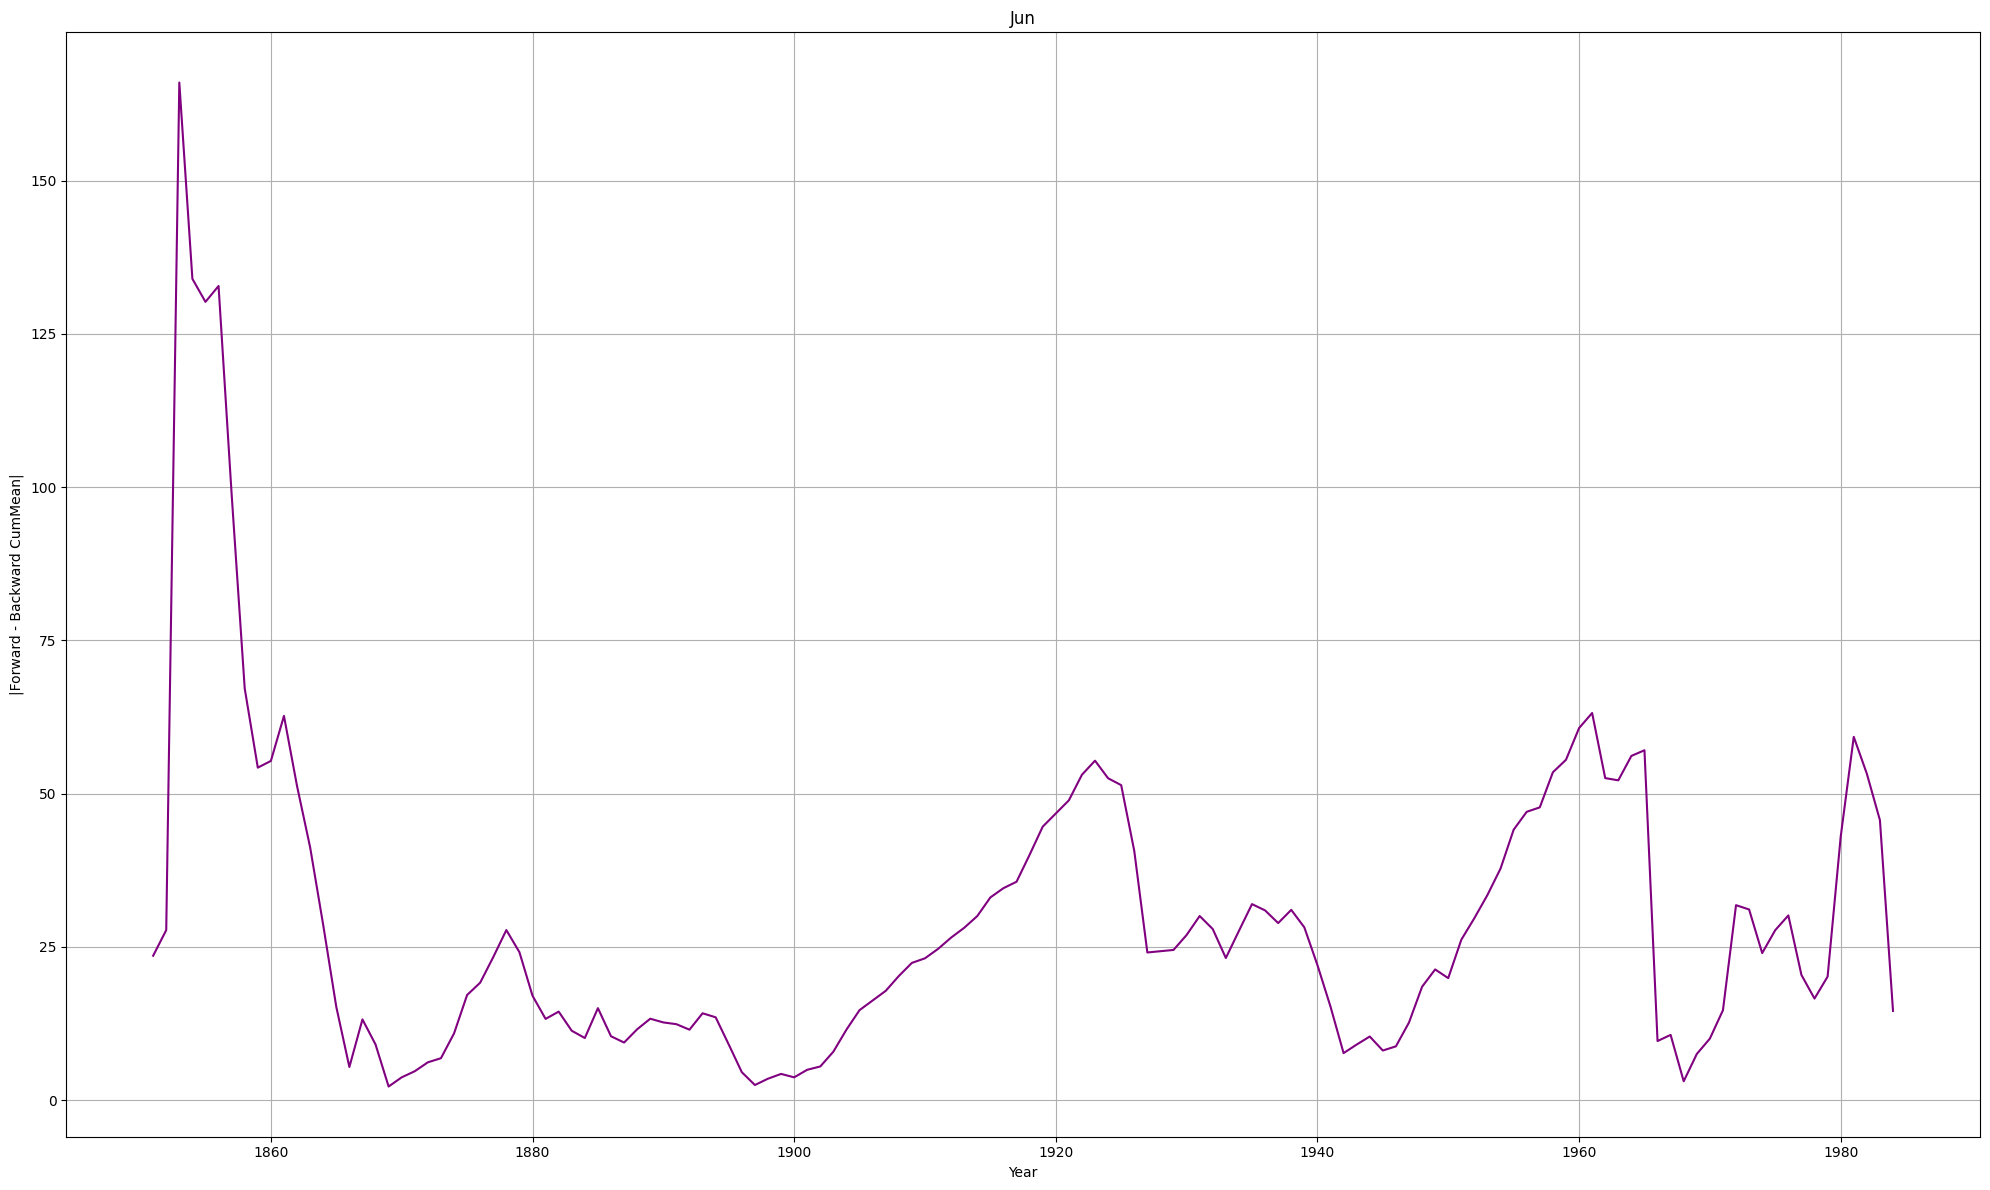

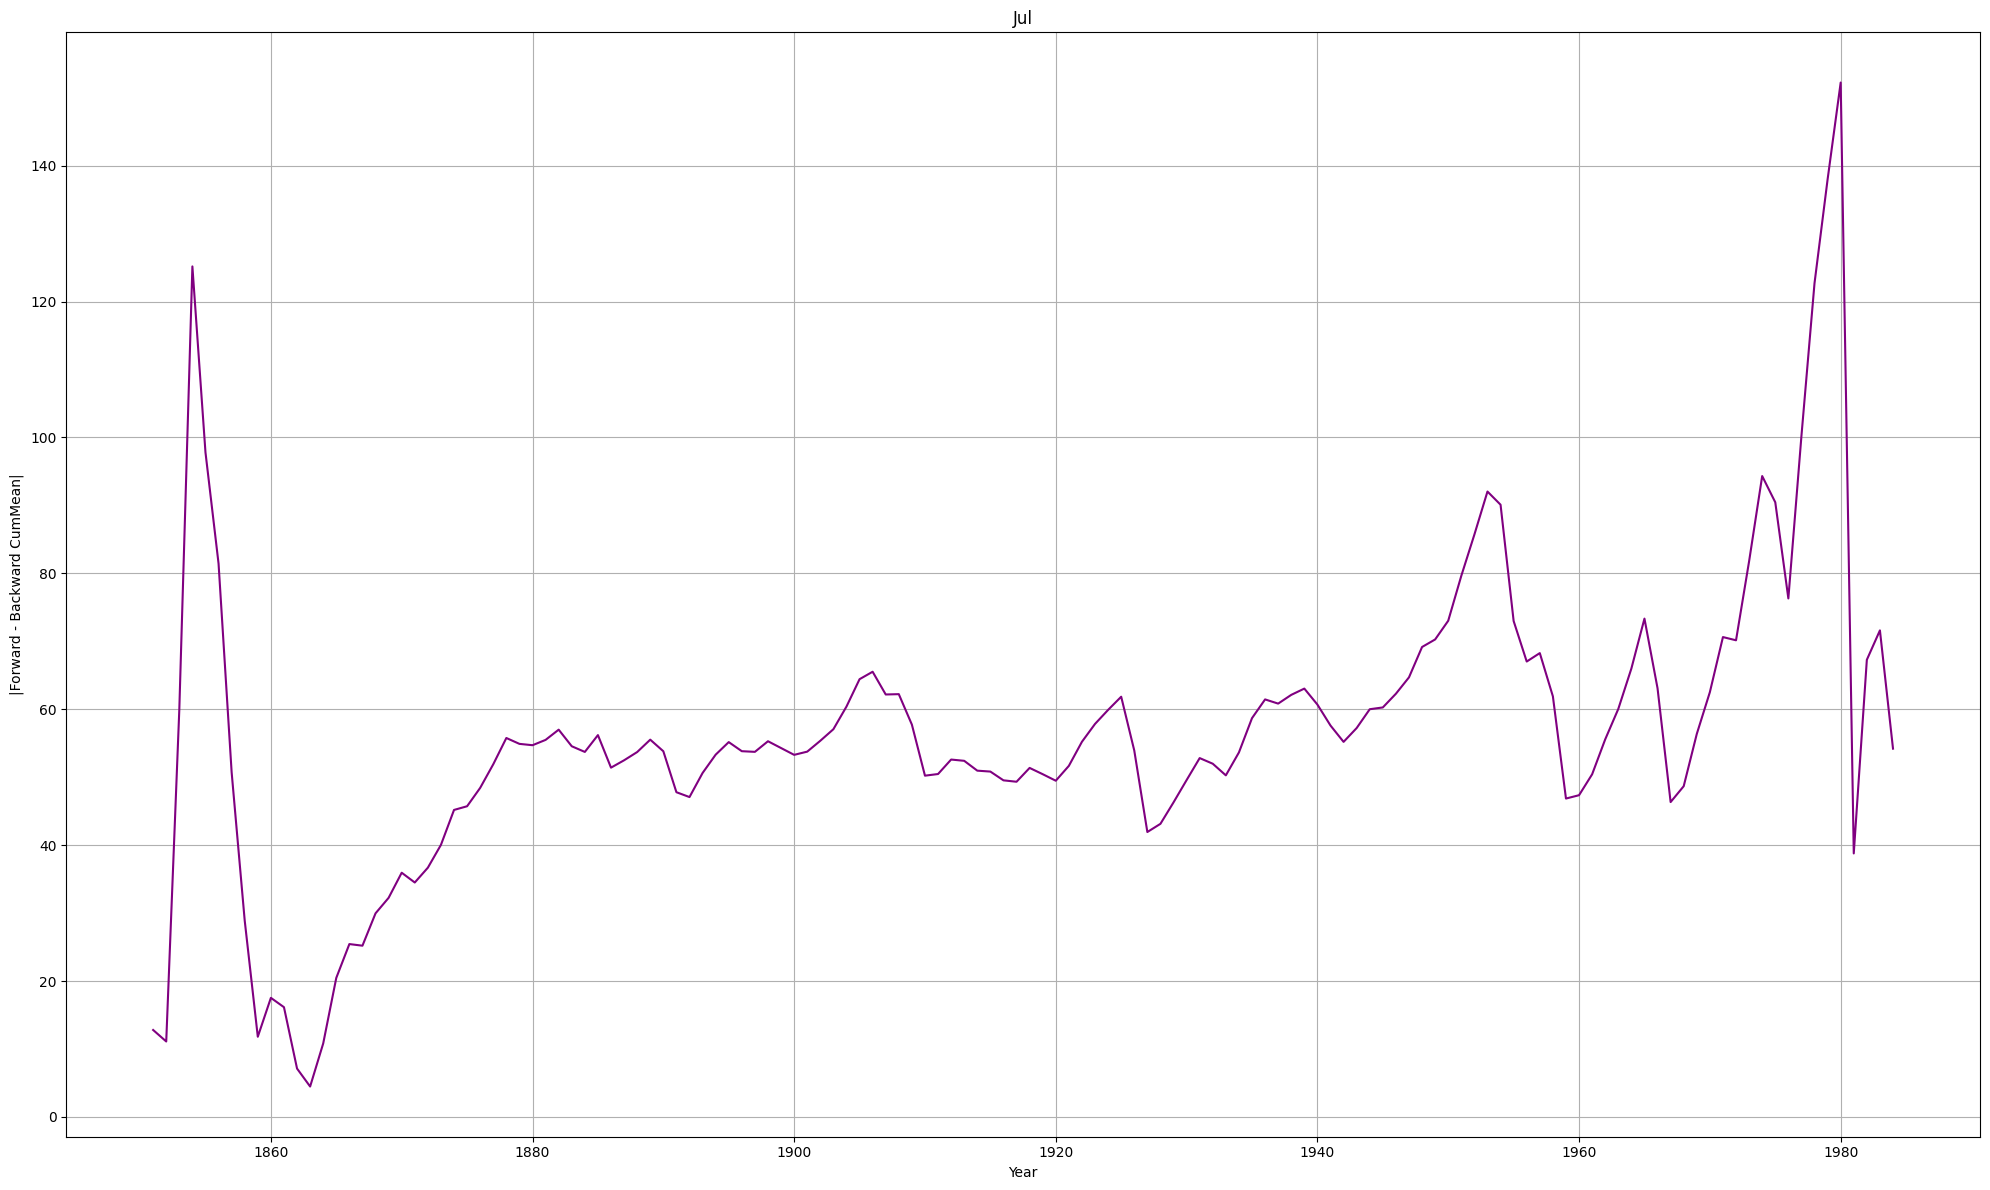

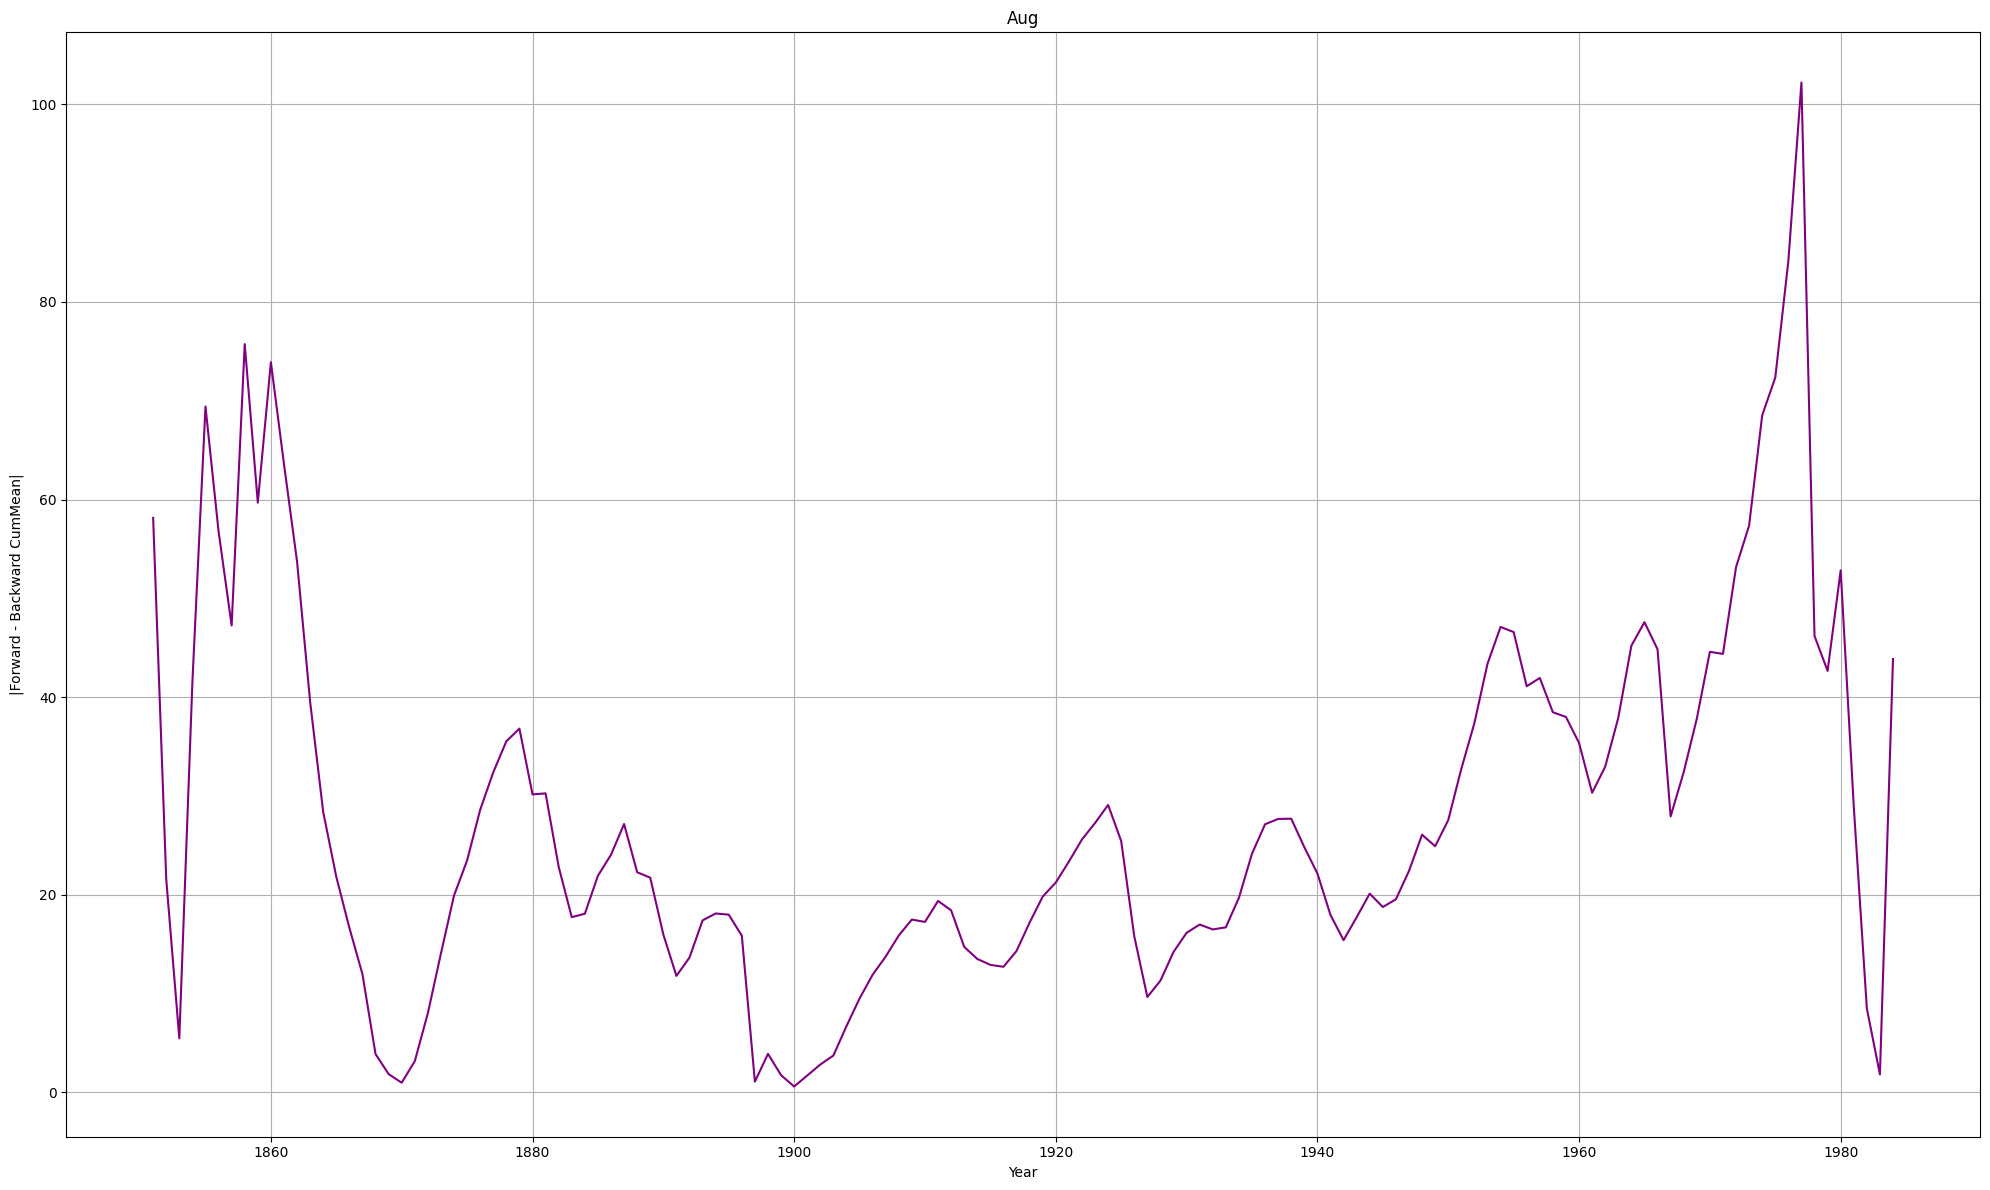

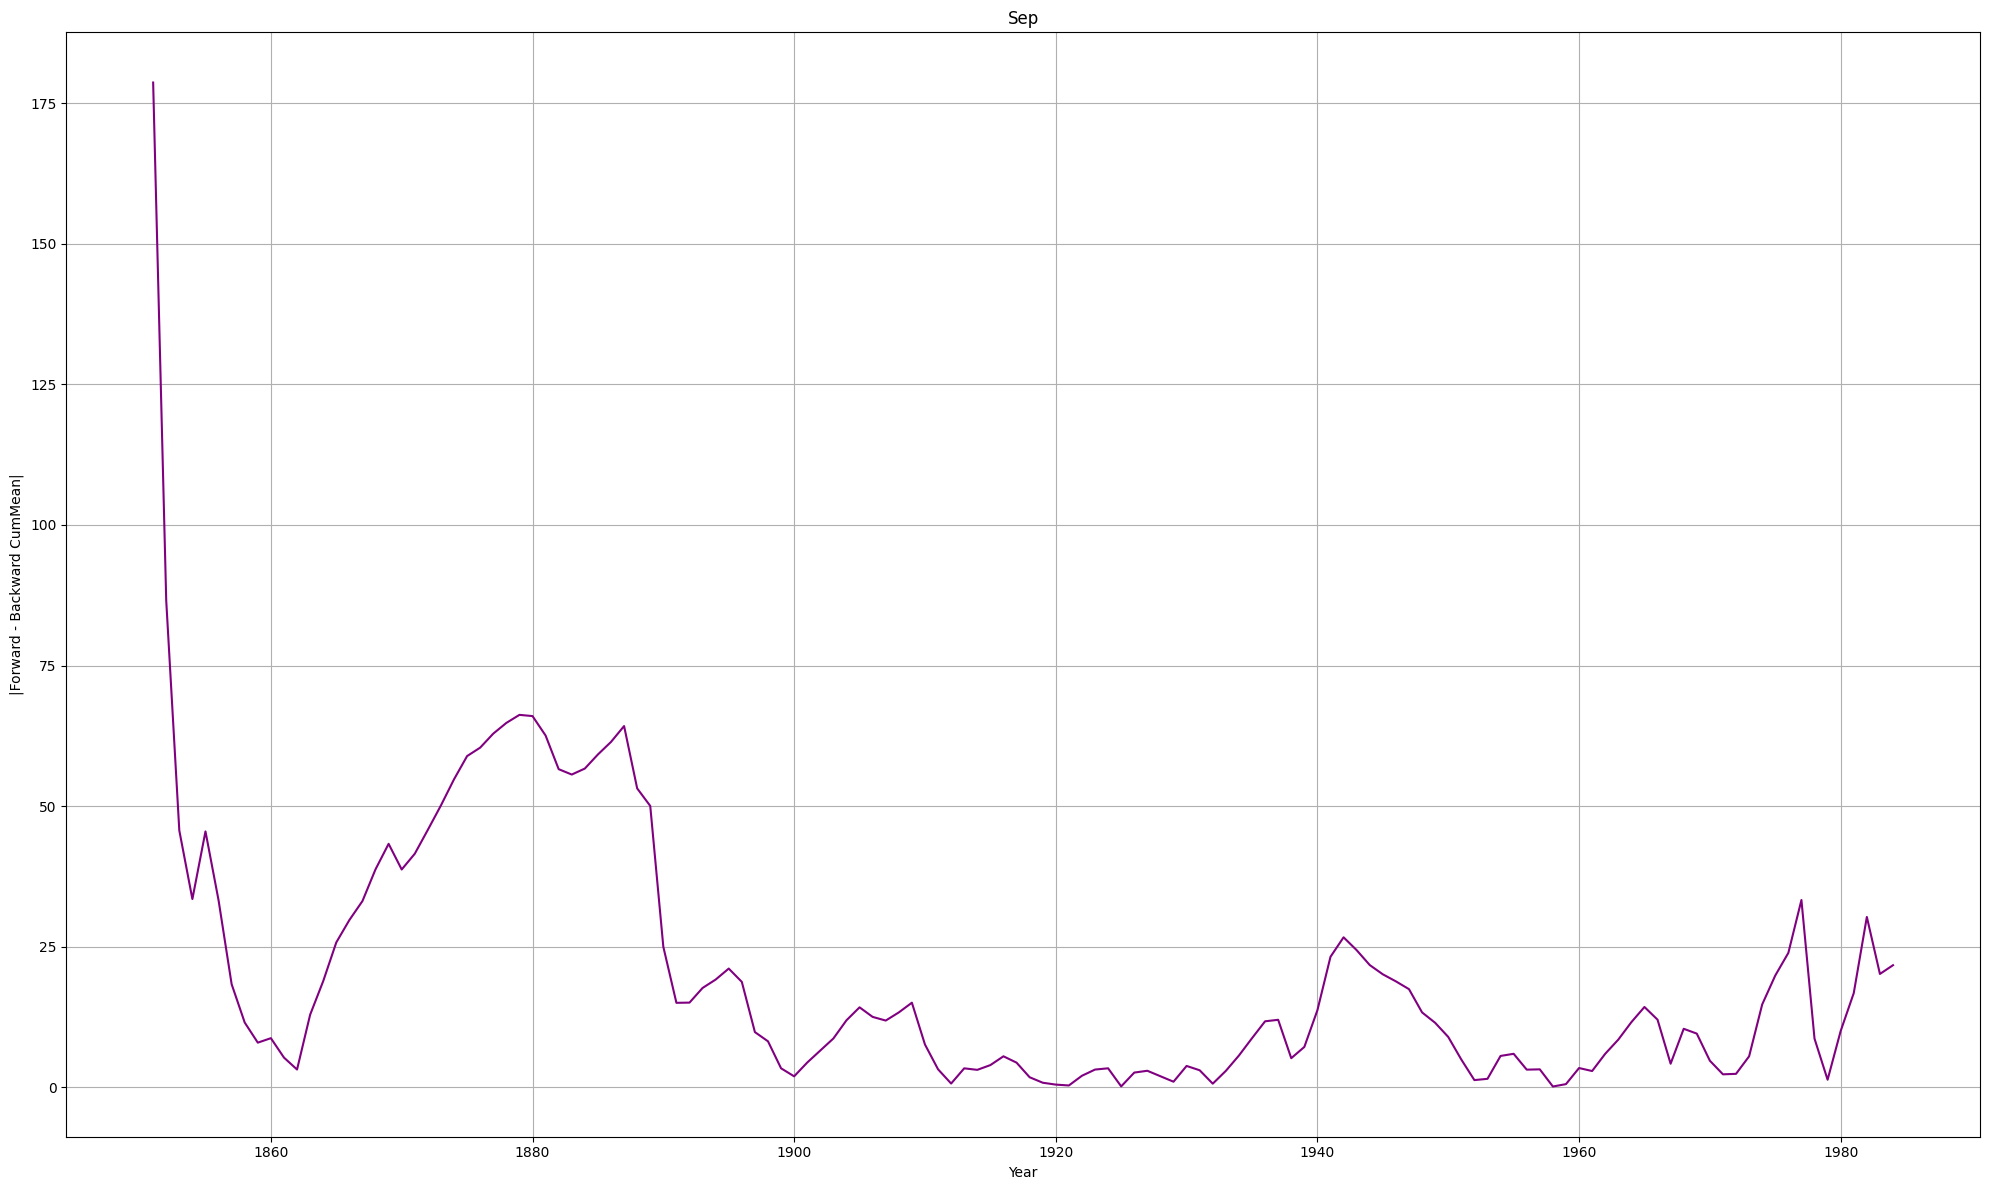

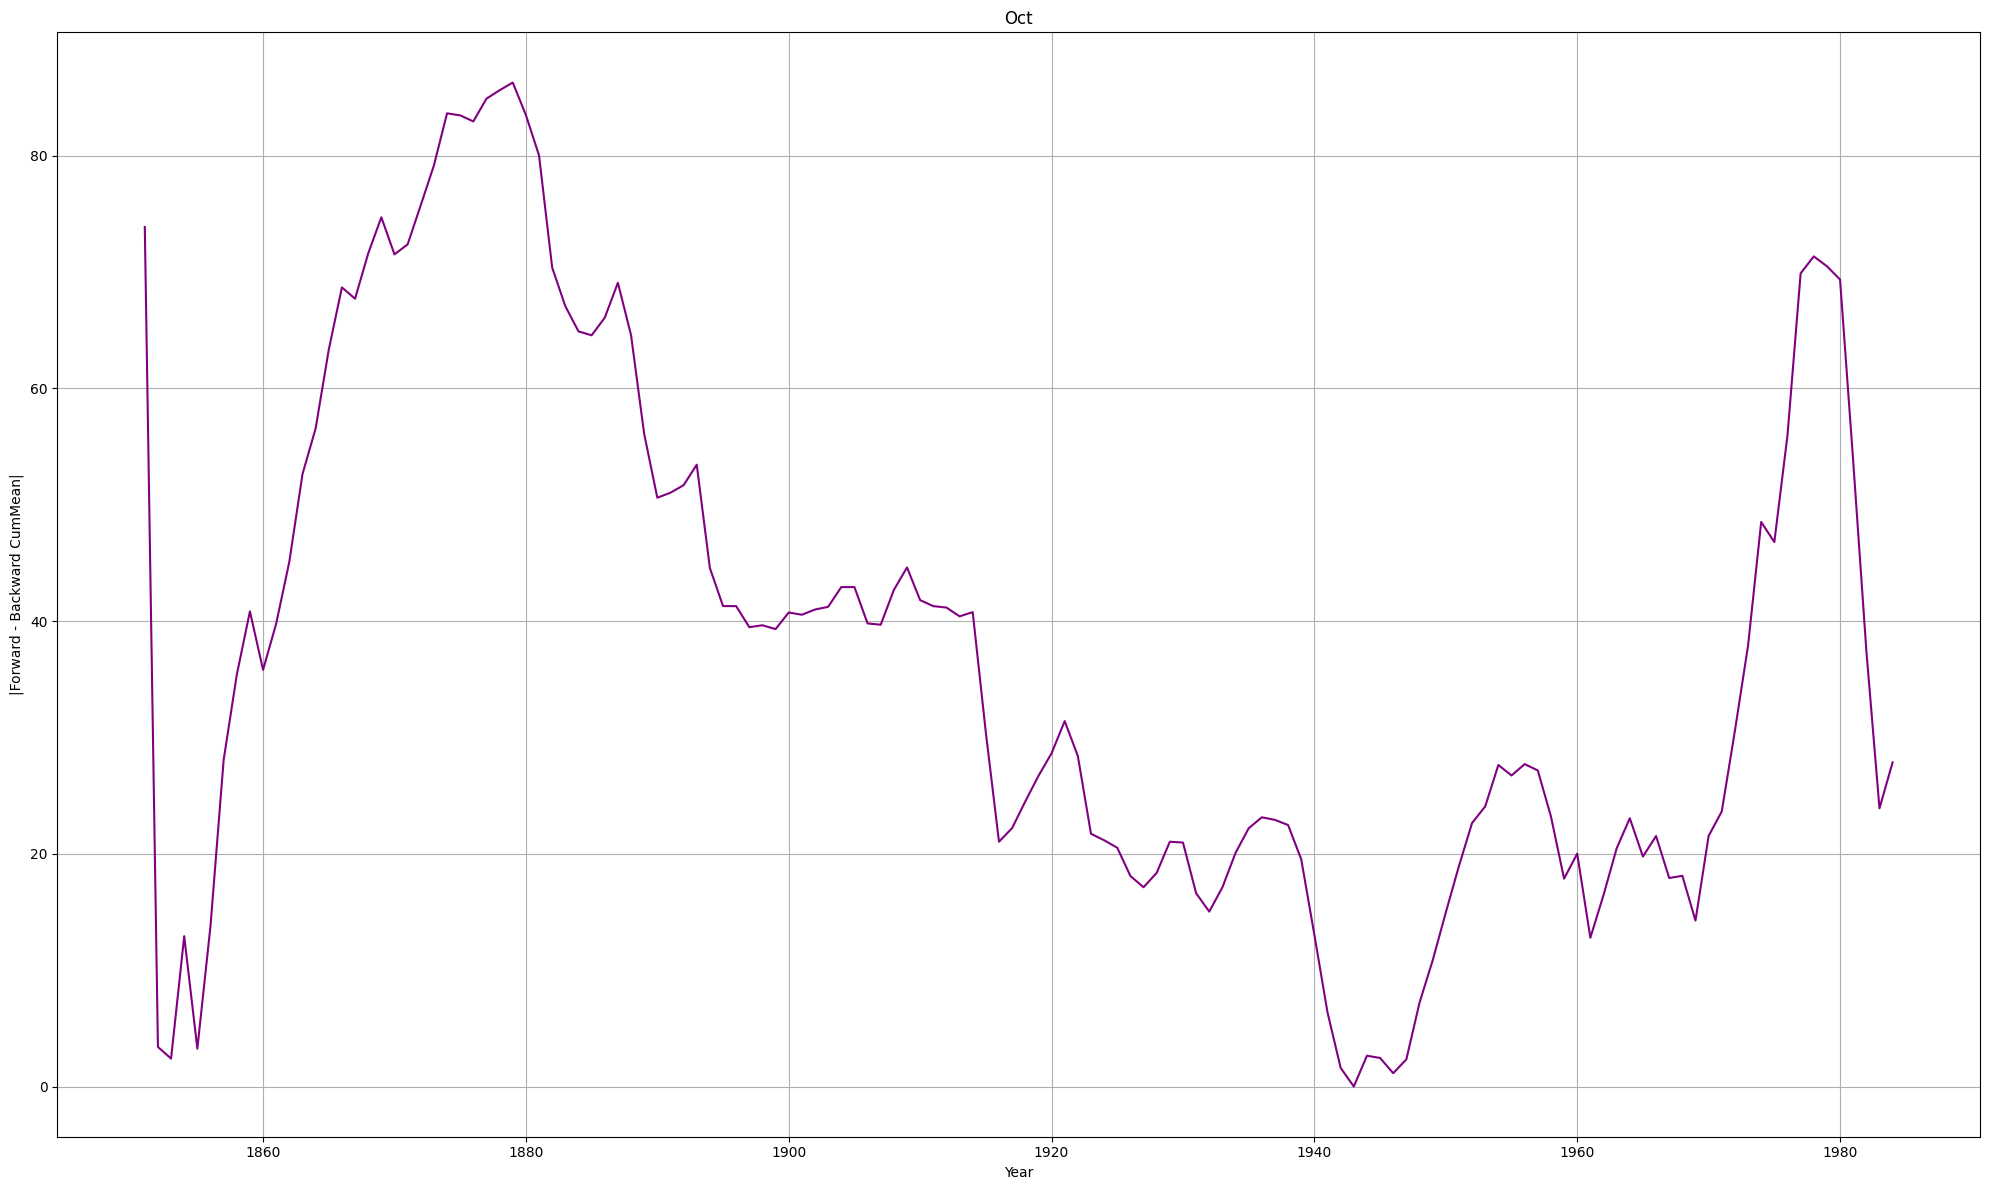

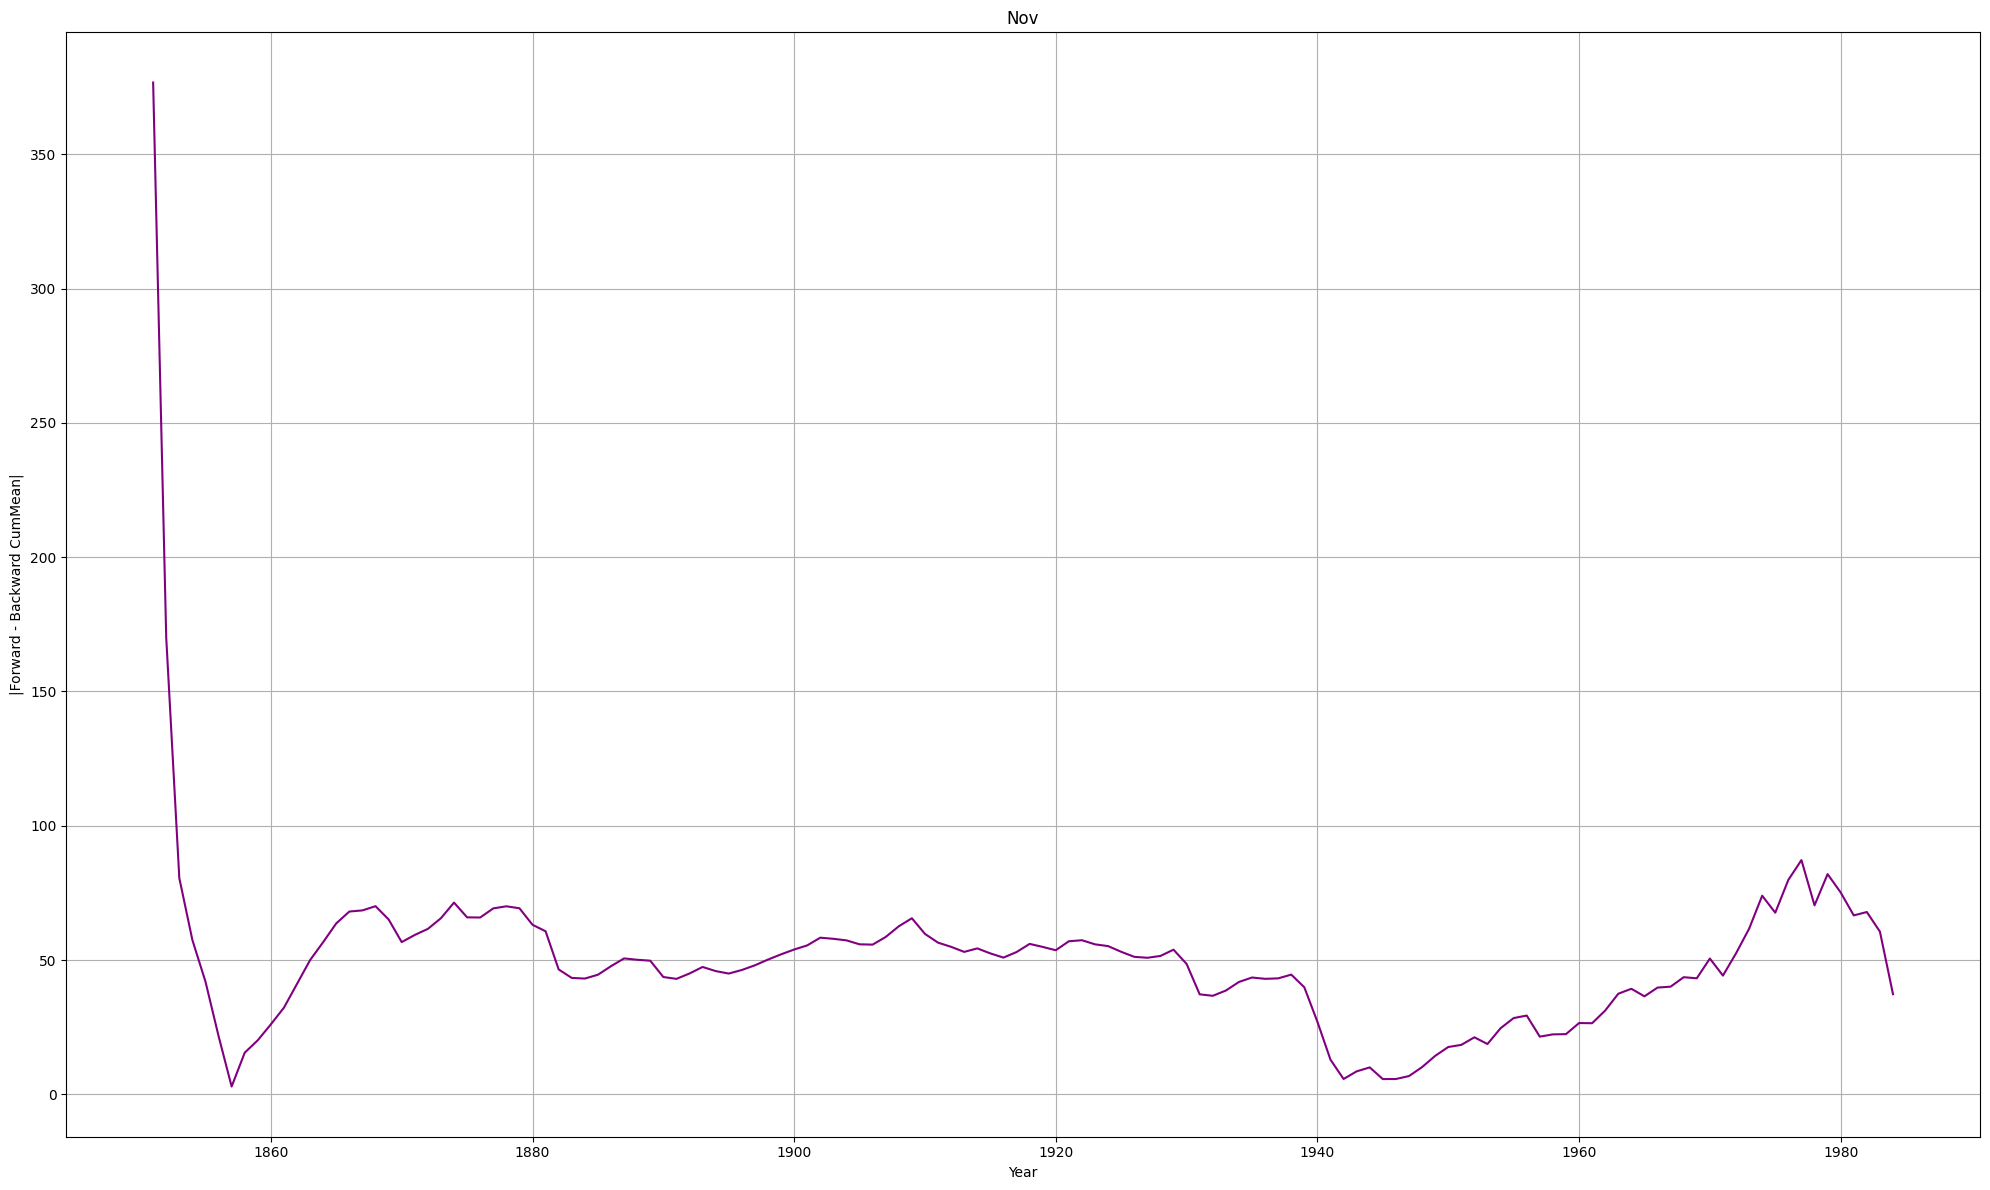

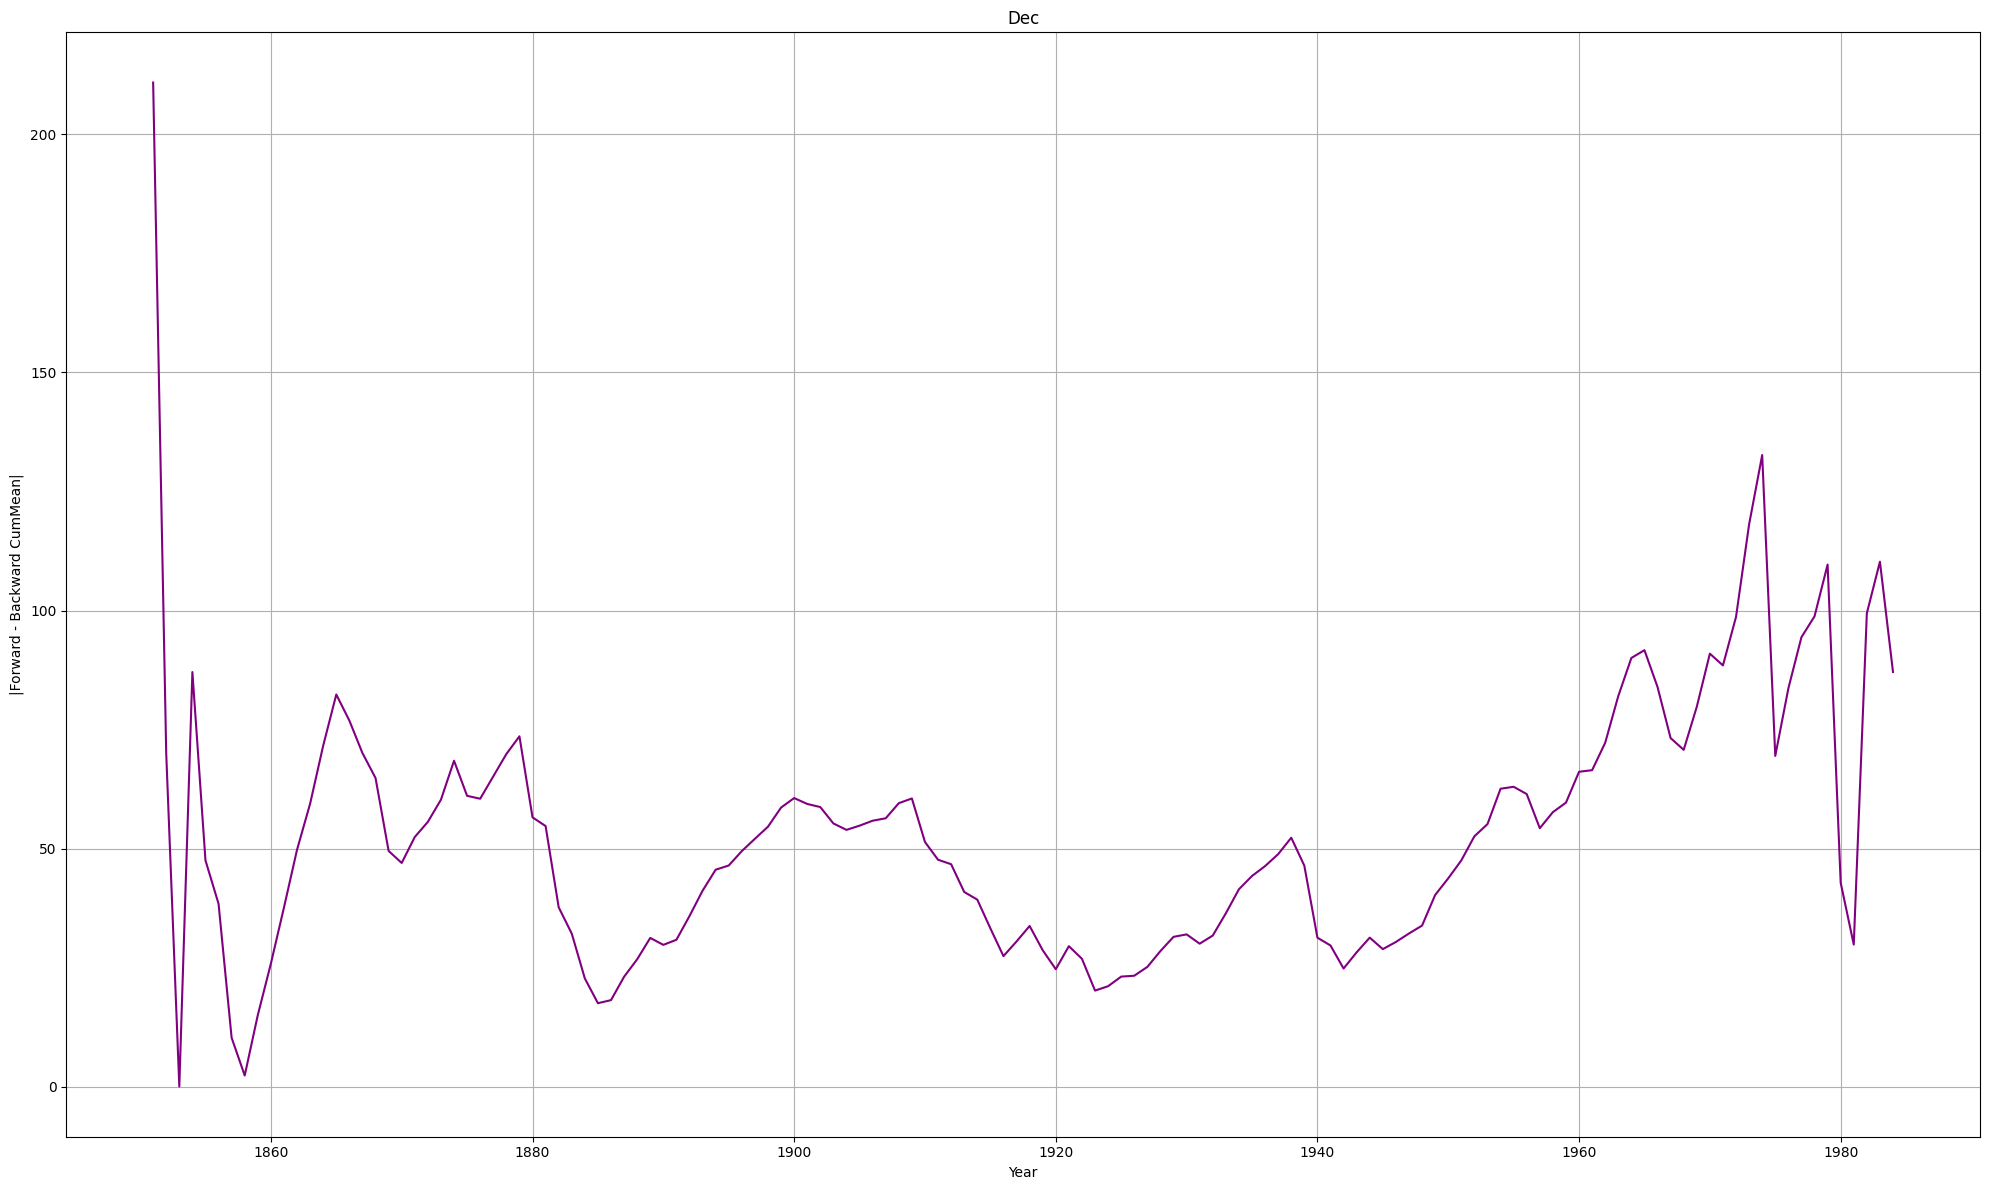

In [7]:
for month in months:
    data = df[month]

    # Forward cumulative mean
    forward_cummean = data.expanding().mean()

    # Backward cumulative mean
    backward_cummean = data[::-1].expanding().mean()[::-1]

    # Absolute difference
    abs_diff = (forward_cummean - backward_cummean).abs()

    # Make individual plots
    plt.figure(figsize=(20, 12))
    plt.plot(df["Year"], abs_diff, color='purple')
    plt.title(month)
    plt.xlabel("Year")
    plt.ylabel("|Forward - Backward CumMean|")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

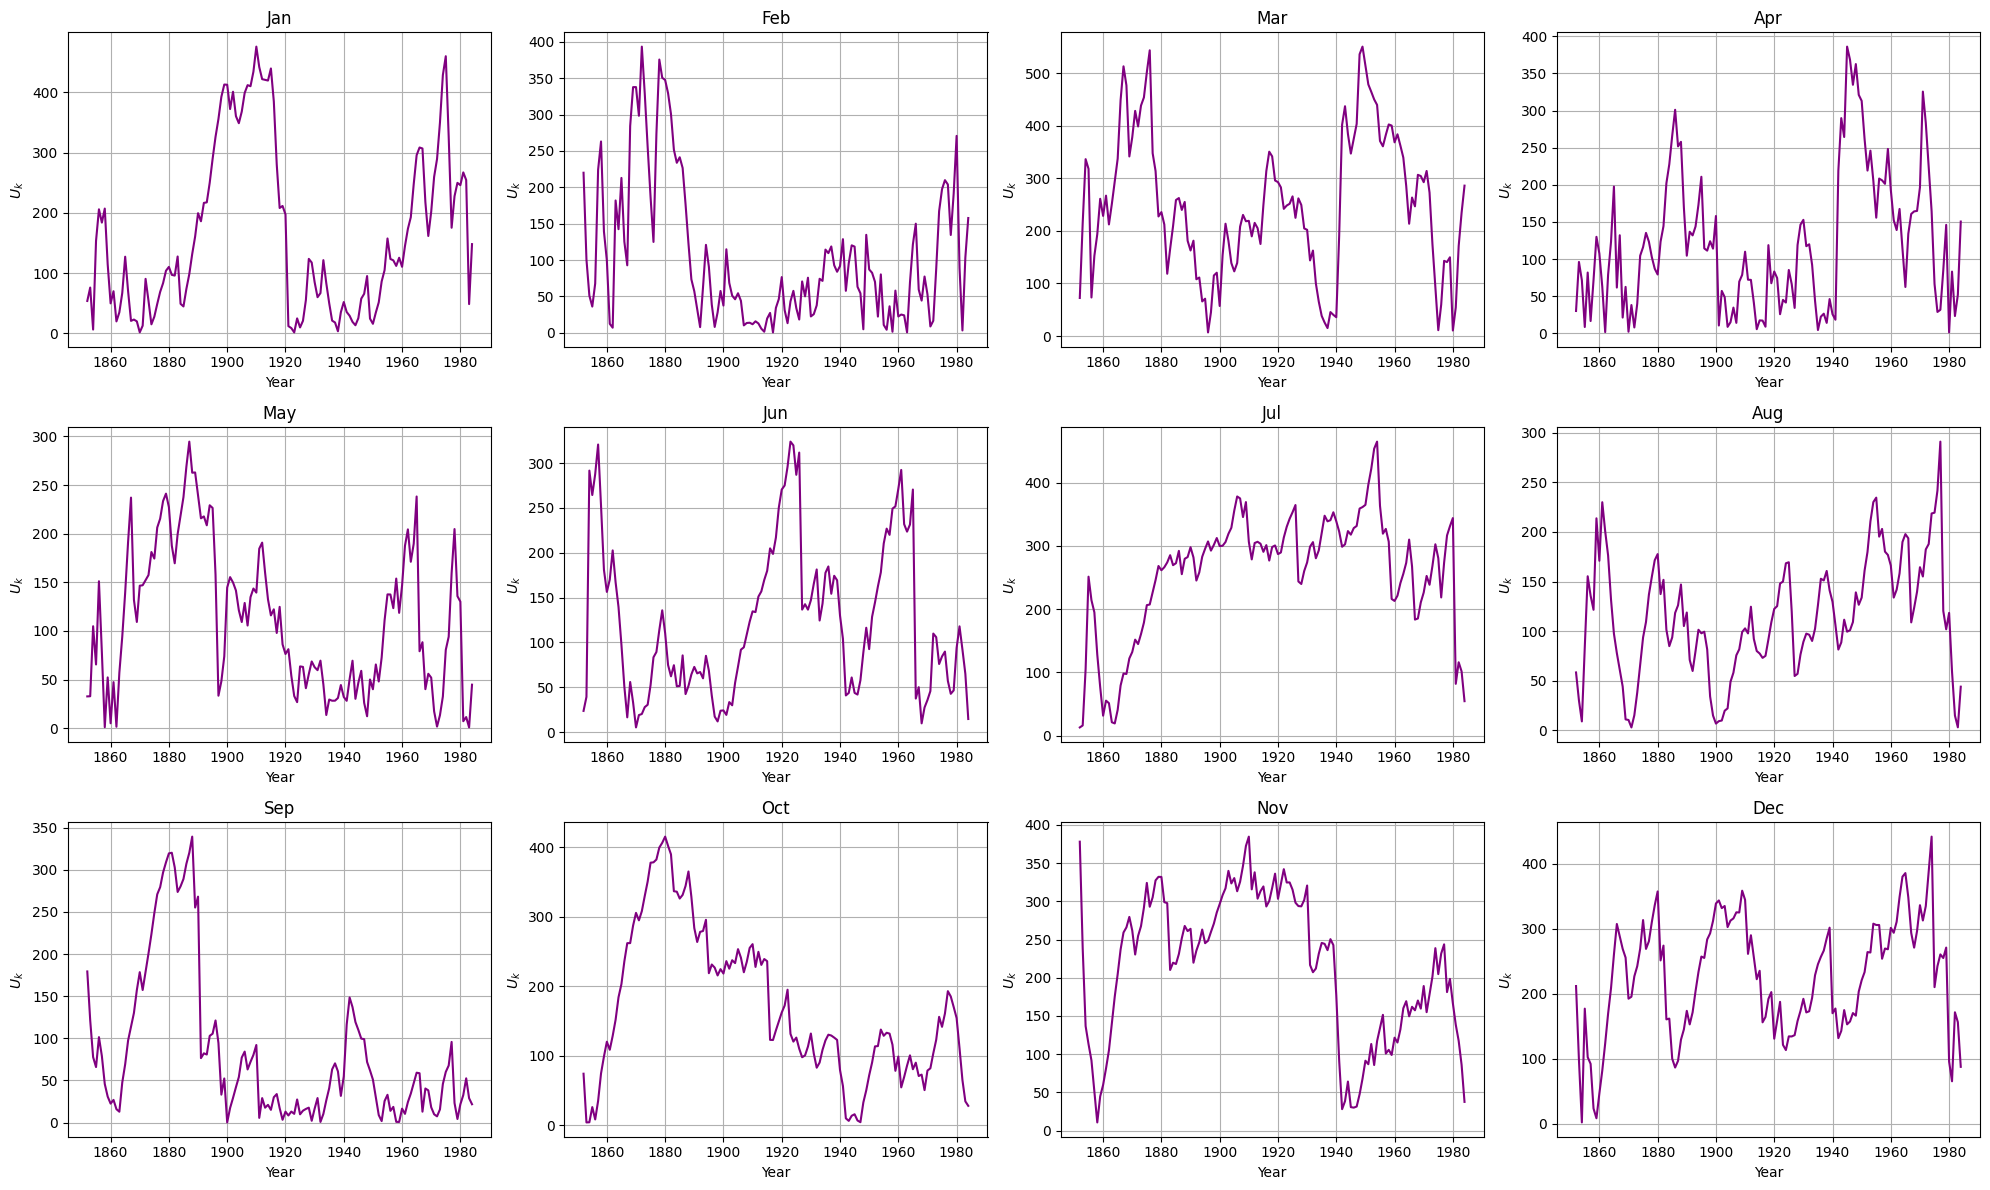

In [40]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values

    U_k = []
    for k in range(1, N):  # from year 1 to N-1
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Simplified standardized statistic
        Uk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean)
        U_k.append(Uk)

    # Plot Z_k vs Year
    axes[idx].plot(df["Year"][1:], U_k, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$U_k$")
    # axes[idx].axhline(y=1, color='red', linestyle='--', label='Threshold')
    axes[idx].grid(True)

plt.tight_layout()
# plt.suptitle("Forward and Backward Cumulative Mean Differences for Each Month (Elbe River, Decin)", fontsize=16, y=1.02)
plt.show()

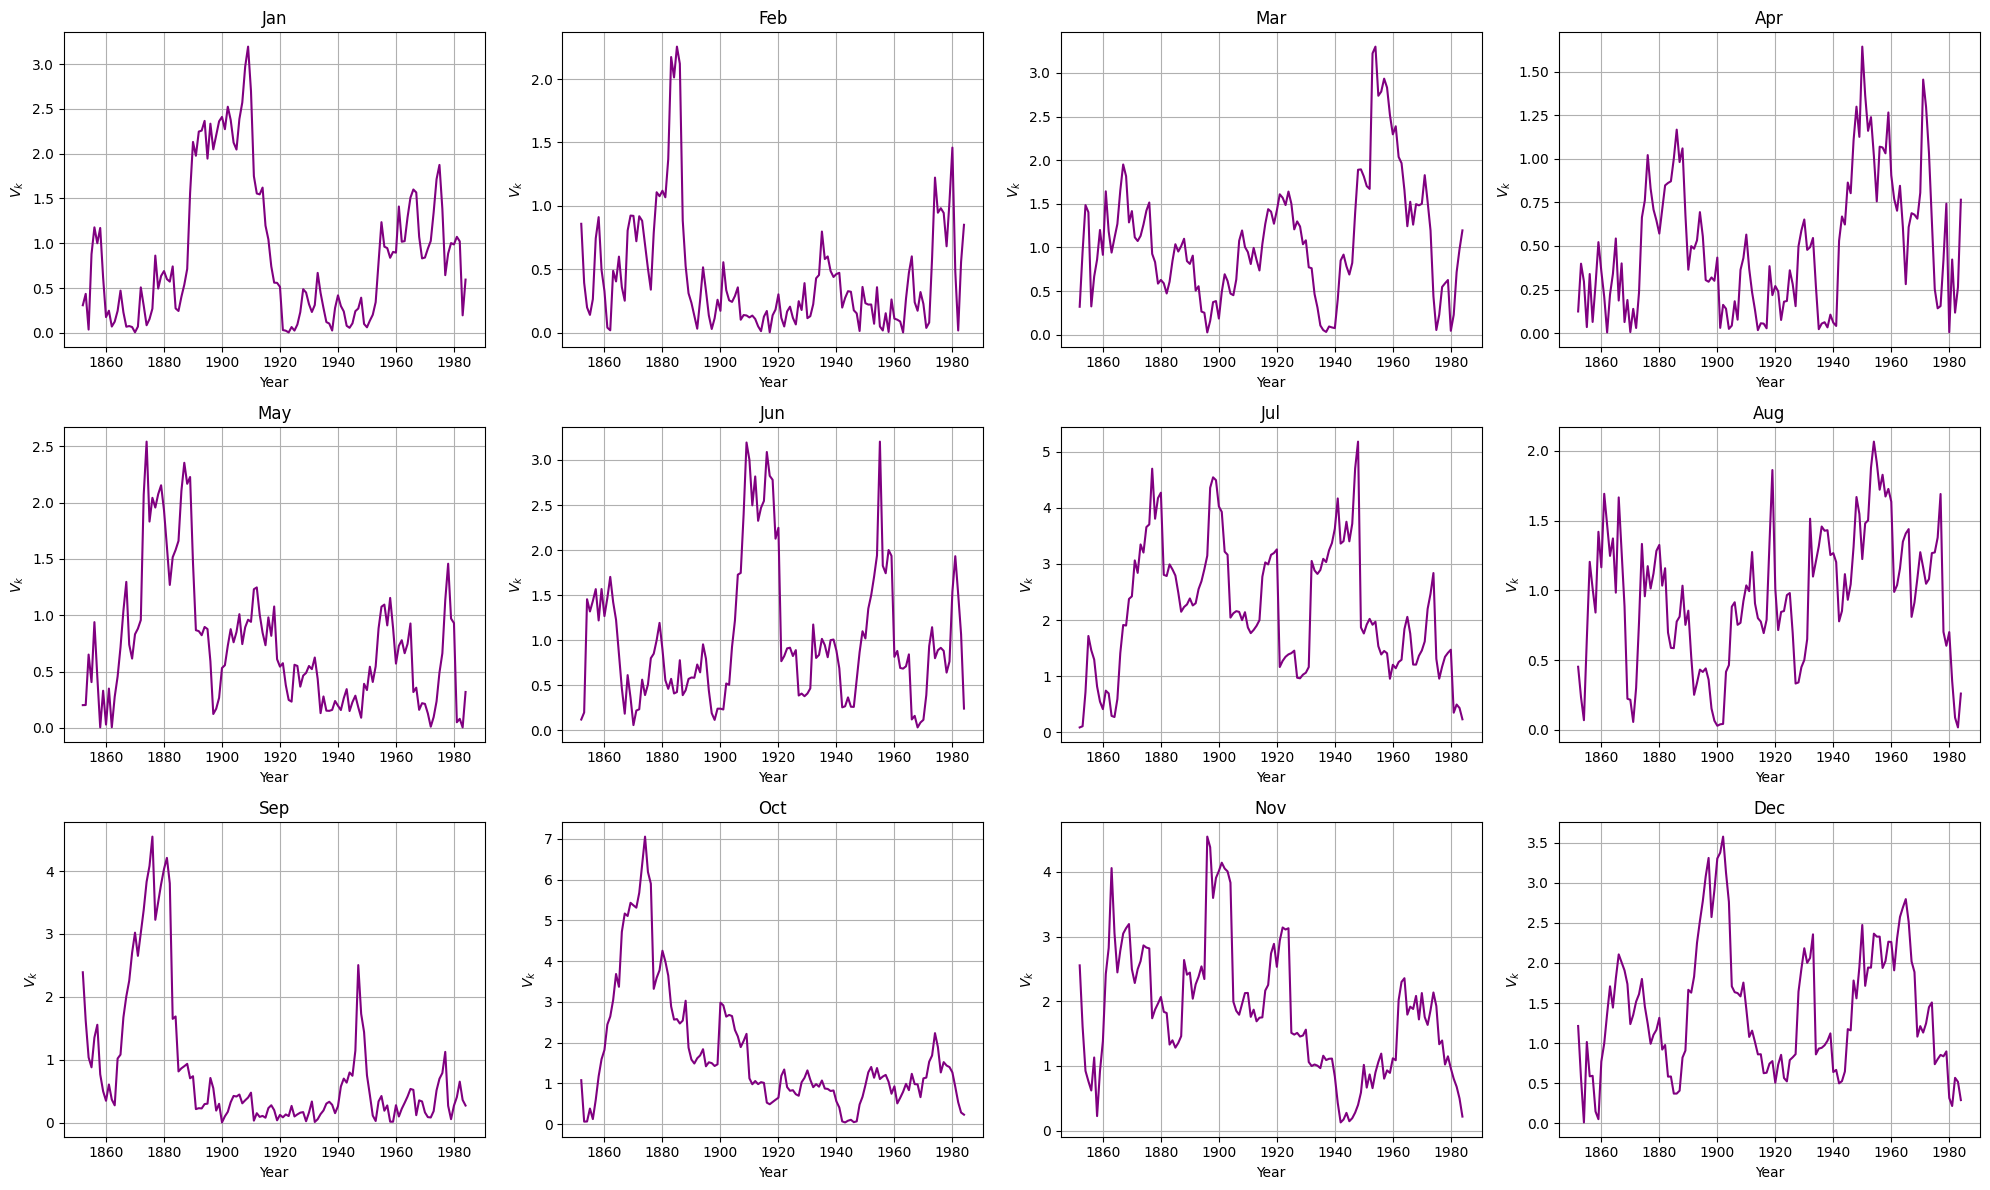

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Window size for local variance (adjust as needed)
d = 5  # d years before and after

# 3x4 plot for 12 months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values.astype(float)

    # Step 1: Compute U_k
    U_k = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        Uk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean)
        U_k.append(Uk)
    U_k = np.array(U_k)

    # Step 2: Compute local mean X_{k,d}* for middle points
    X_star = np.zeros(N)
    for k in range(d, N-d):
        X_star[k] = np.mean(data[k-d : k+d+1])

    # Step 3: Compute local variance sigma_k_hat for middle points
    sigma_hat = np.zeros(N)
    for k in range(d, N-d):
        sigma_hat[k] = np.sqrt((1/((2*d+1))) * np.sum((data[k-d : k+d+1] - X_star[k])**2))

    # Step 4: Handle edge cases
    # First d points
    sigma_hat[:d] = sigma_hat[d]
    # Last d points
    sigma_hat[N-d:] = sigma_hat[N-d-1]

    # Step 5: Standardized statistic V_k
    V_k = U_k / sigma_hat[1:]  # align lengths

    # Step 5: Plot
    axes[idx].plot(df["Year"][1:], V_k, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$V_k$")
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

In [47]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

# --- Pettitt Test Function (parameter-based interpretation) ---
def pettitt_test_param(x):
    """
    Perform Pettitt change-point test for a 1D array x.
    Returns:
        change_point: index of detected change point (0-based)
        K: test statistic
        p: approximate p-value
        mean_before: sample mean as estimate of E[X] before change
        mean_after: sample mean as estimate of E[X] after change
    """
    N = len(x)
    ranks = rankdata(x)  # rank the data

    # Compute U_t for t = 1 to N-1
    U = np.array([2*np.sum(ranks[:t]) - t*(N+1) for t in range(1, N)])
    K = np.max(np.abs(U))
    change_point = np.argmax(np.abs(U)) + 1  # +1 because t starts at 1

    # Approximate p-value
    p = 2 * np.exp(-6 * K**2 / (N**3 + N**2))

    # Sample means as estimates of population expectations
    mean_before = np.mean(x[:change_point])
    mean_after = np.mean(x[change_point:])

    return change_point, K, p, mean_before, mean_after

# --- Apply Pettitt Test Month by Month ---
months = df.columns[1:-1]  # assuming first column is 'Year' and last is 'Avg Annual'
results = []

for month in months:
    data = df[month].values
    cp, K, p, mean_before, mean_after = pettitt_test_param(data)
    results.append((month, cp, K, p, mean_before, mean_after))

# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results, columns=['Month', 'Change_Year_Index', 'K', 'p-value', 'E[X] Before', 'E[X] After'])

# Add the actual year corresponding to the change-point index
results_df['Change_Year'] = results_df['Change_Year_Index'].apply(lambda x: df['Year'].iloc[x])

# Keep only relevant columns
results_df = results_df[['Month', 'Change_Year', 'K', 'p-value', 'E[X] Before', 'E[X] After']]

print(results_df)

   Month  Change_Year       K   p-value  E[X] Before  E[X] After
0    Jan         1910  1016.0  0.155380   273.254237  356.101333
1    Feb         1872   376.0  1.409472   470.047619  376.572566
2    Mar         1876   788.0  0.430071   422.080000  542.688073
3    Apr         1886   481.0  1.128045   453.171429  512.373737
4    May         1887   767.0  0.466276   302.500000  359.938776
5    Jun         1961   691.0  0.613419   246.778182  312.625000
6    Jul         1936  1146.0  0.077494   199.388235  261.775510
7    Aug         1954   929.0  0.236209   187.954369  235.080645
8    Sep         1888   985.0  0.181166   143.837838  209.410309
9    Oct         1880  1456.0  0.010524   137.896552  224.978095
10   Nov         1922  1402.0  0.015420   194.478873  253.693651
11   Dec         1900  1179.0  0.064090   235.591837  296.330588


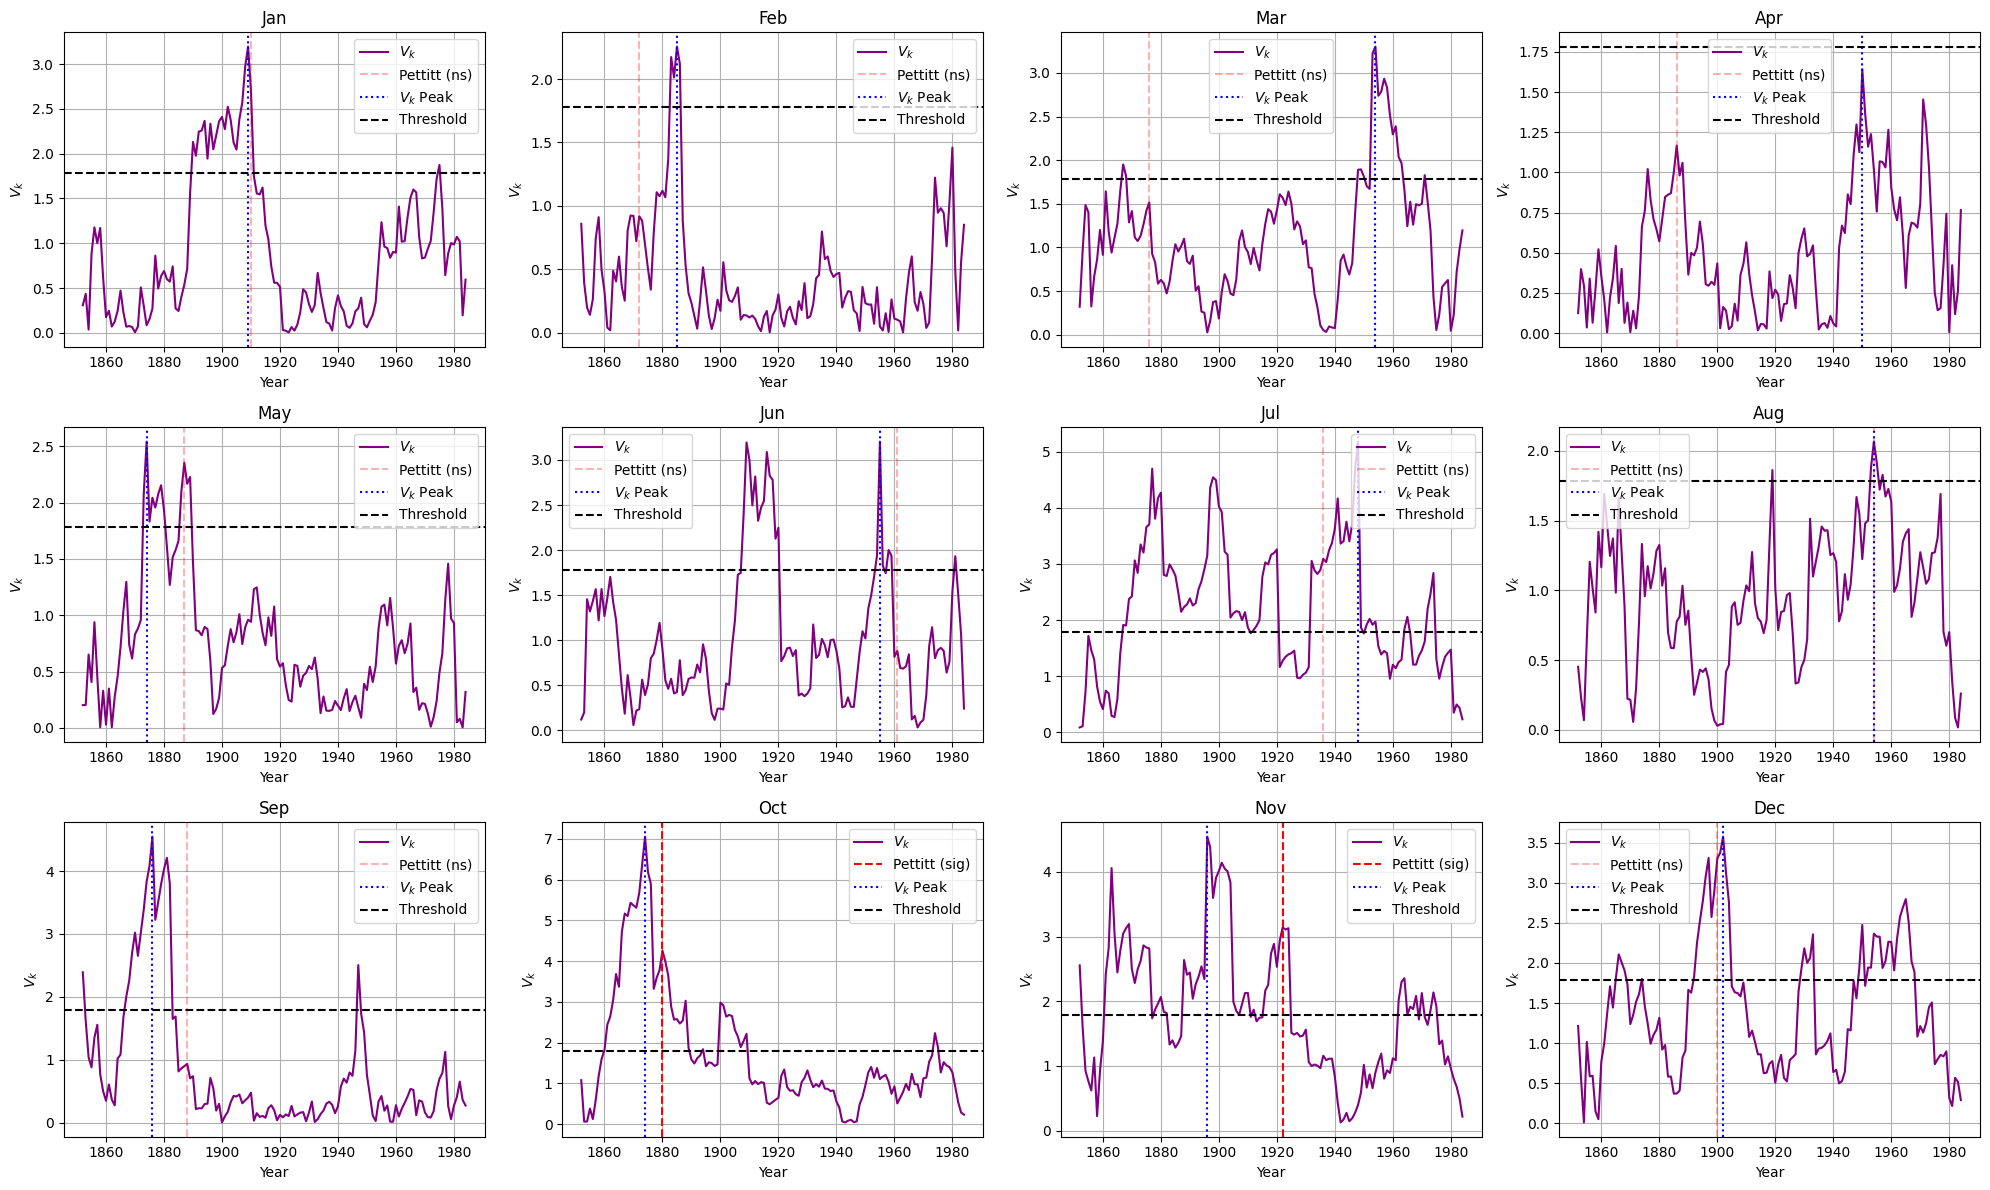

In [63]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values.astype(float)

    # Step 1: Compute U_k
    U_k = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        Uk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean)
        U_k.append(Uk)
    U_k = np.array(U_k)

    # Step 2: Compute X_{k,d}* and sigma_k_hat
    X_star = np.zeros(N)
    sigma_hat = np.zeros(N)
    for k in range(d, N-d):
        X_star[k] = np.mean(data[k-d : k+d+1])
        sigma_hat[k] = np.sqrt((1/((2*d+1))) * np.sum((data[k-d : k+d+1] - X_star[k])**2))
    sigma_hat[:d] = sigma_hat[d]
    sigma_hat[N-d:] = sigma_hat[N-d-1]

    # Step 3: Standardized V_k
    V_k = U_k / sigma_hat[1:N]

    # Step 4: Plot V_k
    axes[idx].plot(df["Year"][1:], V_k, color='purple', label=r'$V_k$')

    # Step 5: Overlay Pettitt change point
    cp_year = results_df.loc[results_df['Month'] == month, 'Change_Year'].values[0]
    p_val = results_df.loc[results_df['Month'] == month, 'p-value'].values[0]

    if p_val <= 0.05:
        axes[idx].axvline(x=cp_year, color='red', linestyle='--', label='Pettitt (sig)')
    else:
        axes[idx].axvline(x=cp_year, color='red', linestyle='--', alpha=0.3, label='Pettitt (ns)')

    # Step 6: Overlay the peak
    vk_cp_index = np.argmax(V_k) + 1
    vk_cp_year = df["Year"].iloc[vk_cp_index]
    axes[idx].axvline(x=vk_cp_year, color='blue', linestyle=':', label='$V_k$ Peak')

    # Compute threshold Vostikova's Formula
    h_N = np.sqrt(2 * np.log(np.log(N)))
    axes[idx].axhline(y=h_N, color='black', linestyle='--', label='Threshold')

    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$V_k$")
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.show()